In [650]:
%matplotlib inline

import os

import pandas as pd

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=32"
os.environ["OMP_NUM_THREADS"] = "32"
os.environ["MKL_NUM_THREADS"] = "32"
os.environ["NUMEXPR_NUM_THREADS"] = "32"
os.environ["OPENBLAS_NUM_THREADS"] = "32"
os.environ["VECLIB_MAXIMUM_THREADS"] = "32"
os.environ["NUMBA_NUM_THREADS"] = "32"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"


import numpyro

numpyro.set_host_device_count(30)
import jax 
jax.config.update("jax_enable_x64", True)

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value

import scipy.stats as st
from scipy.optimize import minimize

from scipy.special import erf, gamma, gammainc
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid, cumulative_trapezoid

#import emcee
#import corner

In [797]:
import h5py
def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
    d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
    d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    return d

def calc_lam_RF(d):
    lam_pivot = {
        'V': 5477,  # Johnson (no direct SDSS equivalent)
        'B': 4353,  # Johnson (no direct SDSS equivalent)
        'R': 6580,  # SDSS r-band
        'g': 4770,  # SDSS g-band
        'r': 6231,  # SDSS r-band
        'i': 7625,  # SDSS i-band
        'z': 9134,  # SDSS z-band
        'u': 3543,  # SDSS u-band
        'y': 9633,  # PS1 y-band
        'TESS': 7865,  # TESS broadband filter
        'kepler': 6420,  # Kepler broadband filter
        '5100 AA': 5100  # Reference wavelength
    }
    # Compute rest-frame wavelength
    lam_pivots = lam_pivot['i']
    lam_RF = lam_pivots / (1 + d['z'])
    d['log_lambda_RF'] = np.log10(lam_RF)
    return d

def split_field_by_band(q, keys):
    bands = q['filtered_bands']
    for key in keys:
        for i, b in enumerate(bands):
            q[f'{key}_{b}'] = q[key][i]

quasar_list = read_quasars_from_hdf5("data/s82_objects_ids_test_fitted.h5")
print("Number of quasars loaded:", len(quasar_list))

for q in quasar_list:
    split_field_by_band(q, ['log_sigma_band', 'log_sigma_band_err', 'log_jitter', 'magerrs_mean'])
    populate_sdss_fields(q)
    calc_lam_RF(q)
    q['delta_time'] = q['times']['r'].max() - q['times']['r'].min()

df = pd.DataFrame(quasar_list)
df = df.set_index('object_id')
df = df.drop(columns=['log_jitter', 'magerrs_mean', 'log_sigma_band', 'log_sigma_band_err'])

df_all = df.copy()

# Remove infinite values from numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

for i, band in enumerate(['g', 'r', 'i']):
    df = df[(10**df[f'log_sigma_band_{band}']) > 1.*np.sqrt(df[f'magerrs_mean_{band}']**2 + (10**df[f'log_jitter_{band}'])**2)]


# data cuts
df = df[df['log_sigma_RF'] < 0]
df = df[df['log_tau_RF'] > 1.5]
df = df[df['log_lbol'] > 44]
df = df[df['beta'] > -1]
df = df[df['beta'] < 0]
df = df[df['delta_time'] > 6000]

df = df[df['delta_time']/(1+df['z']) < 3200]


print("Number of quasars after cuts:", len(df))

df.head()

Number of quasars loaded: 545
Number of quasars after cuts: 249


,beta,beta_err,dec,filtered_bands,i,log_amp_delta,log_amp_delta_err,log_lbol,log_lbol_err,log_ledd_ratio,...,magerrs_mean_r,magerrs_mean_i,magerrs_mean_z,ebv,M_i,apparent_mag_i,apparent_mag_i_err,color,log_lambda_RF,delta_time
object_id,,,,,,,,,,,,,,,,,,,,,
1429843,-0.628522,0.070065,-0.010110,"[u, g, r, i, z]",37,"[-0.0, -0.18690504518787948, -0.35484008073120...","[0.0, 0.020835448160203857, 0.0395561933590709...",46.336920,0.002530,-0.800768,...,0.070161,0.051198,0.070617,0.019972,-26.045420,19.051138,0.024822,0.863050,3.476139,8045.892254
1429896,-0.400111,0.098249,0.332032,"[u, g, r, i, z]",34,"[-0.0, -0.11898185415837922, -0.22588759277561...","[0.0, 0.029216664586361366, 0.0554679709694290...",46.326601,0.003778,-0.681048,...,0.127264,0.091539,0.211717,0.017563,-25.552566,20.857696,0.048987,0.510091,3.340369,8041.951335
1429939,-0.582377,0.193526,-0.276605,"[u, g, r, i, z]",31,"[-0.0, -0.17318301485819318, -0.32878874356646...","[0.0, 0.05754922262568439, 0.10925746162704675...",45.862713,0.011396,-0.633073,...,0.181839,0.133151,0.303099,0.017141,-24.894809,21.621452,0.076503,1.633276,3.324091,7715.951324
1429952,-0.438862,0.119933,0.439034,"[u, g, r, i, z]",30,"[-0.0, -0.1305055187134655, -0.247765322490917...","[0.0, 0.03566479589442022, 0.06770977766660548...",45.474997,0.027928,-1.108192,...,0.153807,0.102300,0.157919,0.018526,-25.035559,20.823875,0.049391,1.871967,3.399777,7701.900772
1429967,-0.348487,0.066241,-0.952991,"[u, g, r, i, z]",28,"[-0.0, -0.10363053404895833, -0.19674304153313...","[0.0, 0.019698388892128237, 0.0373974811526961...",45.893064,0.007478,-1.356516,...,0.149493,0.101984,0.295698,0.020184,-25.054119,20.365195,0.033394,0.399618,3.443071,8039.972027


In [653]:
#df['object_id'].to_csv('data/object_ids_test.csv', index=False)

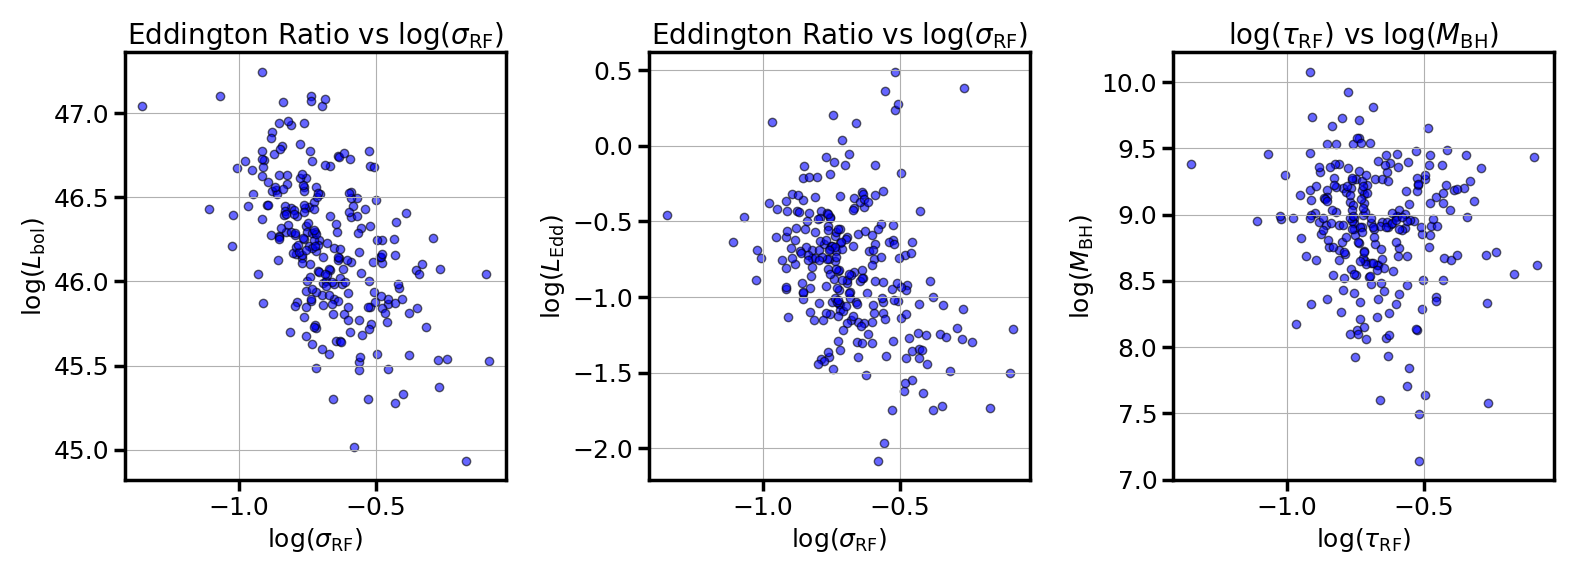

In [798]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

# Define the redshift range
redshift_min, redshift_max = 0.8, 1.5

# Apply the mask to filter the dataframe

# Plot Eddington ratio vs sigma
axs[0].scatter(df['log_sigma_RF'], df['log_lbol'], c='blue', alpha=0.6, edgecolor='black')
axs[0].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[0].set_ylabel(r"$\log(L_\mathrm{bol})$")
axs[0].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[0].grid(True)

# Plot Eddington ratio vs sigma
axs[1].scatter(df['log_sigma_RF'], df['log_ledd_ratio'], c='blue', alpha=0.6, edgecolor='black')
axs[1].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[1].set_ylabel(r"$\log(L_\mathrm{Edd})$")
axs[1].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[1].grid(True)

# Plot tau vs BH mass
axs[2].scatter(df['log_sigma_RF'], df['log_mbh'], c='blue', alpha=0.6, edgecolor='black')
axs[2].set_xlabel(r"$\log(\tau_\mathrm{RF})$")
axs[2].set_ylabel(r"$\log(M_\mathrm{BH})$")
axs[2].set_title(r"$\log(\tau_\mathrm{RF})$ vs $\log(M_\mathrm{BH})$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

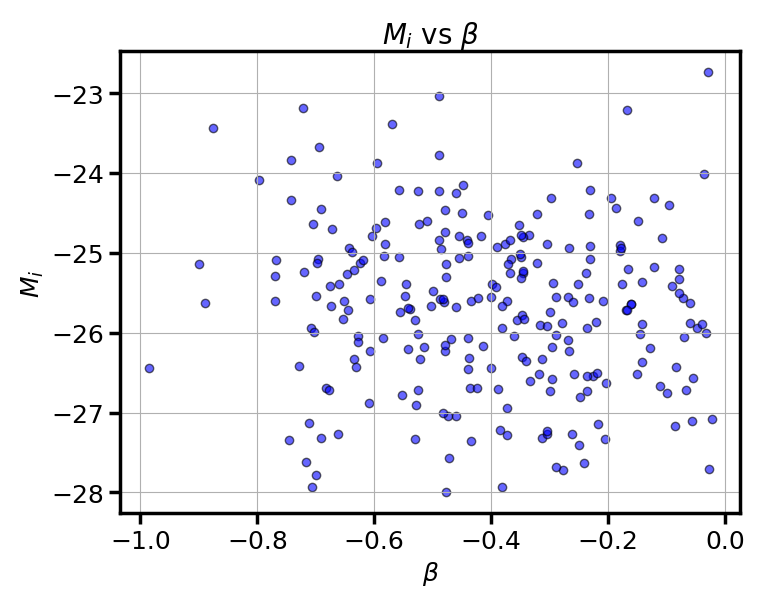

In [799]:
plt.figure(figsize=(8, 6))
plt.scatter(df['beta'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\beta$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\beta$")
plt.grid(True)
plt.show()

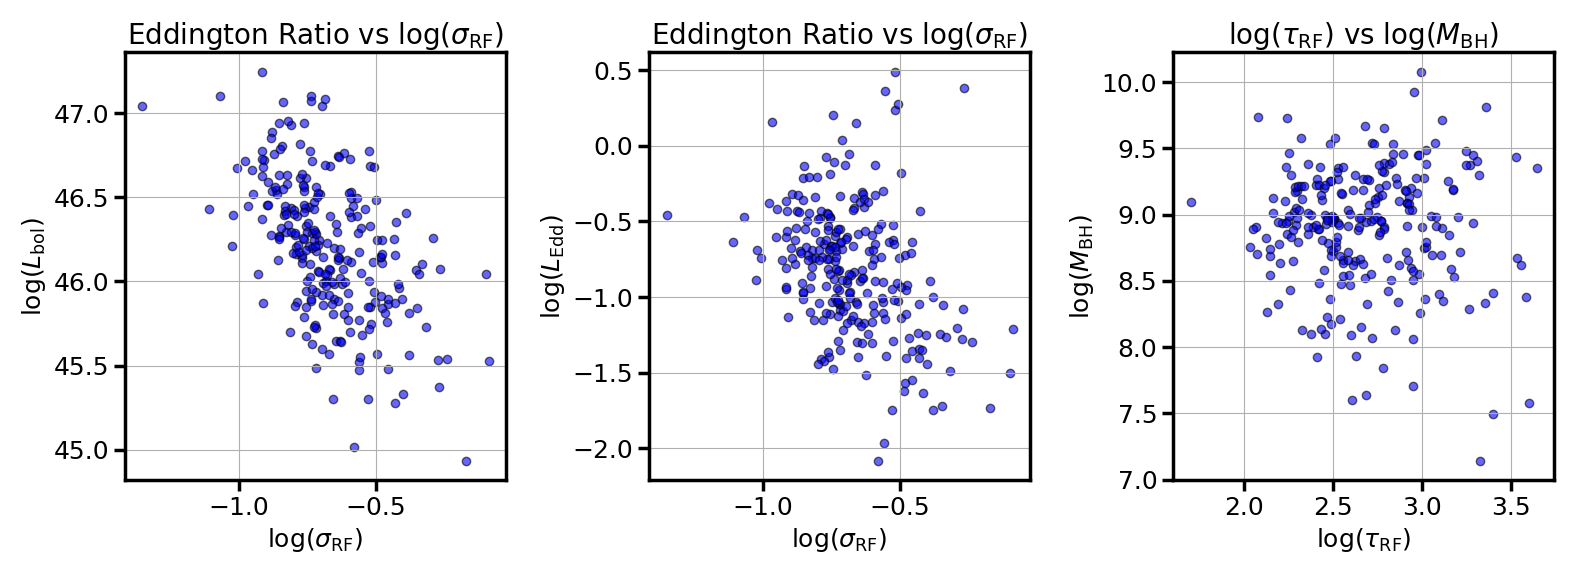

In [800]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

# Define the redshift range
redshift_min, redshift_max = 0.8, 1.5

# Apply the mask to filter the dataframe
#mask = (df['z'] >= redshift_min) & (df['z'] <= redshift_max)
filtered_df = df #[mask]


# Plot Eddington ratio vs sigma
axs[0].scatter(filtered_df['log_sigma_RF'], filtered_df['log_lbol'], c='blue', alpha=0.6, edgecolor='black')
axs[0].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[0].set_ylabel(r"$\log(L_\mathrm{bol})$")
axs[0].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[0].grid(True)

# Plot Eddington ratio vs sigma
axs[1].scatter(filtered_df['log_sigma_RF'], filtered_df['log_ledd_ratio'], c='blue', alpha=0.6, edgecolor='black')
axs[1].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[1].set_ylabel(r"$\log(L_\mathrm{Edd})$")
axs[1].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[1].grid(True)

# Plot tau vs BH mass
axs[2].scatter(filtered_df['log_tau_RF'], filtered_df['log_mbh'], c='blue', alpha=0.6, edgecolor='black')
axs[2].set_xlabel(r"$\log(\tau_\mathrm{RF})$")
axs[2].set_ylabel(r"$\log(M_\mathrm{BH})$")
axs[2].set_title(r"$\log(\tau_\mathrm{RF})$ vs $\log(M_\mathrm{BH})$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

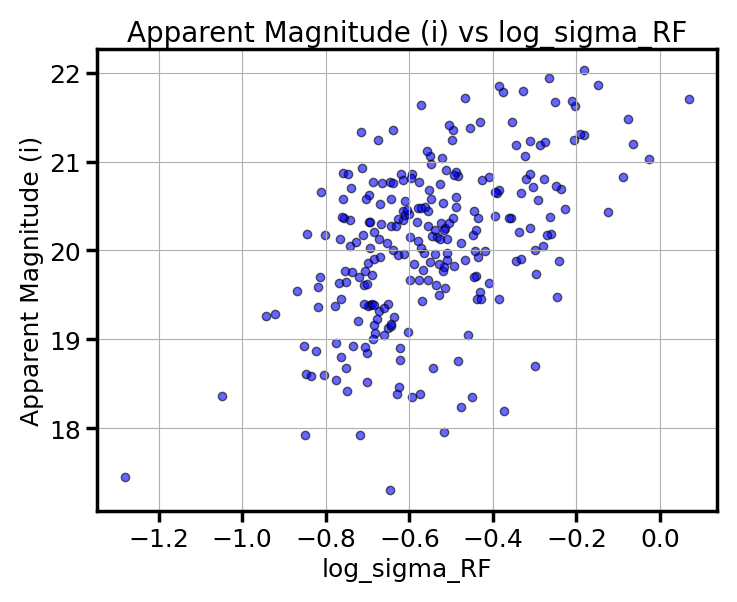

In [801]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('Apparent Magnitude (i)')
plt.title('Apparent Magnitude (i) vs log_sigma_RF')
plt.grid(True)
plt.show()

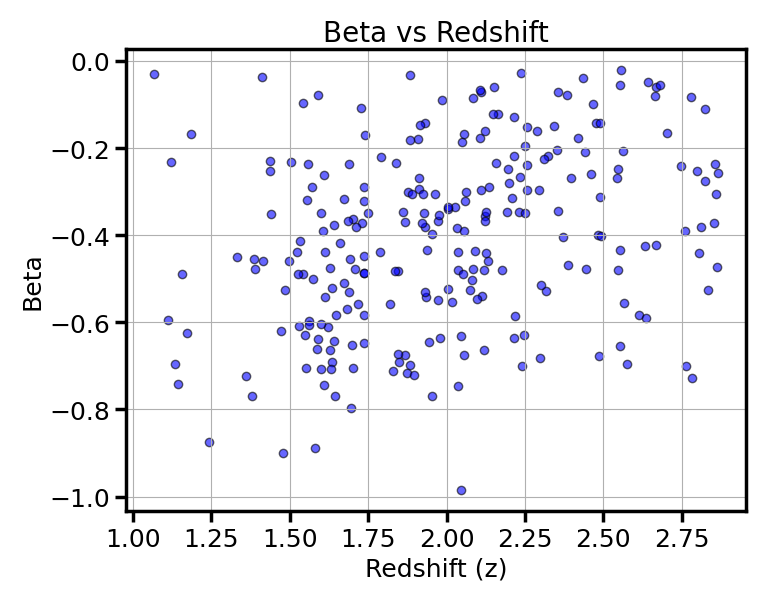

In [802]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['beta'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Beta')
plt.title('Beta vs Redshift')
plt.grid(True)
plt.show()

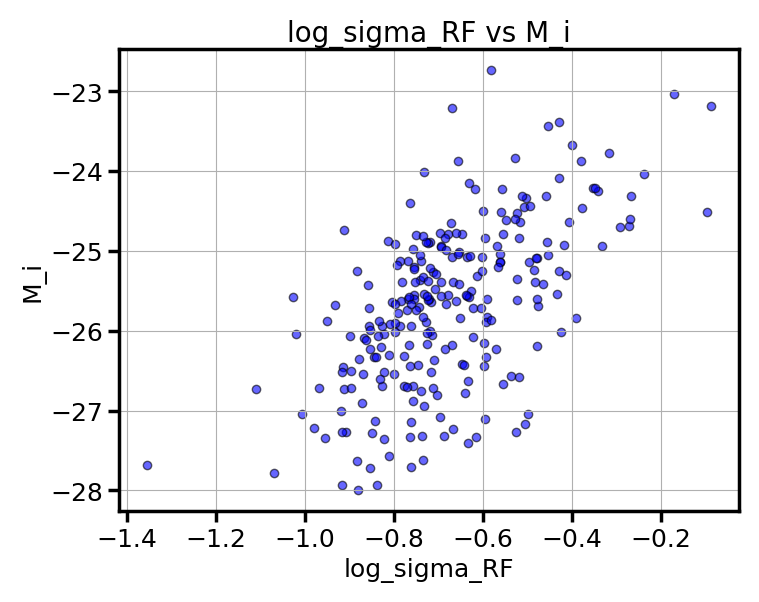

In [803]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
#plt.scatter(df['log_sigma_2000'][(df['M_i']<-15)], df['M_i'][(df['M_i']<-15)], c='k', alpha=0.6, edgecolor='k')

plt.xlabel('log_sigma_RF')
plt.ylabel('M_i')
plt.title('log_sigma_RF vs M_i')
plt.grid(True)
plt.show()

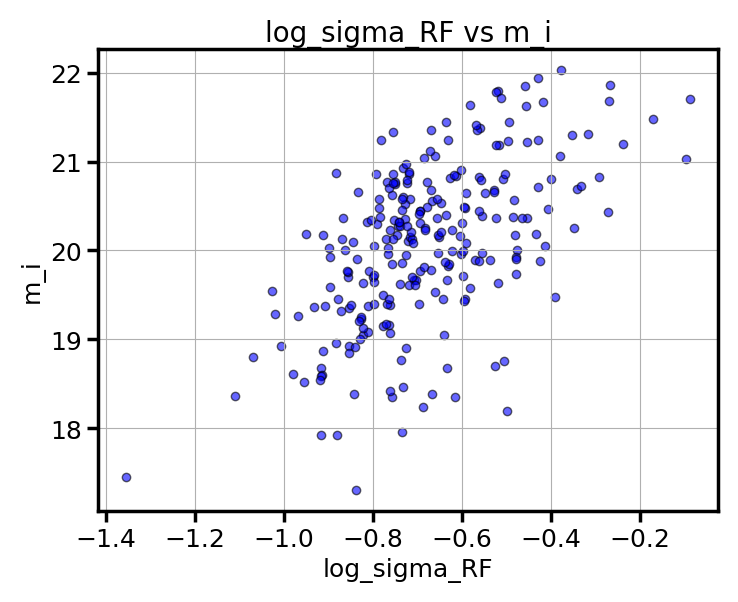

In [804]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
#plt.scatter(df['log_sigma_2000'][(df['M_i']<-15)], df['M_i'][(df['M_i']<-15)], c='k', alpha=0.6, edgecolor='k')

plt.xlabel('log_sigma_RF')
plt.ylabel('m_i')
plt.title('log_sigma_RF vs m_i')
plt.grid(True)
plt.show()

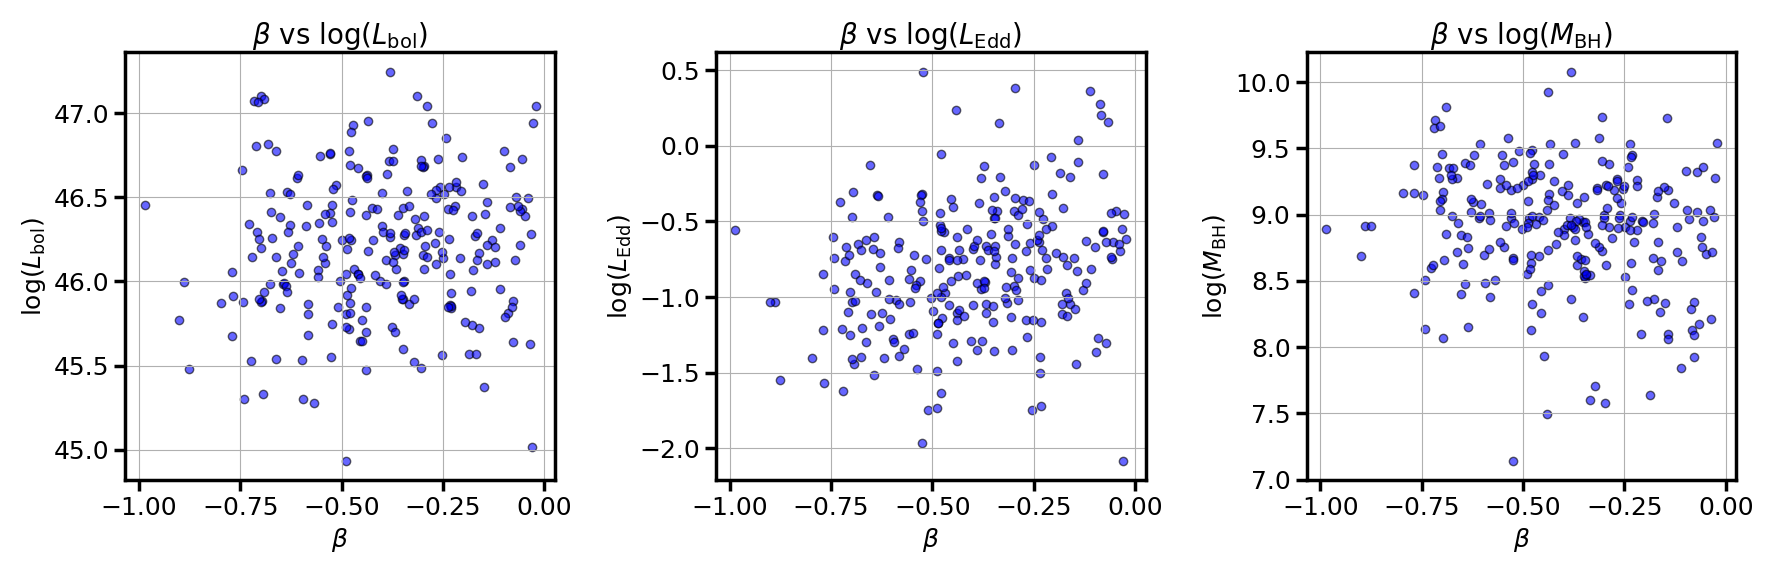

In [805]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot beta vs log_lbol
axs[0].scatter(df['beta'], df['log_lbol'], c='blue', alpha=0.6, edgecolor='black')
axs[0].set_xlabel(r"$\beta$")
axs[0].set_ylabel(r"$\log(L_\mathrm{bol})$")
axs[0].set_title(r"$\beta$ vs $\log(L_\mathrm{bol})$")
axs[0].grid(True)

# Plot beta vs log_ledd_ratio
axs[1].scatter(df['beta'], df['log_ledd_ratio'], c='blue', alpha=0.6, edgecolor='black')
axs[1].set_xlabel(r"$\beta$")
axs[1].set_ylabel(r"$\log(L_\mathrm{Edd})$")
axs[1].set_title(r"$\beta$ vs $\log(L_\mathrm{Edd})$")
axs[1].grid(True)

# Plot beta vs log_mbh
axs[2].scatter(df['beta'], df['log_mbh'], c='blue', alpha=0.6, edgecolor='black')
axs[2].set_xlabel(r"$\beta$")
axs[2].set_ylabel(r"$\log(M_\mathrm{BH})$")
axs[2].set_title(r"$\beta$ vs $\log(M_\mathrm{BH})$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

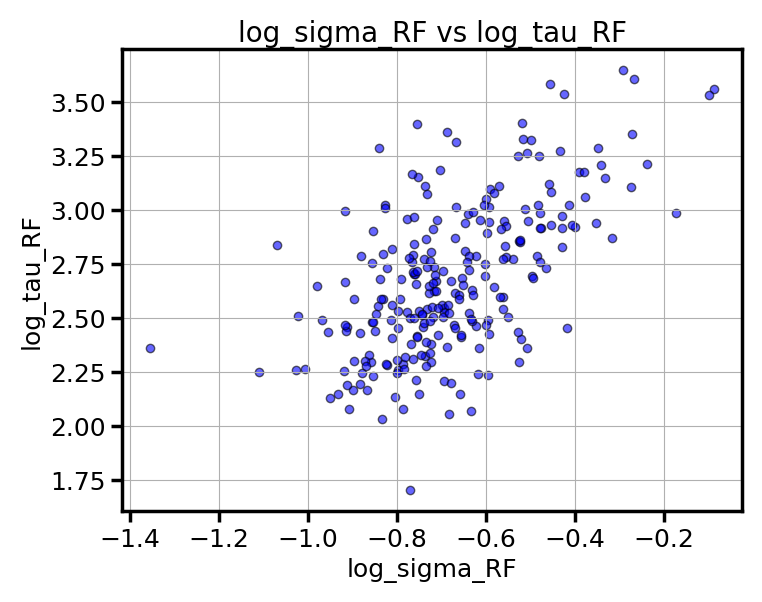

In [806]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['log_tau_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('log_tau_RF')
plt.title('log_sigma_RF vs log_tau_RF')
plt.grid(True)
plt.show()

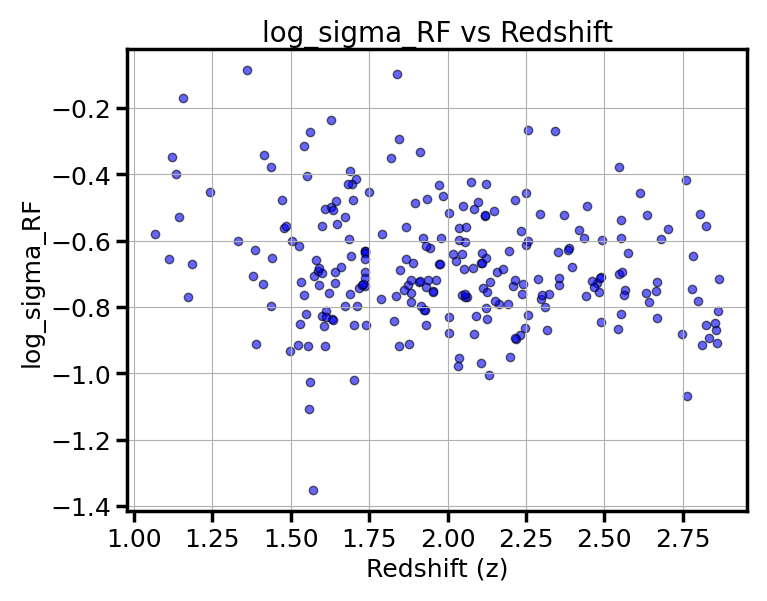

In [807]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['log_sigma_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('log_sigma_RF')
plt.title('log_sigma_RF vs Redshift')
plt.grid(True)
plt.show()

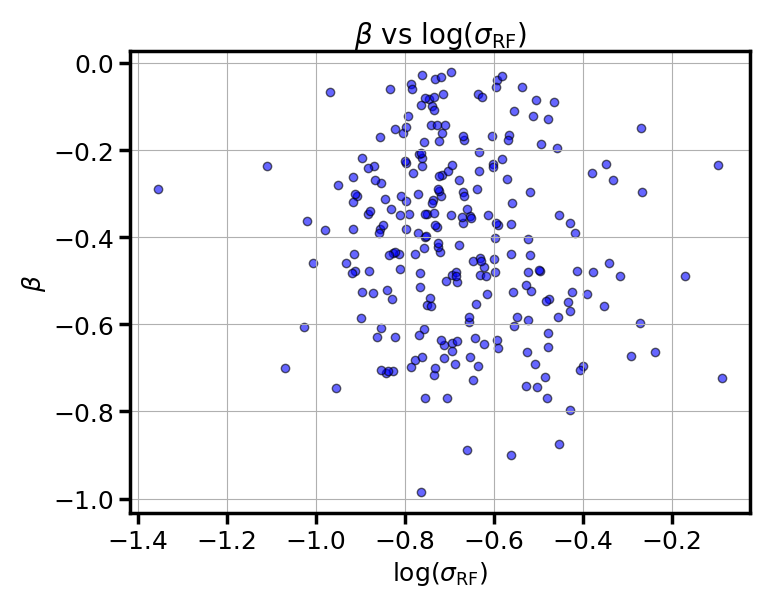

In [808]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['beta'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\log(\sigma_\mathrm{RF})$")
plt.ylabel(r"$\beta$")
plt.title(r"$\beta$ vs $\log(\sigma_\mathrm{RF})$")
plt.grid(True)
plt.show()

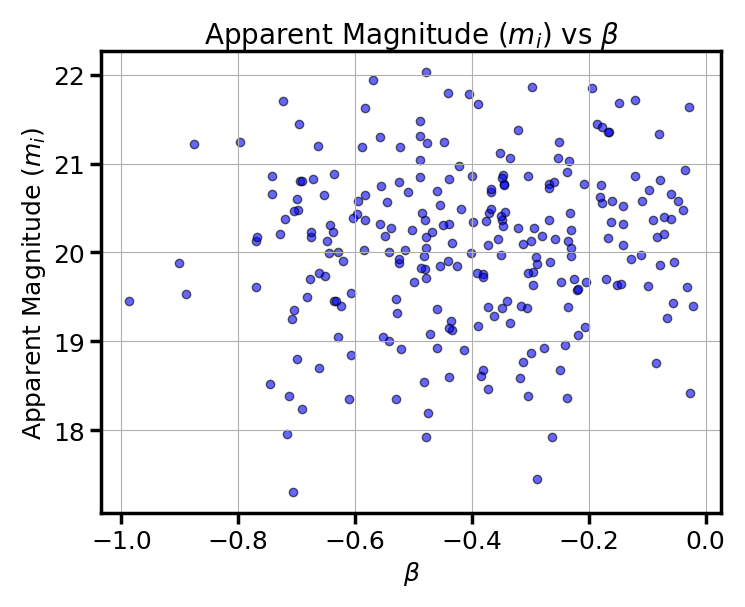

In [809]:
plt.figure(figsize=(8, 6))
plt.scatter(df['beta'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\beta$")
plt.ylabel(r"Apparent Magnitude ($m_i$)")
plt.title(r"Apparent Magnitude ($m_i$) vs $\beta$")
plt.grid(True)
plt.show()

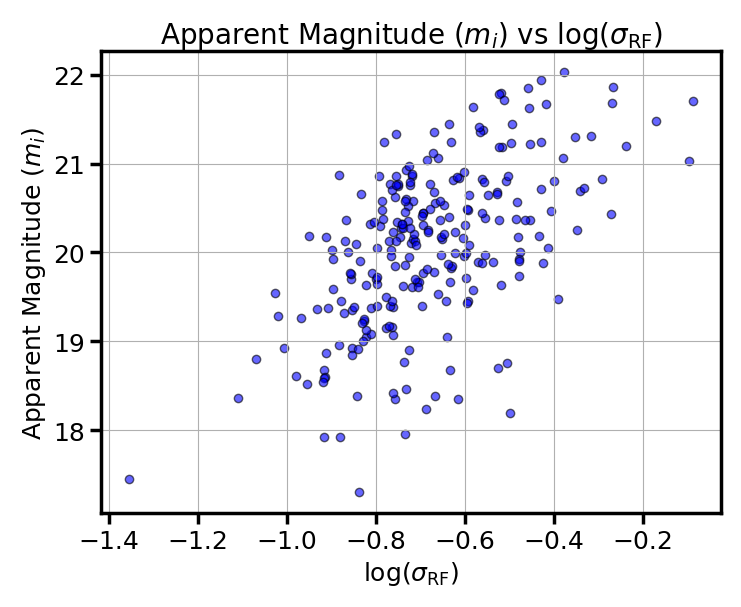

In [810]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\log(\sigma_\mathrm{RF})$")
plt.ylabel(r"Apparent Magnitude ($m_i$)")
plt.title(r"Apparent Magnitude ($m_i$) vs $\log(\sigma_\mathrm{RF})$")
plt.grid(True)
plt.show()

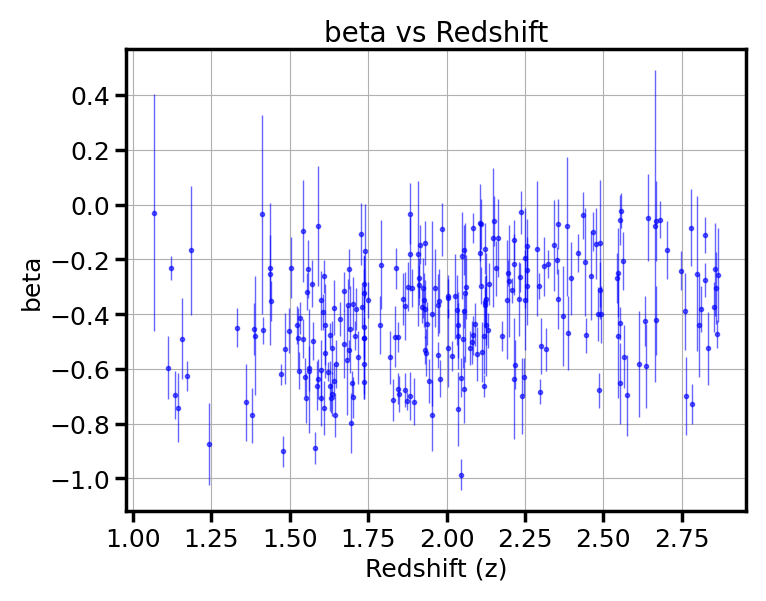

In [811]:
plt.figure(figsize=(8, 6))
plt.errorbar(df['z'], df['beta'], yerr=df['beta_err'], c='blue', alpha=0.6, lw=1, marker='.', linestyle='none')
plt.xlabel('Redshift (z)')
plt.ylabel('beta')
plt.title('beta vs Redshift')
plt.grid(True)
plt.show()

In [812]:
2500*(1+0.5)

3750.0

In [813]:
df[(df['beta']<-1) & (df['z'] > 1)]

,beta,beta_err,dec,filtered_bands,i,log_amp_delta,log_amp_delta_err,log_lbol,log_lbol_err,log_ledd_ratio,...,magerrs_mean_r,magerrs_mean_i,magerrs_mean_z,ebv,M_i,apparent_mag_i,apparent_mag_i_err,color,log_lambda_RF,delta_time
object_id,,,,,,,,,,,,,,,,,,,,,


In [814]:
df['z'][df['beta']>0.25]

Series([], Name: z, dtype: float64)

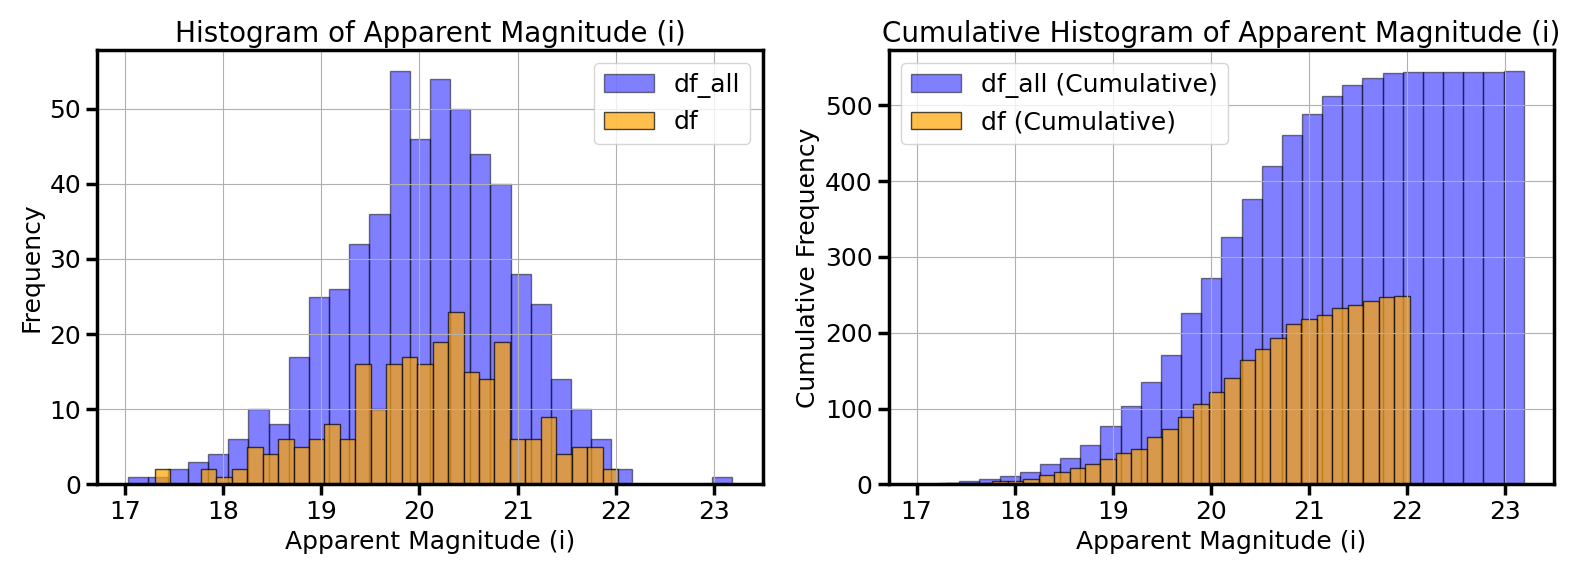

In [815]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot histogram for df_all
ax1.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all', edgecolor='black')
ax1.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df', edgecolor='black')
ax1.set_xlabel('Apparent Magnitude (i)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Apparent Magnitude (i)')
ax1.legend()
ax1.grid(True)

# Plot cumulative histograms
ax2.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.set_xlabel('Apparent Magnitude (i)')
ax2.set_ylabel('Cumulative Frequency')
ax2.set_title('Cumulative Histogram of Apparent Magnitude (i)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

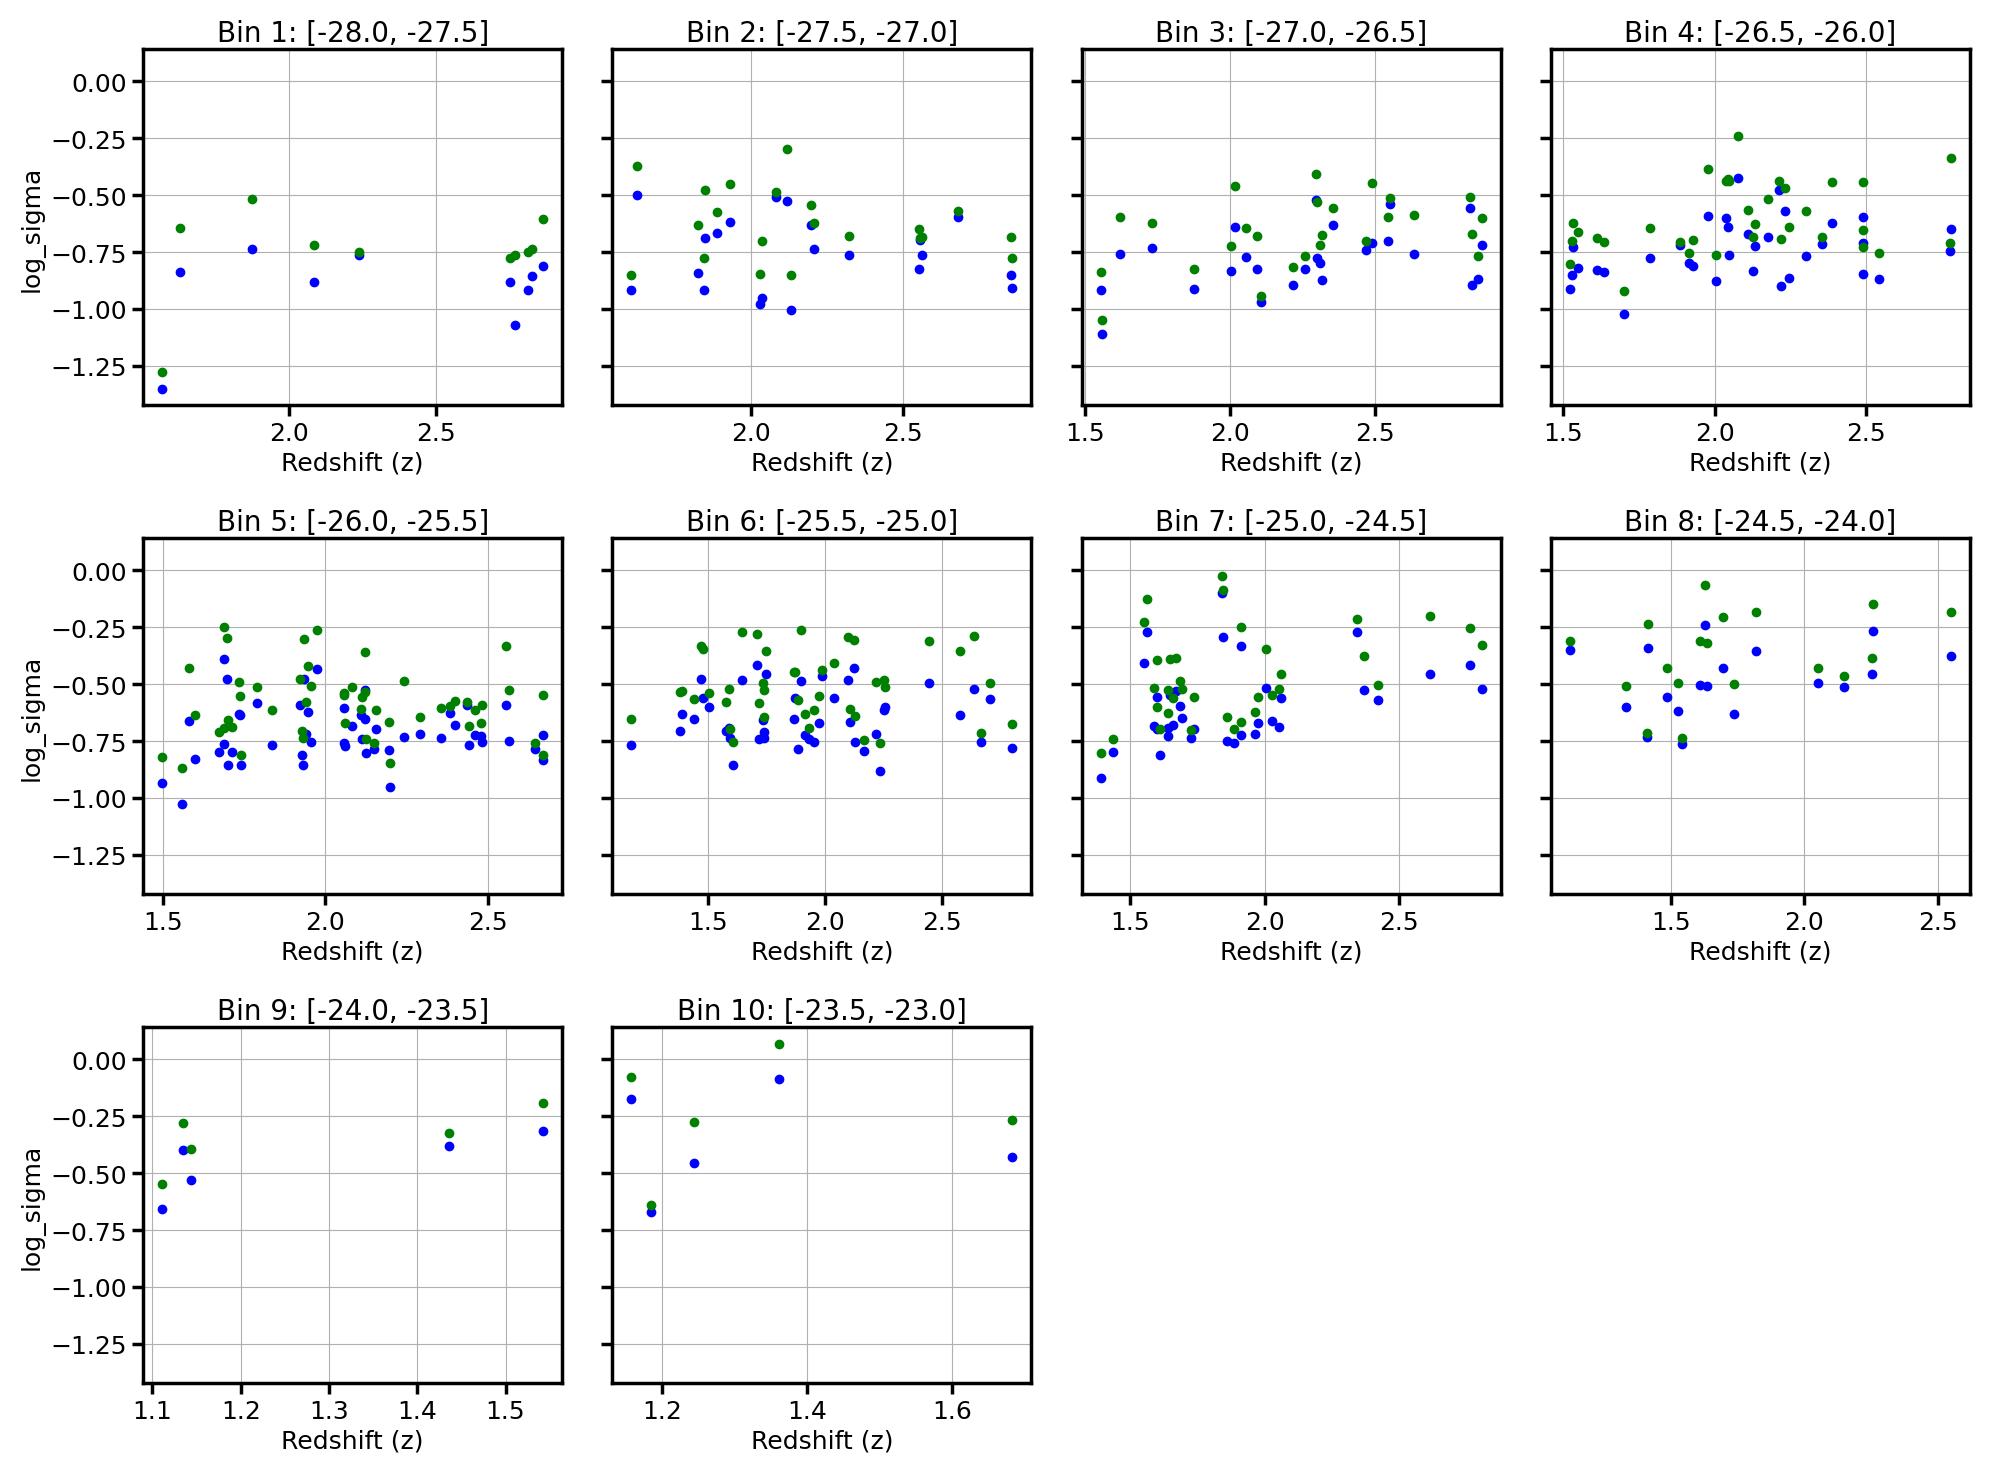

In [816]:
from scipy.stats import linregress

# Define the bins for M_i

M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_sigma_RF'])
        y_vals = slope * np.linspace(1, 2) + intercept
        #axes[i].plot(np.linspace(1, 2), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_sigma_RF'], 'bo', label='Data')
        axes[i].plot(bin_data['z'], bin_data['log_sigma'], 'go', label='Data')
        #axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_sigma')
    axes[i].grid(True)
    #axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

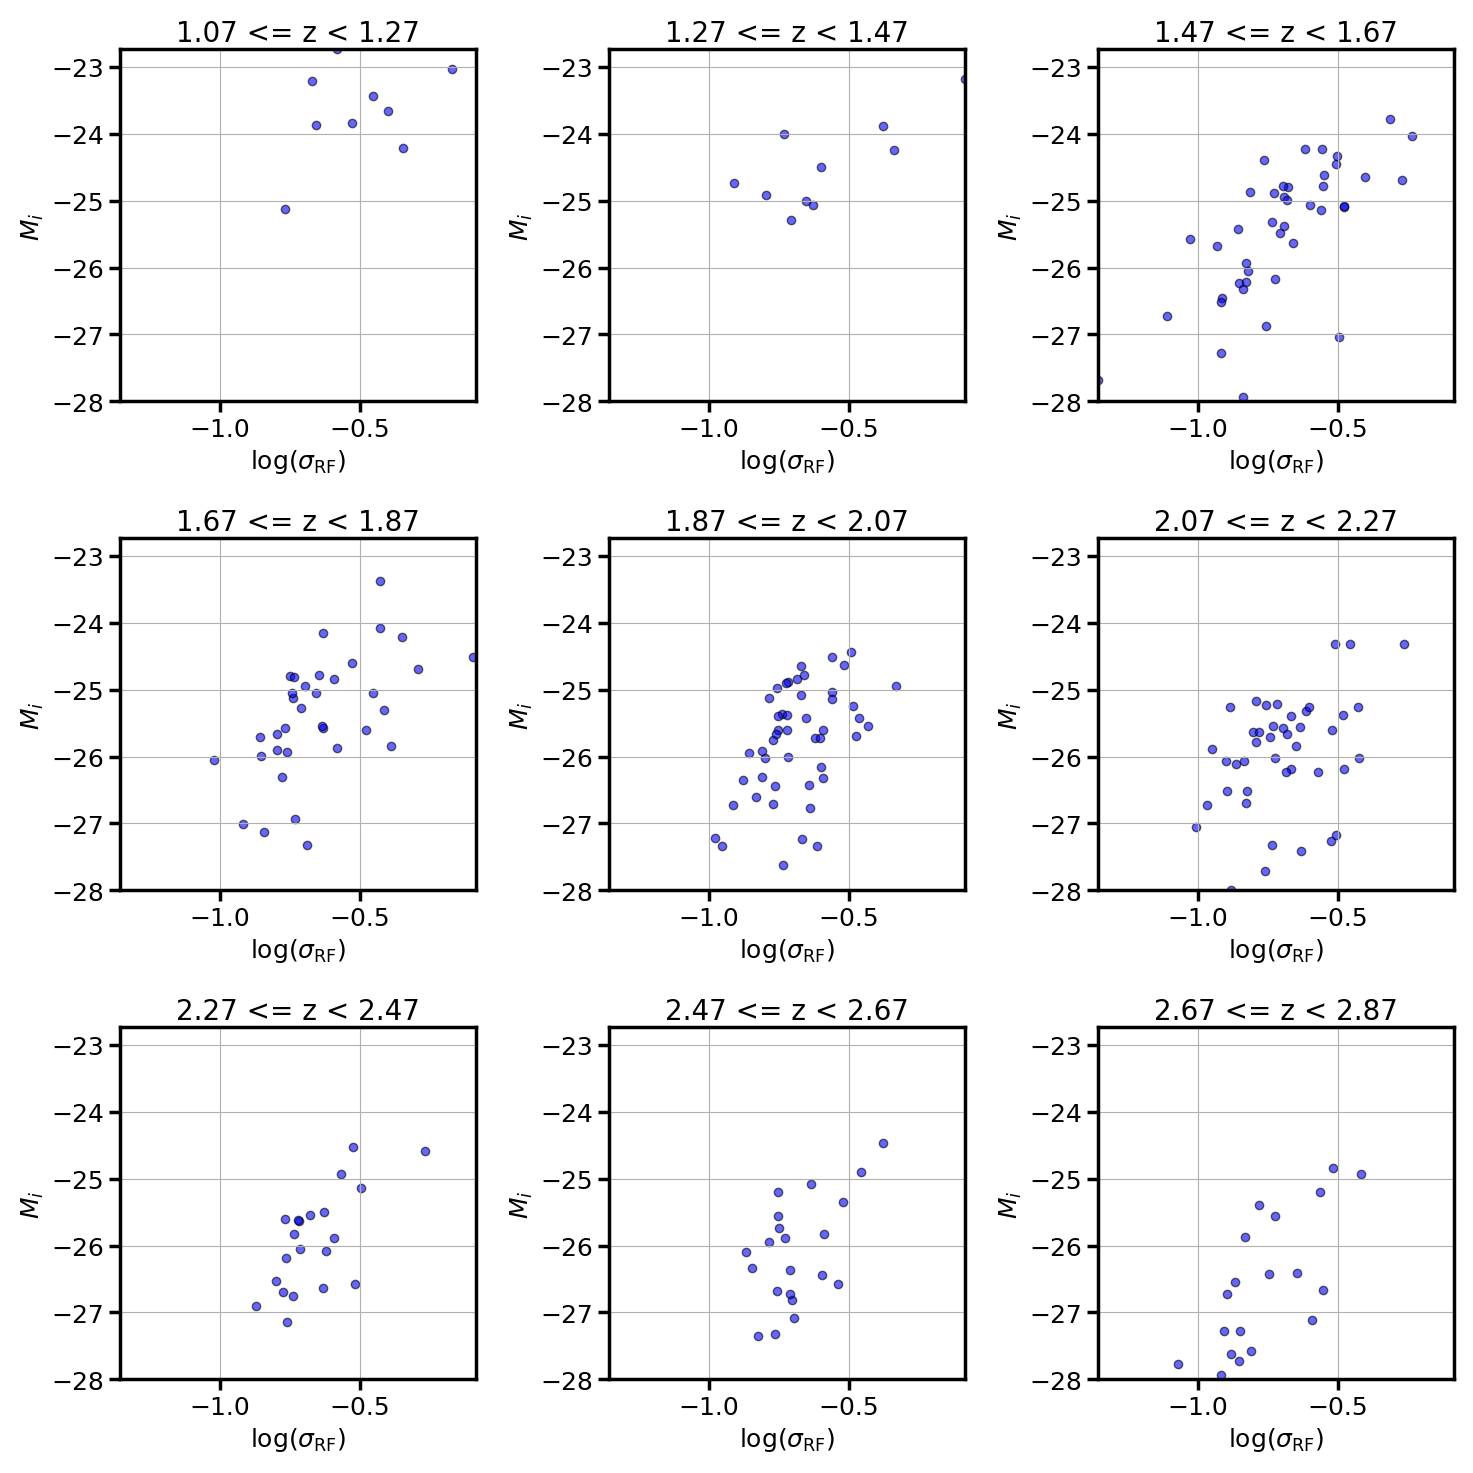

In [817]:
# Determine the axis limits for all panels
x_min, x_max = df['log_sigma_RF'].min(), df['log_sigma_RF'].max()
y_min, y_max = df['M_i'].min(), df['M_i'].max()

# Define the redshift bins
redshift_bins = np.linspace(df['z'].min(), df['z'].max(), 10)  # Adjust the number of bins as needed

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust grid size based on the number of bins
axes = axes.flatten()

# Iterate over each redshift bin
for i in range(len(redshift_bins) - 1):
    # Filter the data for the current redshift bin
    bin_mask = (df['z'] >= redshift_bins[i]) & (df['z'] < redshift_bins[i + 1])
    bin_data = df[bin_mask]
    
    # Plot the data
    axes[i].scatter(bin_data['log_sigma_RF'], bin_data['M_i'], c='blue', alpha=0.6, edgecolor='black')
    axes[i].set_title(f"{redshift_bins[i]:.2f} <= z < {redshift_bins[i + 1]:.2f}")
    axes[i].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
    axes[i].set_ylabel(r"$M_i$")
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    axes[i].grid(True)

# Hide unused subplots
for j in range(len(redshift_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

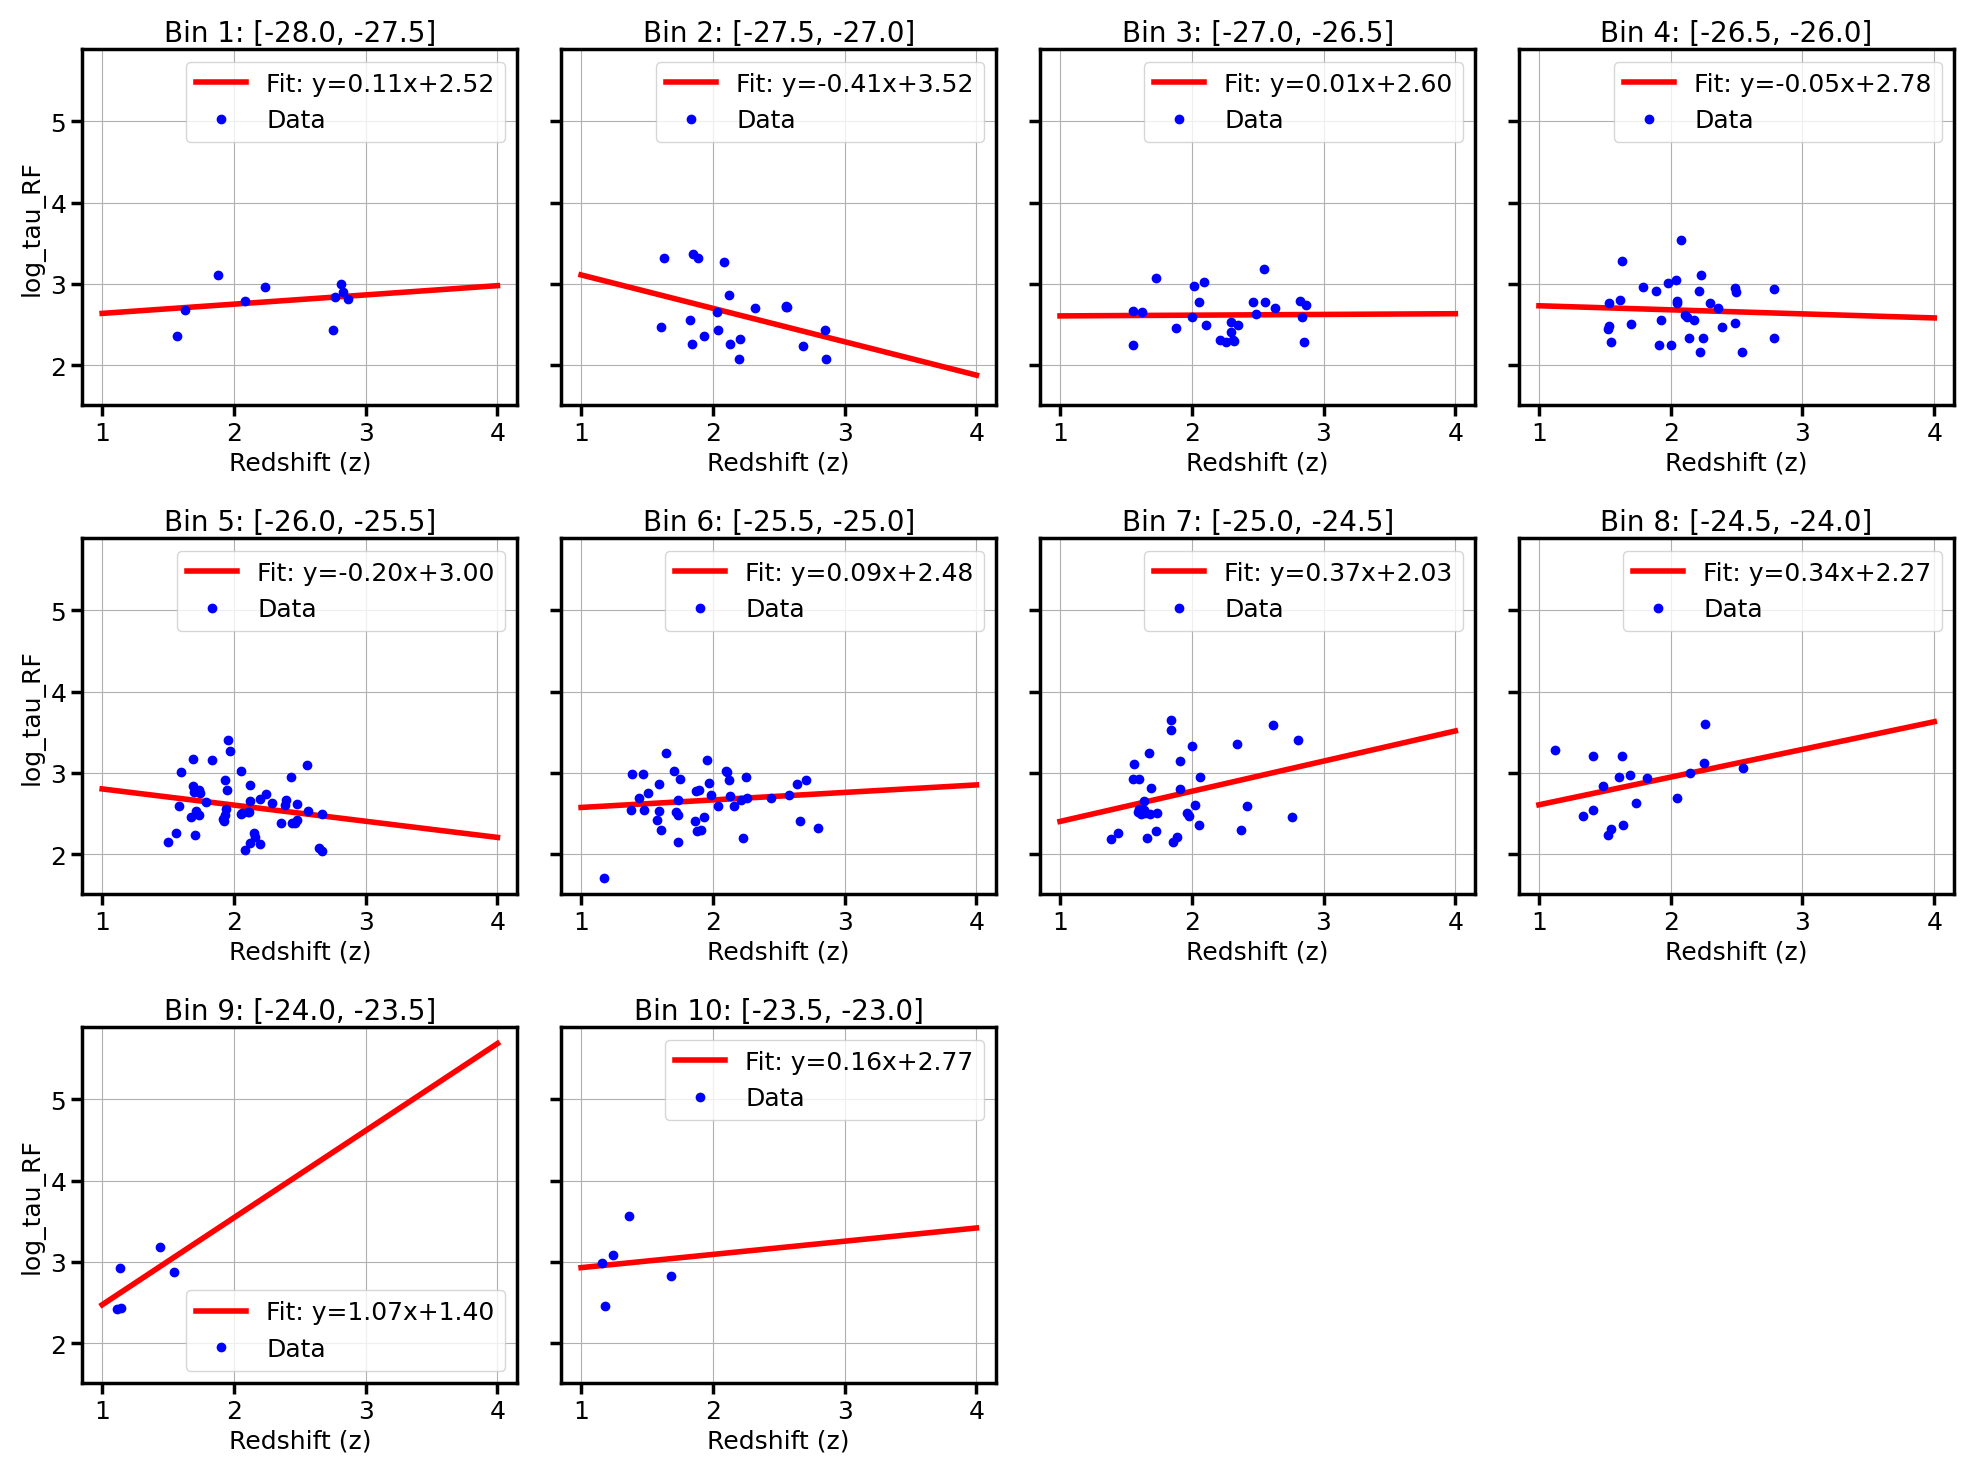

In [818]:
from scipy.stats import linregress

# Define the bins for M_i
M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_tau_RF'])
        y_vals = slope * np.linspace(1, 4) + intercept
        axes[i].plot(np.linspace(1, 4), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_tau_RF'], 'bo', label='Data')
        axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_tau_RF')
    axes[i].grid(True)
    axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

ValueError: x and y must be the same size

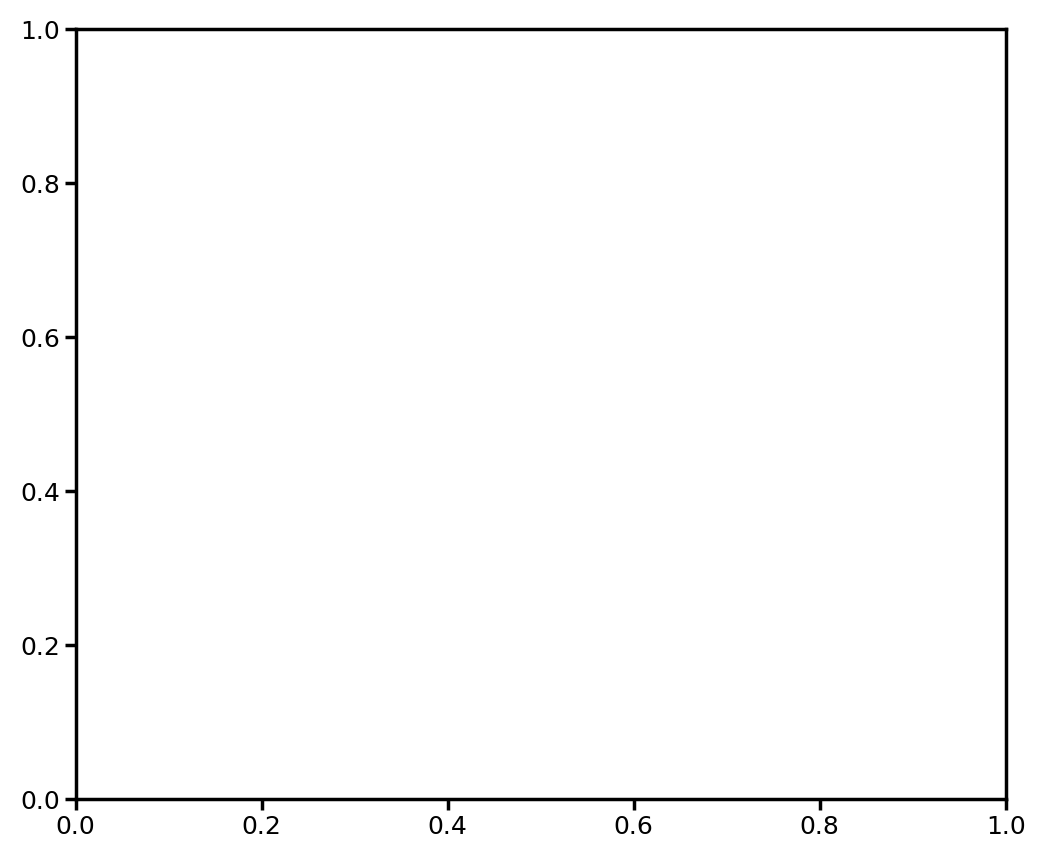

In [819]:
cosmo = w0waCDM(H0=70, Om0=0.3, Ode0=0.7, w0=-1, wa=0)
mu_model = cosmo.distmod(df['z']).value
plt.scatter(df['z'], 21.5 - M_i_pred - K_corr(df['z']))

100%|██████████| 1000/1000 [00:49<00:00, 20.03it/s]


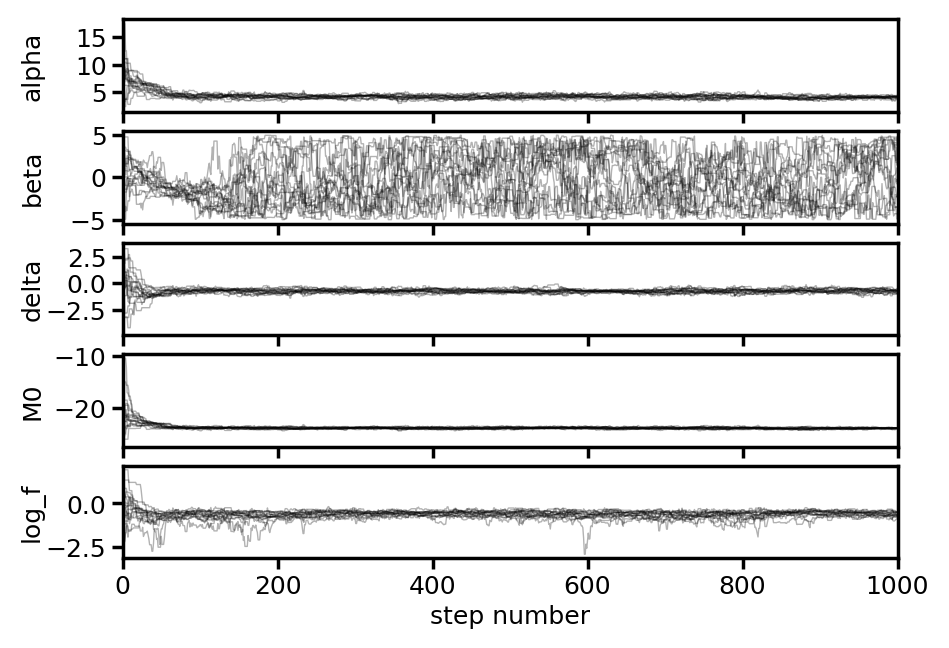

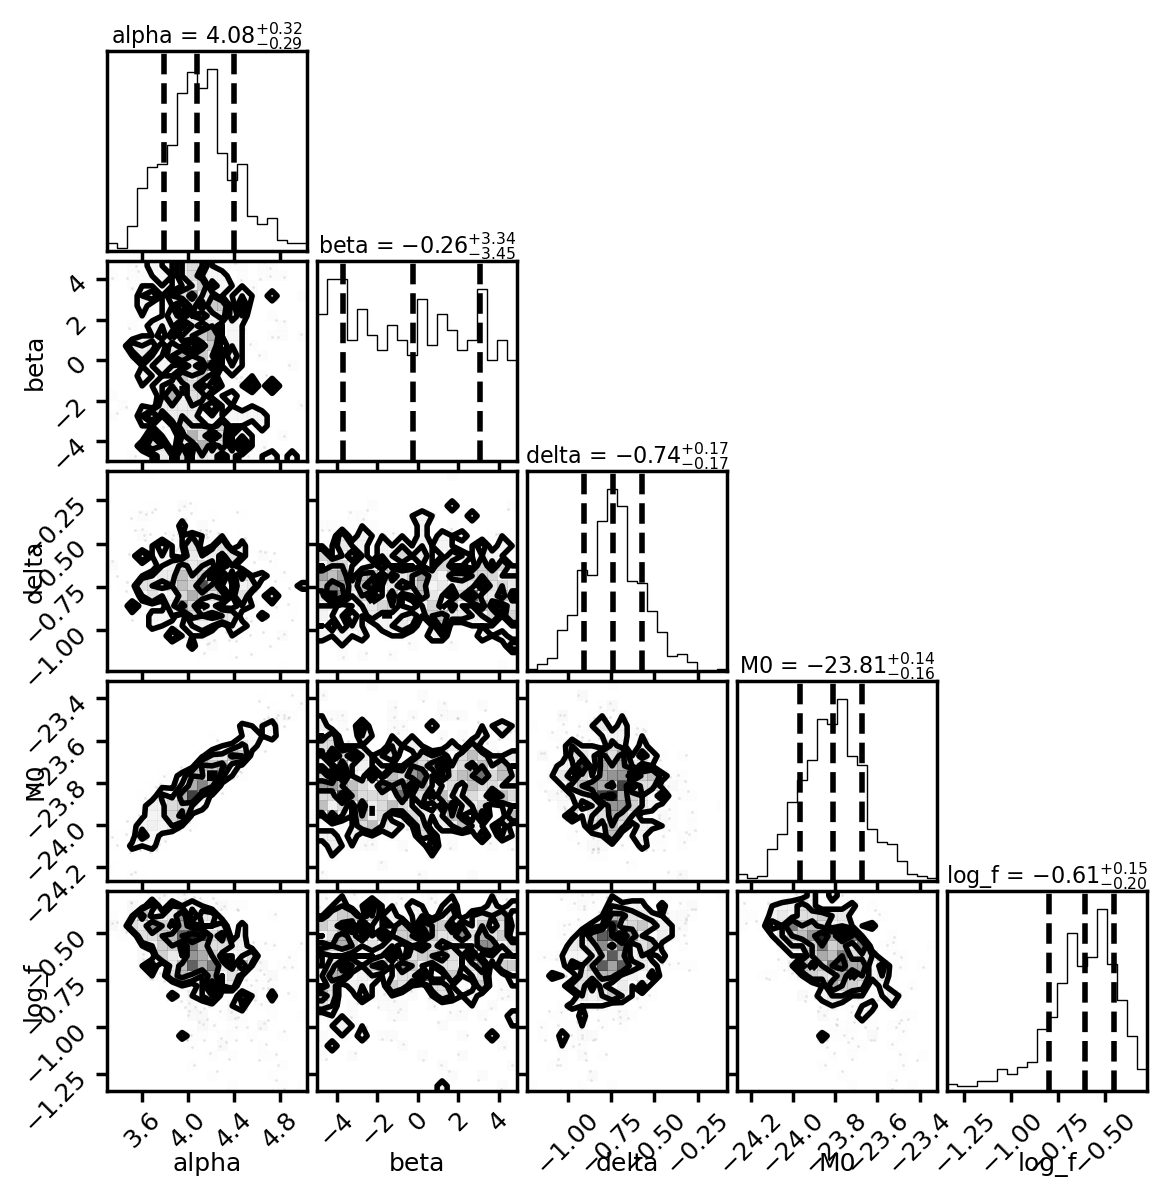

In [833]:
import emcee
import corner
import numpy as np
from astropy.cosmology import w0waCDM
import matplotlib.pyplot as plt

def M_model(M0, alpha, beta, delta):
    return M0 + alpha * (df["log_sigma_RF"]+0.3) + 0 * (df["beta"]+0.5) + delta * (df["log_tau_RF"]-2.5)

def K_corr(z, alpha_nu=-0.5):
    return -2.5 * (1 + alpha_nu) * np.log10(1 + z)

# log_likelihood function
def log_likelihood(theta):

    alpha, beta, delta, M0, log_f = theta

    cosmo = w0waCDM(H0=70, Om0=0.3, Ode0=0.7, w0=-1, wa=0)
    mu_model = cosmo.distmod(df['z']).value

    # Prior
    for i, (key, val) in enumerate(priors.items()):
        lower, upper = val
        if not (lower < theta[i] < upper):
            return -np.inf
    
    mu_pred = df['apparent_mag_i'] - M_model(M0, alpha, beta, delta) - K_corr(df['z'])
    mu_pred_err = np.sqrt(df['apparent_mag_i_err']**2 + 
                          (alpha * df["log_sigma_RF_err"])**2 + 
                          (0 * df["beta_err"])**2 + 
                          (delta * df["log_tau_RF_err"])**2 +
                          (-2.5 * 0.3 * np.log10(1 + df["z"]))**2 + # K-correction error
                          np.exp(2 * log_f))

    dmu_lim = 20.5 - M_model(M0, alpha, beta, delta) - K_corr(df['z']) - mu_model

    return -0.5 * np.sum(((mu_pred - mu_model) / mu_pred_err)**2 + np.log(2 * np.pi * mu_pred_err**2)) + \
            np.sum(np.log(st.truncnorm.cdf(mu_pred - mu_model, loc=0, scale=mu_pred_err, a=-np.inf, b=dmu_lim)))

# Define a dictionary to hold model parameters
priors = {
    "alpha": (2, 20),
    "beta": (-5, 5),
    "delta": (-5, 5),
    "M0": (-30, -10),
    "log_f": (-3, 2),
    # cosmology parameters
    #"H0": (50, 100),
    #"Om0": (0.1, 0.5),
    #"Omk": (-0.5, 0.5),
    #"Oml": (0.1, 0.9),
    #"w0": (-2, 2),
    #"wa": (-2, 2)
}

# Set up the sampler
ndim = len(priors)  # Number of parameters
nwalkers = 16  # Number of walkers
nsteps = 1000  # Number of steps

# Run the MCMC sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood)

# Initial positions of the walkers
initial_pos = np.array([np.random.uniform(low, high, nwalkers) for low, high in priors.values()]).T

sampler.run_mcmc(initial_pos, nsteps, progress=True)

# Extract the samples
samples_by_chain = sampler.get_chain()
#tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

labels = list(priors.keys())

fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_by_chain[:, :, i], "k", alpha=0.3, lw=1)
    ax.set_xlim(0, len(samples_by_chain))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.show()

fig = corner.corner(flat_samples, show_titles=True, labels=labels, quantiles=[0.16, 0.5, 0.84],
                    label_kwargs=dict(fontsize=18), title_kwargs=dict(fontsize=16));
plt.show()

results = {key: np.percentile(flat_samples[:, i], [16, 50, 84]) for i, key in enumerate(priors.keys())}

In [834]:
print(f'scatter = {np.sqrt(np.exp(2 * results['log_f'][1]))}') 


scatter = 0.5460001949372396


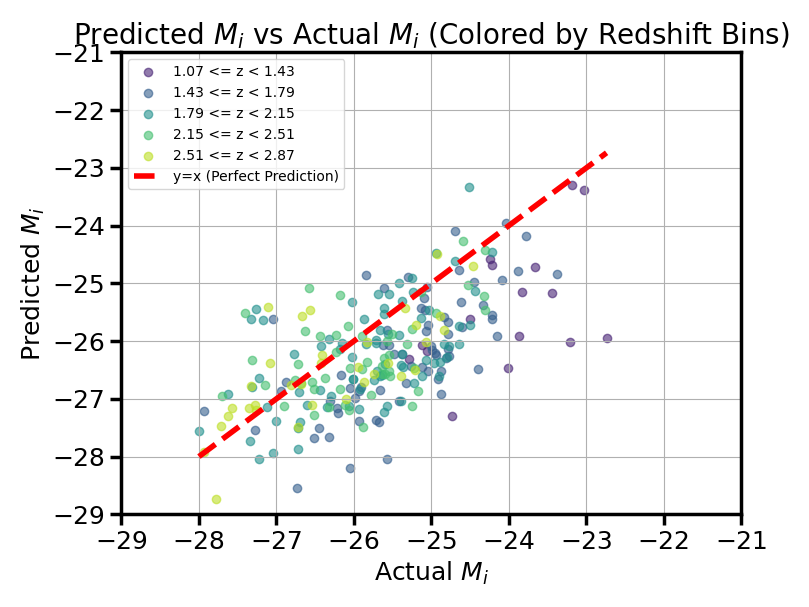

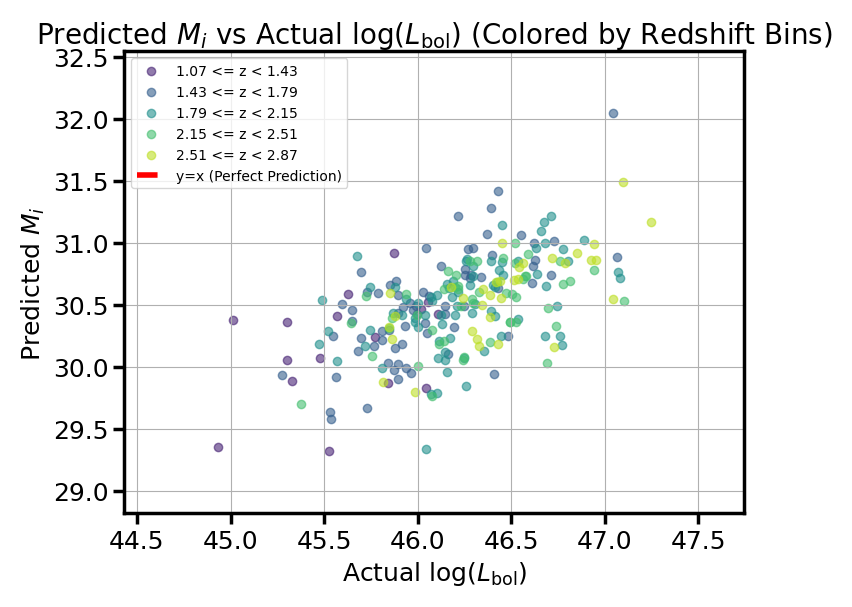

In [835]:

plt.figure(figsize=(8, 6))

# Assuming `predicted_M_i` contains the predicted M_i values
M_i_pred = M_model(
    results['M0'][1], 
    results['alpha'][1]+2, 
    results['beta'][1],
    results['delta'][1]
)
# Extract actual M_i values from the dataframe
actual_M_i = df['M_i']

# Define redshift bins
redshift_bins = np.linspace(df['z'].min(), df['z'].max(), 6)

# Use the viridis color scale for the scatter plot, coloring each redshift bin
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=redshift_bins.min(), vmax=redshift_bins.max())

for i in range(len(redshift_bins) - 1):
    bin_mask = (df['z'] >= redshift_bins[i]) & (df['z'] < redshift_bins[i + 1])
    plt.scatter(
        actual_M_i[bin_mask],
        M_i_pred[bin_mask],
        color=cmap(norm((redshift_bins[i] + redshift_bins[i + 1]) / 2)),
        label=f'{redshift_bins[i]:.2f} <= z < {redshift_bins[i + 1]:.2f}',
        alpha=0.6,
    )

# Add a colorbar for the redshift bins
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#plt.colorbar(sm, label='Redshift (z)')

# Add a perfect prediction line
plt.plot(
    [actual_M_i.min(), actual_M_i.max()],
    [actual_M_i.min(), actual_M_i.max()],
    'r--',
    label='y=x (Perfect Prediction)'
)

plt.xlabel('Actual $M_i$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $M_i$ (Colored by Redshift Bins)')
plt.xlim(-29, -21)
plt.ylim(-29, -21)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

# Calculate predicted log_lbol from M_i_pred
# Assuming the relation log_lbol = -0.4 * M_i_pred + constant
# Here, the constant is chosen to match the scale of the data
constant = 20  # Adjust this value as needed
predicted_log_lbol = -0.4 * M_i_pred + constant

plt.figure(figsize=(8, 6))

# Extract log_lbol values from the dataframe
actual_log_lbol = df['log_lbol']

# Define redshift bins
redshift_bins = np.linspace(df['z'].min(), df['z'].max(), 6)

# Use the viridis color scale for the scatter plot, coloring each redshift bin
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=redshift_bins.min(), vmax=redshift_bins.max())

for i in range(len(redshift_bins) - 1):
    bin_mask = (df['z'] >= redshift_bins[i]) & (df['z'] < redshift_bins[i + 1])
    plt.scatter(
        actual_log_lbol[bin_mask],
        predicted_log_lbol[bin_mask],
        color=cmap(norm((redshift_bins[i] + redshift_bins[i + 1]) / 2)),
        label=f'{redshift_bins[i]:.2f} <= z < {redshift_bins[i + 1]:.2f}',
        alpha=0.6,
    )

# Add a colorbar for the redshift bins
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add a perfect prediction line
plt.plot(
    [actual_log_lbol.min(), actual_log_lbol.max()],
    [actual_log_lbol.min(), actual_log_lbol.max()],
    'r--',
    label='y=x (Perfect Prediction)'
)

plt.xlabel('Actual $\\log(L_{\\mathrm{bol}})$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $\\log(L_{\\mathrm{bol}})$ (Colored by Redshift Bins)')
plt.xlim(actual_log_lbol.min() - 0.5, actual_log_lbol.max() + 0.5)
plt.ylim(predicted_log_lbol.min() - 0.5, predicted_log_lbol.max() + 0.5)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

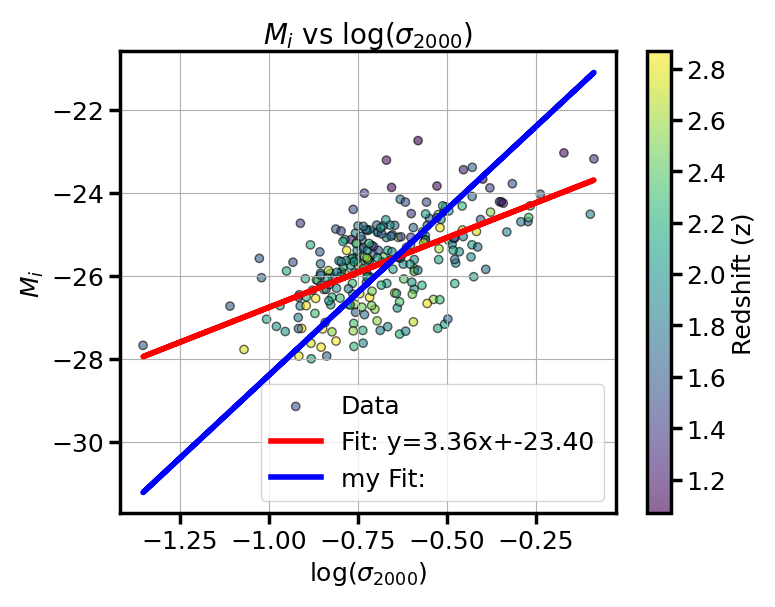

In [836]:
from scipy.stats import linregress

import matplotlib.pyplot as plt

# Extract the data
x = df['log_sigma_RF']
y = df['M_i']

# Fit a line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
y_fit = slope * x + intercept

# Plot the data and the fitted line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=df['z'], alpha=0.6, edgecolor='black', label='Data')
plt.plot(x, y_fit, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')

y_fit = 8 * x + intercept + 3
plt.plot(x, y_fit, 'b-', label=f'my Fit: ')

plt.xlabel(r"$\log(\sigma_{2000})$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\log(\sigma_{2000})$")
plt.legend()
plt.grid(True)
plt.colorbar(label='Redshift (z)')
plt.show()

                            OLS Regression Results                            
Dep. Variable:               log_lbol   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     54.12
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           4.51e-20
Time:                        20:13:39   Log-Likelihood:                -56.492
No. Observations:                 239   AIC:                             119.0
Df Residuals:                     236   BIC:                             129.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           44.3147      0.259    171.252   

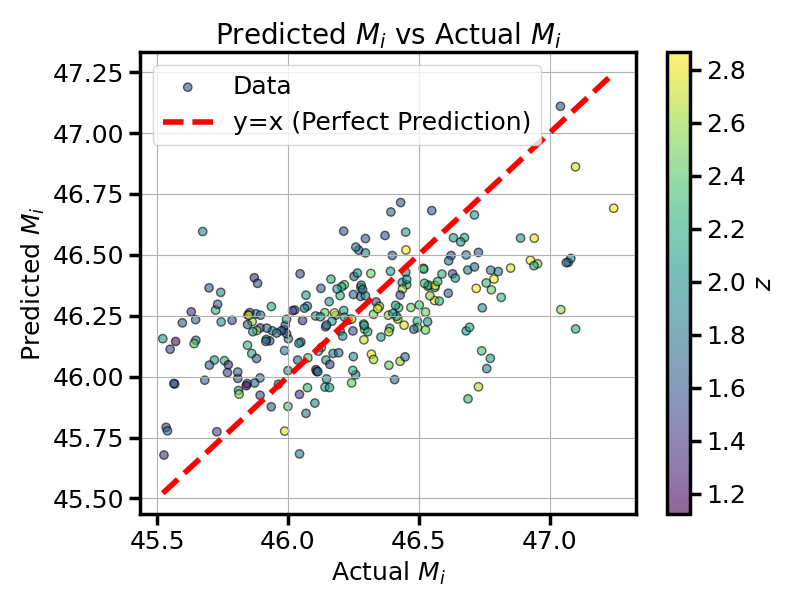

In [823]:
import statsmodels.api as sm


df_filtered = df[(df['z'] > 0.0) & (df['z'] < 5)]
df_filtered = df[df['log_lbol'] > 45.5]
#df_filtered = df[(df['z'] > 2.2) & (df['z'] < 2.6)]


# Prepare the data
X = df_filtered[['log_sigma_RF', 'log_tau_RF']]  # Predictors
y = df_filtered['log_lbol']  # Target variable (M0)

# Add a constant to the predictors (for the intercept term)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary of the regression
print(model.summary())

# Extract the predicted values
y_pred = model.predict(X)

# Plot the actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, c=df_filtered['z'], cmap='viridis', alpha=0.6, edgecolor='black', label='Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='y=x (Perfect Prediction)')
plt.colorbar(label=r"$z$")
plt.xlabel('Actual $M_i$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $M_i$')
plt.legend()
plt.grid(True)
plt.show()

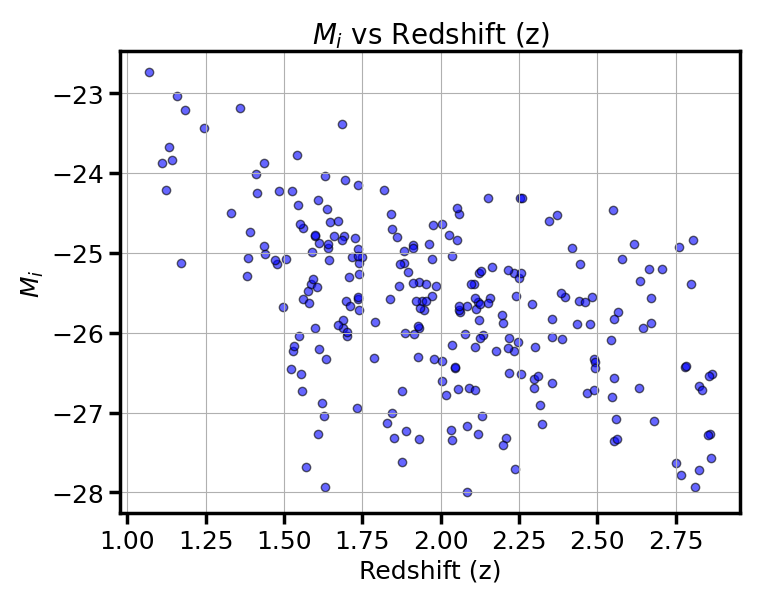

In [837]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel(r'$M_i$')
plt.title(r'$M_i$ vs Redshift (z)')
plt.grid(True)
plt.show()

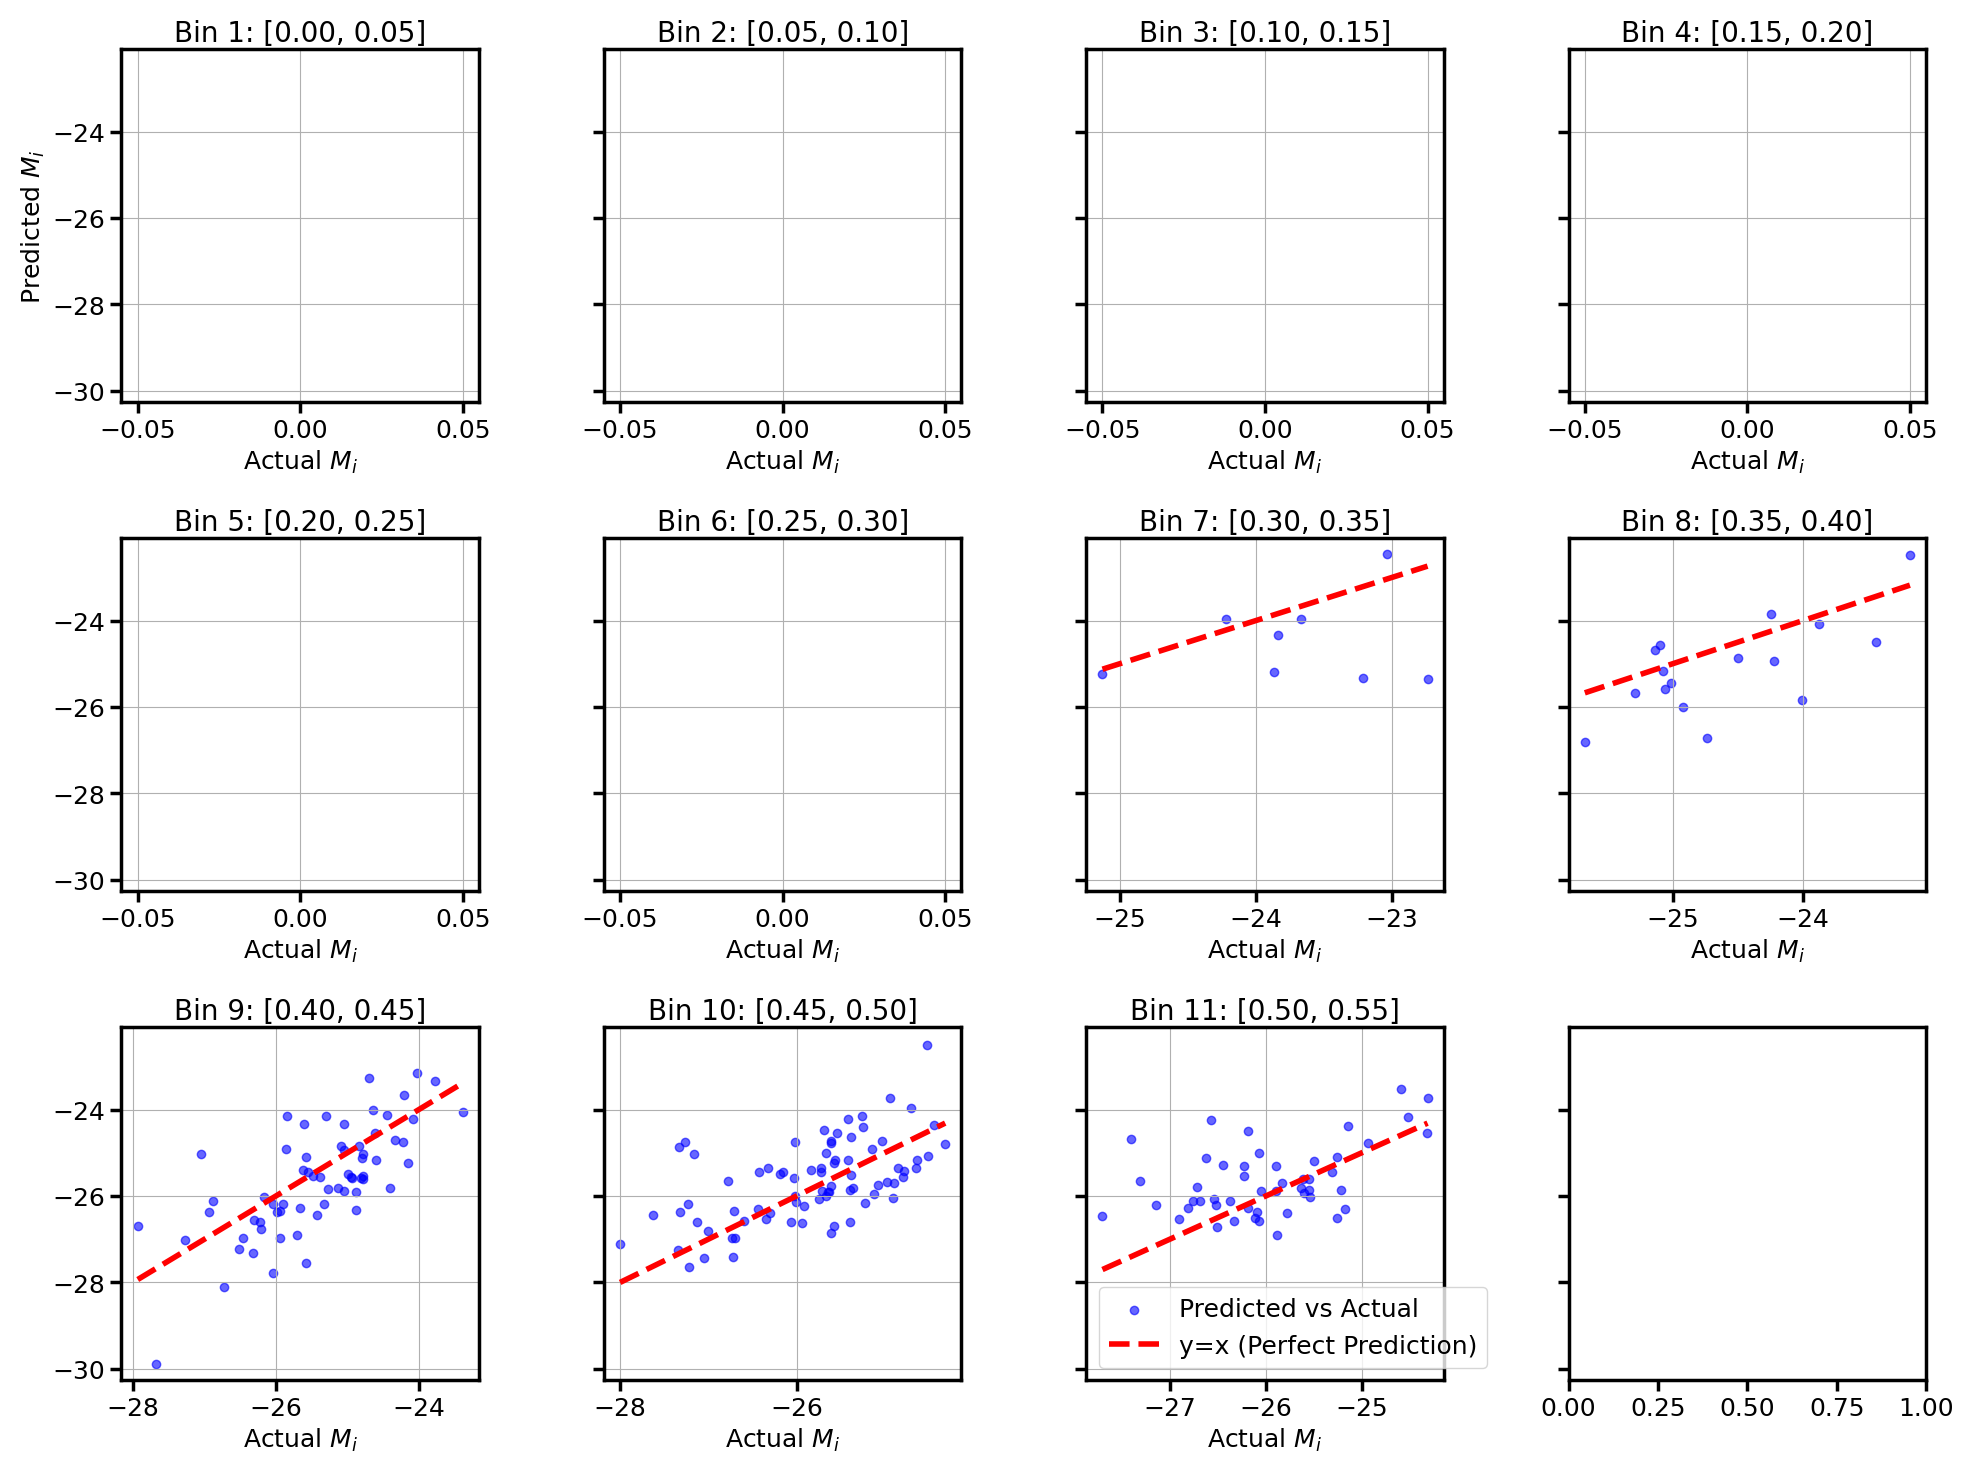

In [825]:
import matplotlib.pyplot as plt
# Define the bins for np.log10(1 + df['z'])
bins = np.arange(0, np.log10(1 + df['z']).max(), 0.05)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Iterate over each bin and plot
for i in range(len(bins) - 1):
    bin_mask = (np.log10(1 + df['z']) >= bins[i]) & (np.log10(1 + df['z']) < bins[i + 1])
    bin_data_actual = actual_M_i[bin_mask]
    bin_data_predicted = M_i_pred[bin_mask]
    
    axes[i].scatter(bin_data_actual, bin_data_predicted, c='blue', alpha=0.6, label='Predicted vs Actual')
    axes[i].plot([bin_data_actual.min(), bin_data_actual.max()], 
                 [bin_data_actual.min(), bin_data_actual.max()], 'r--', label='y=x (Perfect Prediction)')
    axes[i].set_title(f'Bin {i+1}: [{bins[i]:.2f}, {bins[i+1]:.2f}]')
    axes[i].set_xlabel('Actual $M_i$')
    if i == 0:
        axes[i].set_ylabel('Predicted $M_i$')
    axes[i].grid(True)
axes[i].legend()
    
plt.tight_layout()
plt.show()

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/1999175955.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


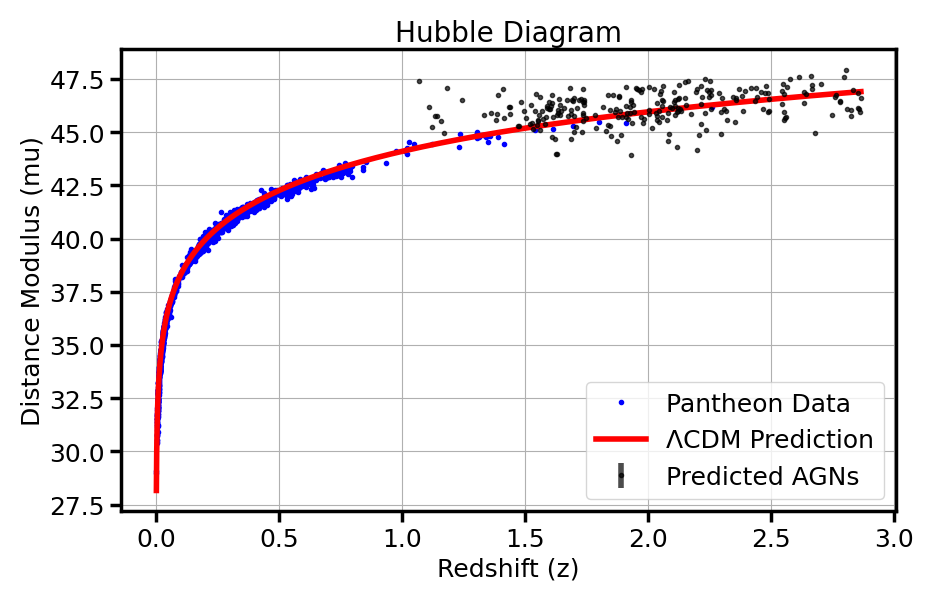

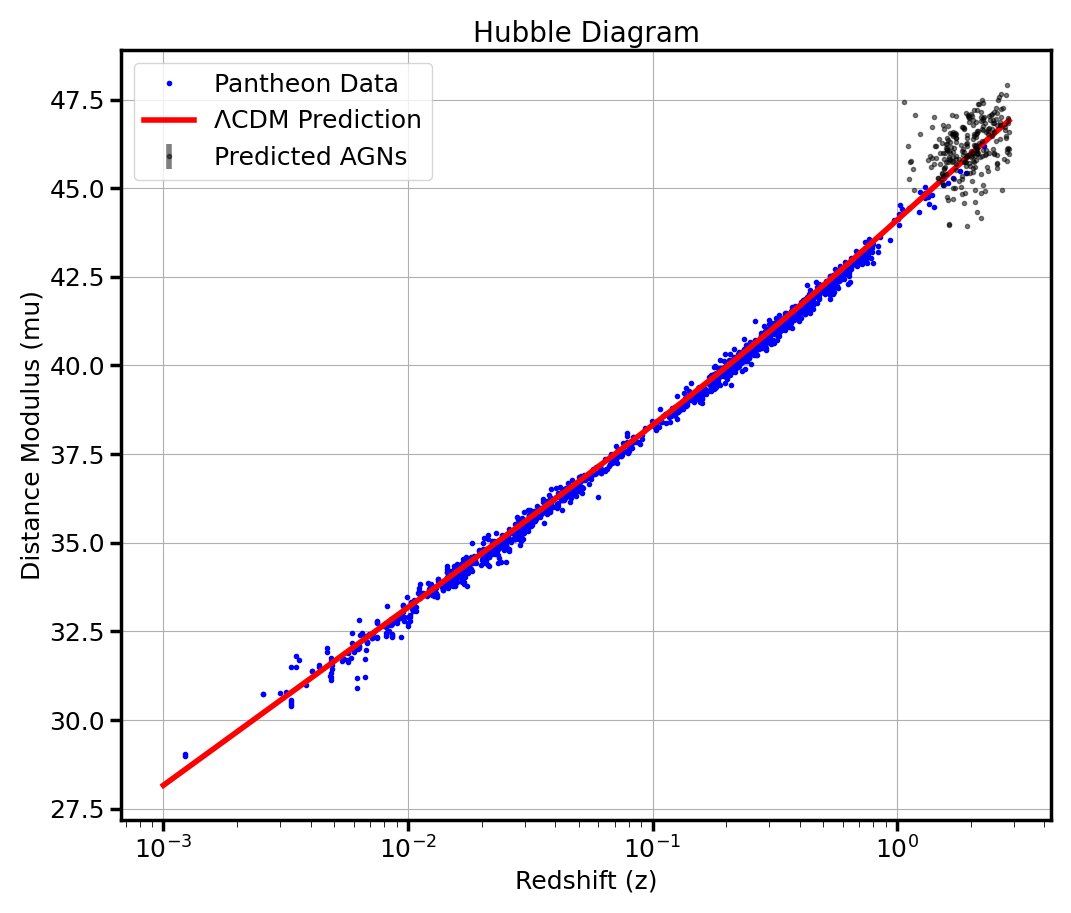

In [838]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon


#mu_pred = d['apparent_mag_i'] - M_model(posterior_samples["alpha"], posterior_samples["beta"], posterior_samples["mu"], posterior_samples["nu"], d["color"], d["log_sigma_3"], d["log_tau_RF"], posterior_samples["M0"], d["z"]) - K_corr(d["z"])
#mu_pred_median = np.percentile(mu_pred, 50, axis=0)
mu_pred = np.array([df['apparent_mag_i'] - M_model(s[3], s[0], s[1], s[2]) - K_corr(df["z"]) for s in flat_samples])
#mu_pred = np.array([df['apparent_mag_i'] - M_model(s[3]+1, 14, s[1], s[2]) - K_corr(df["z"]) for s in flat_samples])

mu_pred_median = np.percentile(mu_pred, 50, axis=0)

#mu_pred_std = np.abs(0.5 * (mu_pred_84th - mu_pred_16th))

plt.figure(figsize=(10, 6))
#plt.errorbar(d["z"], mu, yerr=dmu, fmt='o', label="Observed AGNs", alpha=0.5, color="blue")
plt.errorbar(df["z"], mu_pred_median, yerr=0, fmt='.', label="Predicted AGNs", alpha=0.7, color="black")
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")


z_grid = np.geomspace(0.001, df['z'].max(), 1000)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
plt.plot(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram")
plt.legend()
plt.grid(True)
plt.show()

plt.errorbar(df["z"], mu_pred_median, yerr=0, fmt='.', label="Predicted AGNs", alpha=0.5, color="k")
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")
plt.semilogx(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram")
plt.legend()
plt.grid(True)
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/692567285.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')


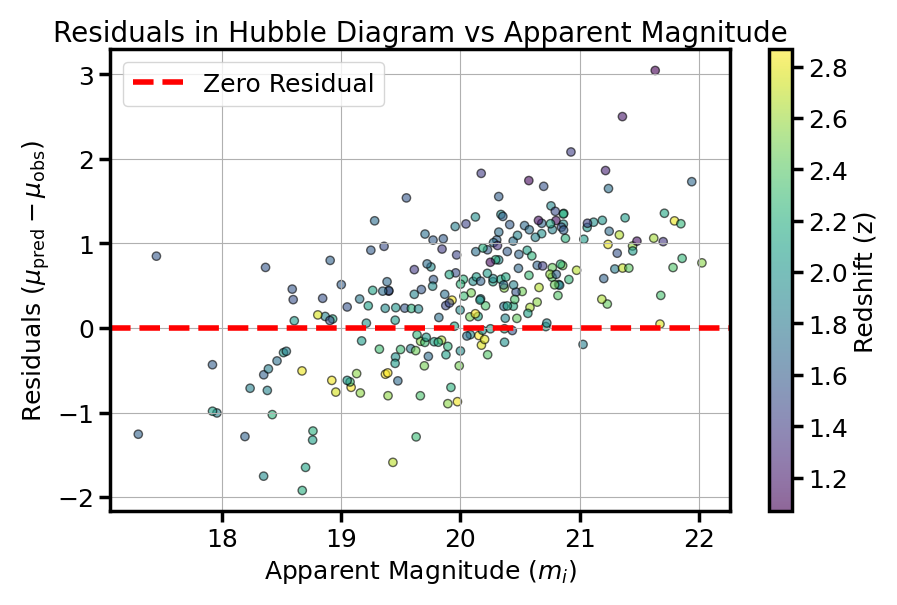

In [839]:
import matplotlib.pyplot as plt

# Calculate the observed distance modulus (mu_obs)
mu_obs = df['apparent_mag_i'] - df['M_i']

# Calculate the residuals (difference between predicted and observed distance modulus)
residuals = mu_pred_median - mu_obs

# Use d['z'] as the color for the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['apparent_mag_i'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Apparent Magnitude ($m_i$)')
plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Apparent Magnitude')
plt.colorbar(scatter, label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/87464218.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')


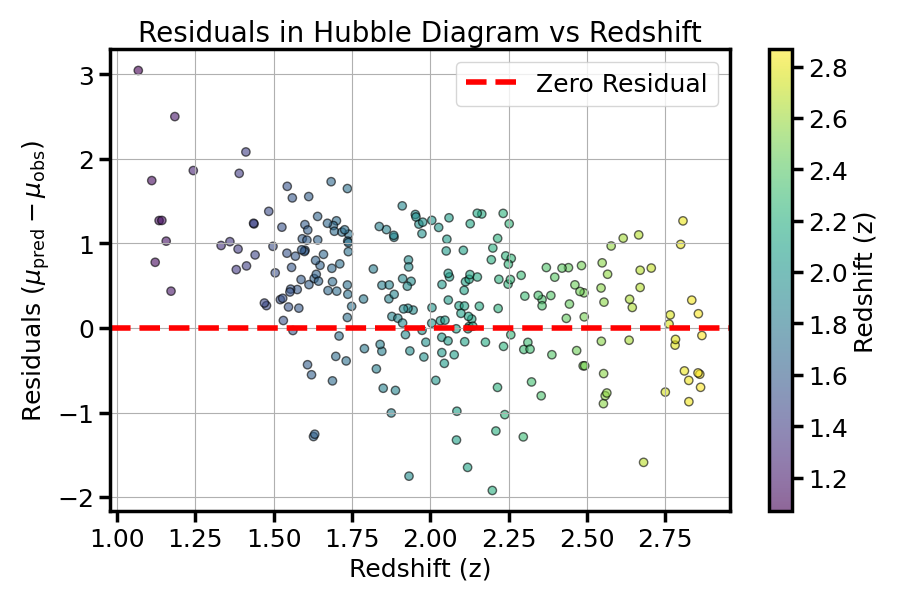

In [840]:
import matplotlib.pyplot as plt

# Plot residuals vs redshift
plt.figure(figsize=(10, 6))
plt.scatter(df['z'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Redshift (z)')
plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Redshift')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

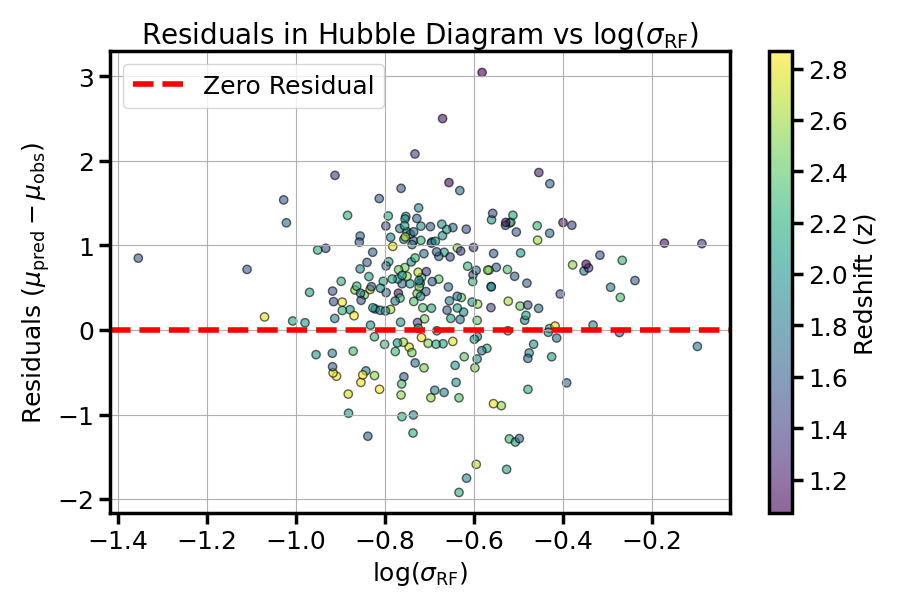

In [841]:
import matplotlib.pyplot as plt

# Plot residuals vs log_sigma_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['log_sigma_RF'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(\sigma_\mathrm{RF})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(\sigma_\mathrm{RF})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

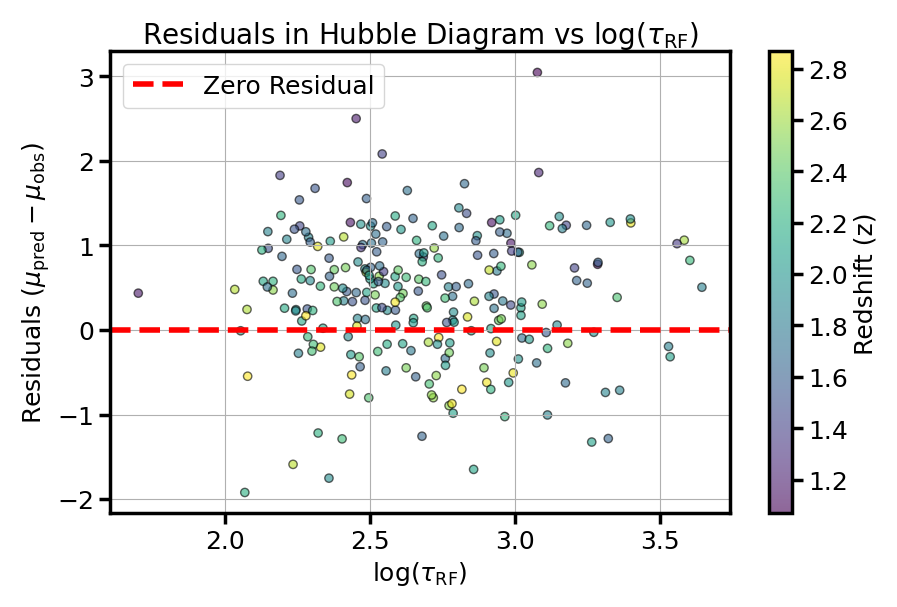

In [842]:
import matplotlib.pyplot as plt

# Plot residuals vs log_tau_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['log_tau_RF'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(\tau_\mathrm{RF})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(\tau_\mathrm{RF})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

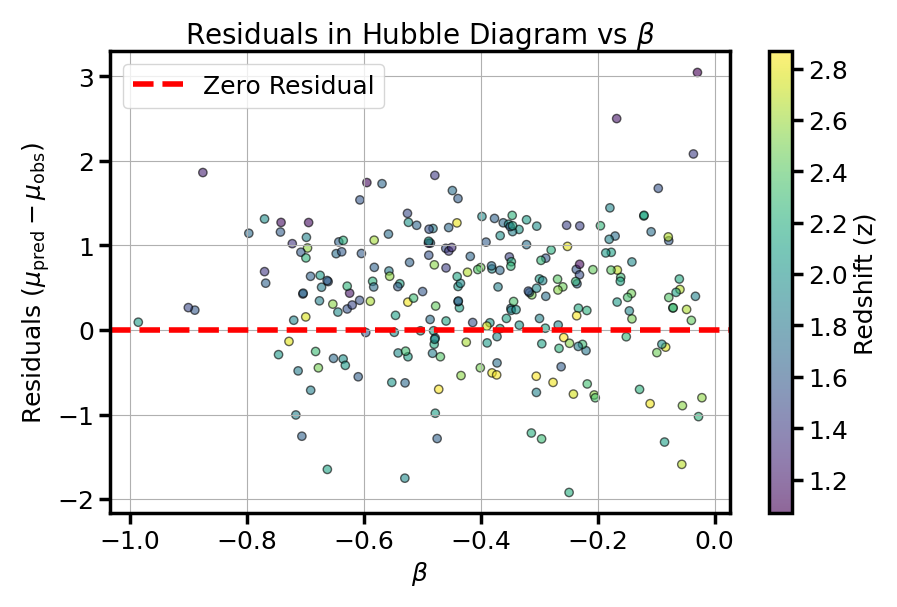

In [843]:

# Plot residuals vs log_tau_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['beta'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\beta$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\beta$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

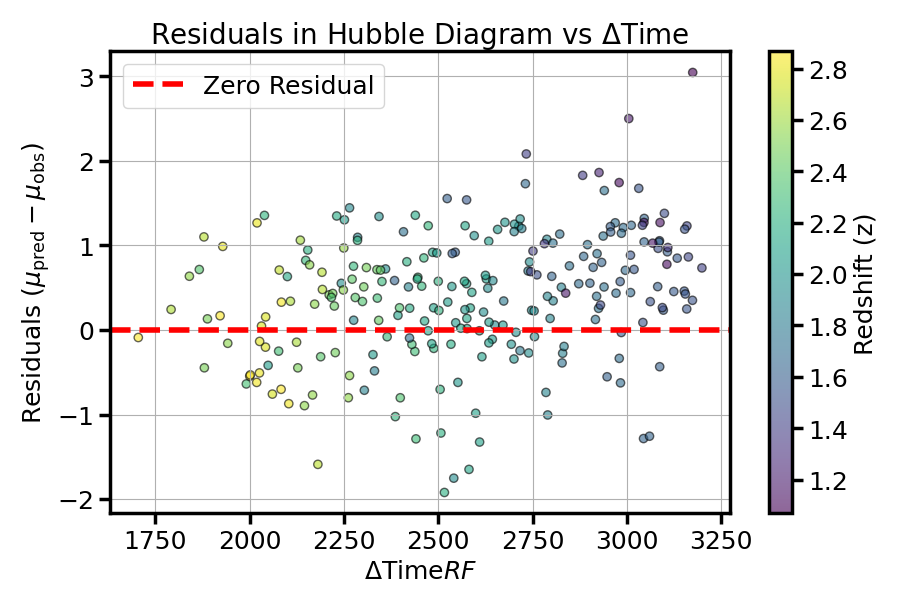

In [844]:
plt.figure(figsize=(10, 6))
plt.scatter(df['delta_time']/(1+df['z']), residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\Delta \mathrm{Time} RF$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\Delta \mathrm{Time}$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

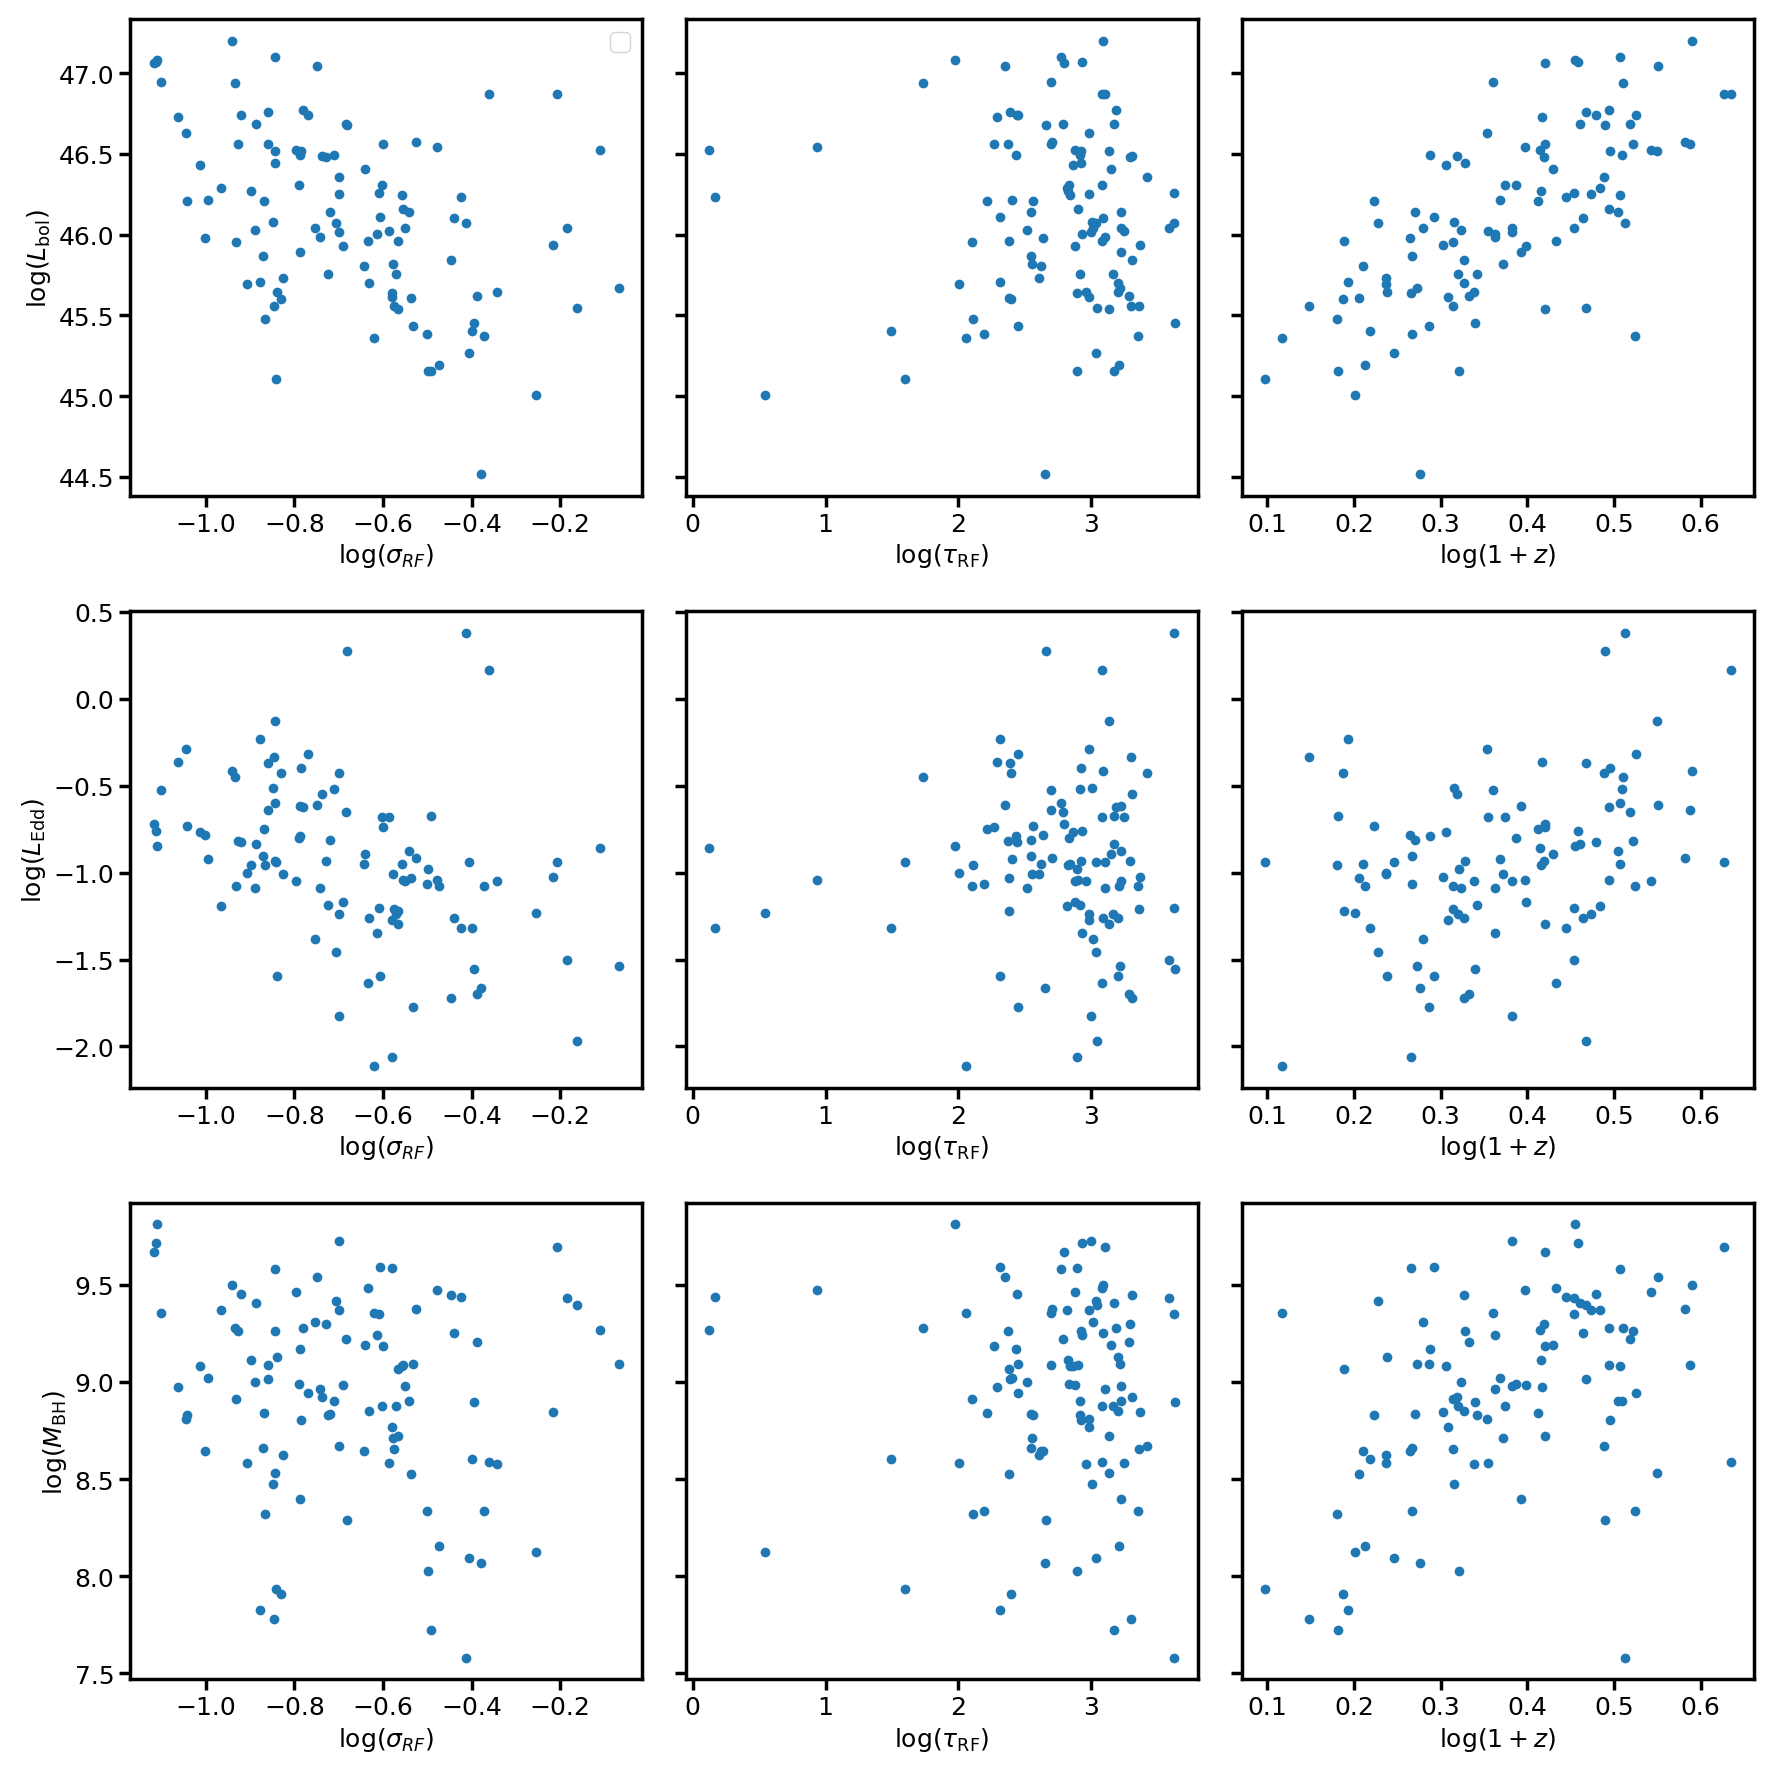

In [ ]:

fig, axs = plt.subplots(3, 3, figsize=(3*6, 3*6), sharey='row')

# First row
ax = axs[0, 0]
#ax.scatter(df['log_sigma'], df['log_lbol'], marker='.')
ax.scatter(df['log_sigma_RF'], df['log_lbol'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
ax.legend()

ax = axs[0, 1]
ax.scatter(df['log_tau_RF'], df['log_lbol'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[0, 2]
ax.scatter(np.log10(1+df['z']), df['log_lbol'])
ax.set_xlabel(r"$\log(1+z)$")

# Second row
ax = axs[1, 0]
ax.scatter(df['log_sigma_RF'], df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{Edd})$")

ax = axs[1, 1]
ax.scatter(df['log_tau_RF'], df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[1, 2]
ax.scatter(np.log10(1+df['z']), df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(1+z)$")

# Third row
ax = axs[2, 0]
ax.scatter(df['log_sigma_RF'], df['log_mbh'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(M_\mathrm{BH})$")

ax = axs[2, 1]
ax.scatter(df['log_tau_RF'], df['log_mbh'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[2, 2]
ax.scatter(np.log10(1+df['z']), df['log_mbh'])
ax.set_xlabel(r"$\log(1+z)$")

plt.tight_layout()
plt.show()
plt.close()

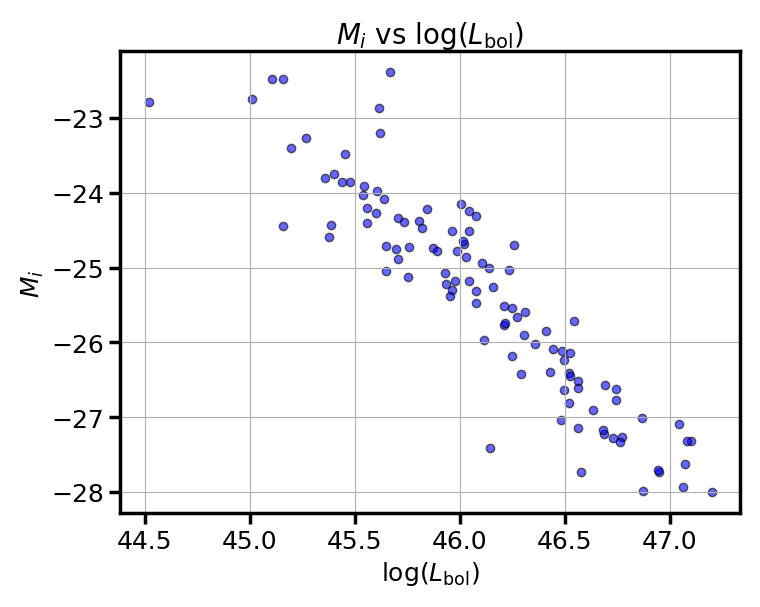

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_lbol'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\log(L_\mathrm{bol})$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\log(L_\mathrm{bol})$")
plt.grid(True)
plt.show()

Plotting for range: 0.00 to 0.05


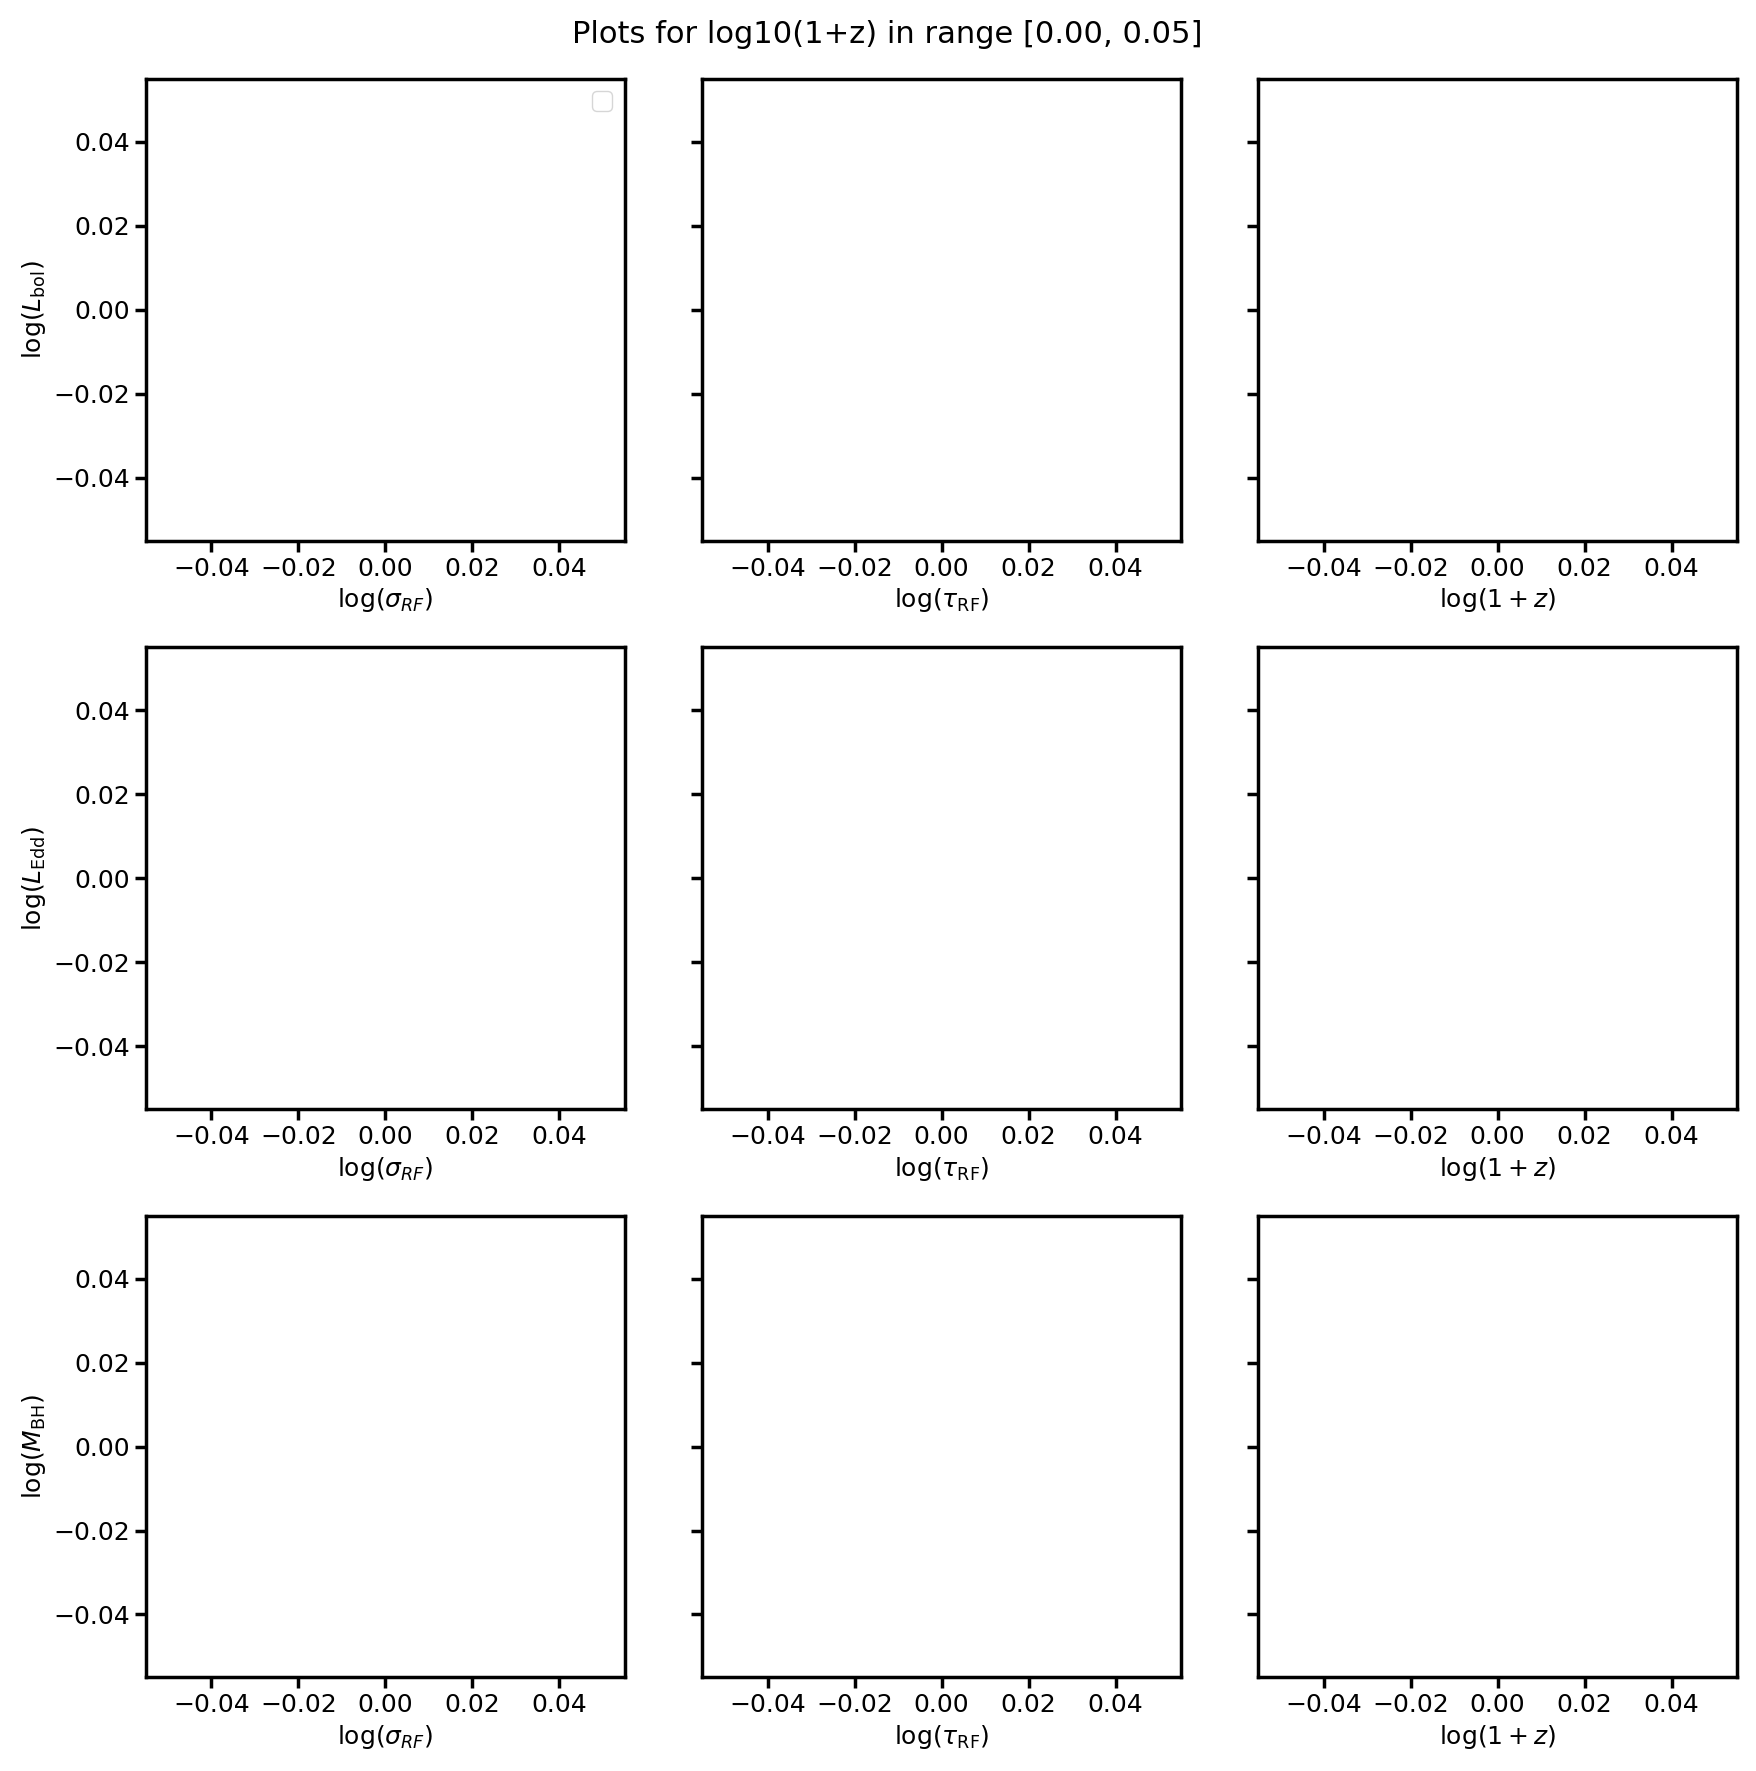

Plotting for range: 0.05 to 0.10


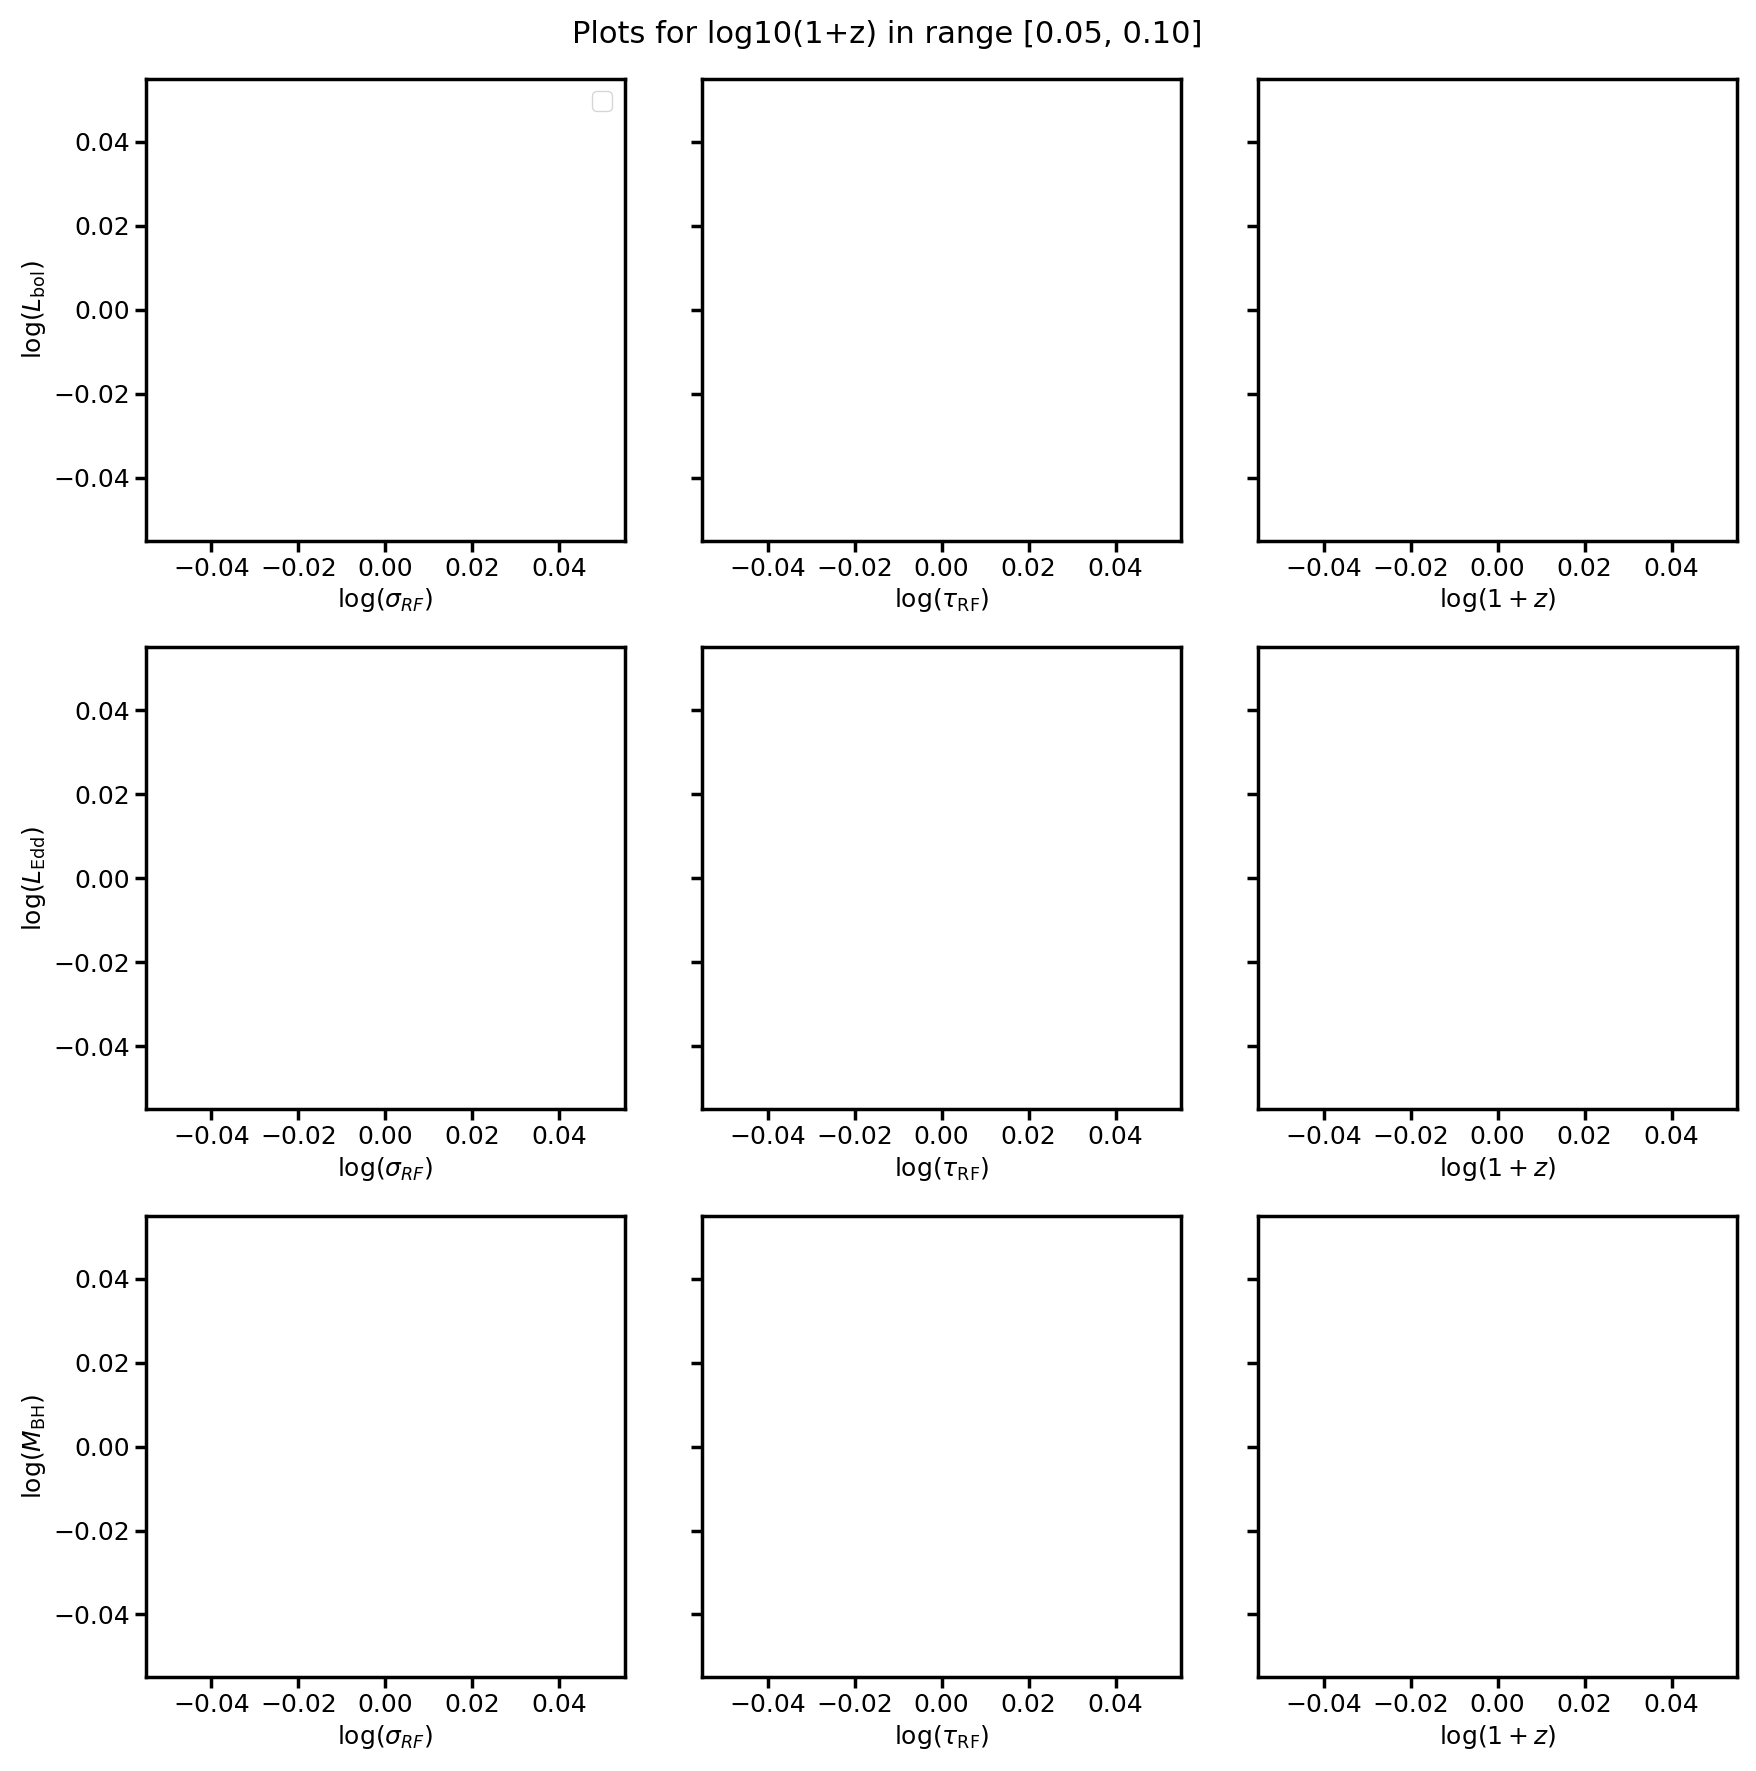

Plotting for range: 0.10 to 0.15


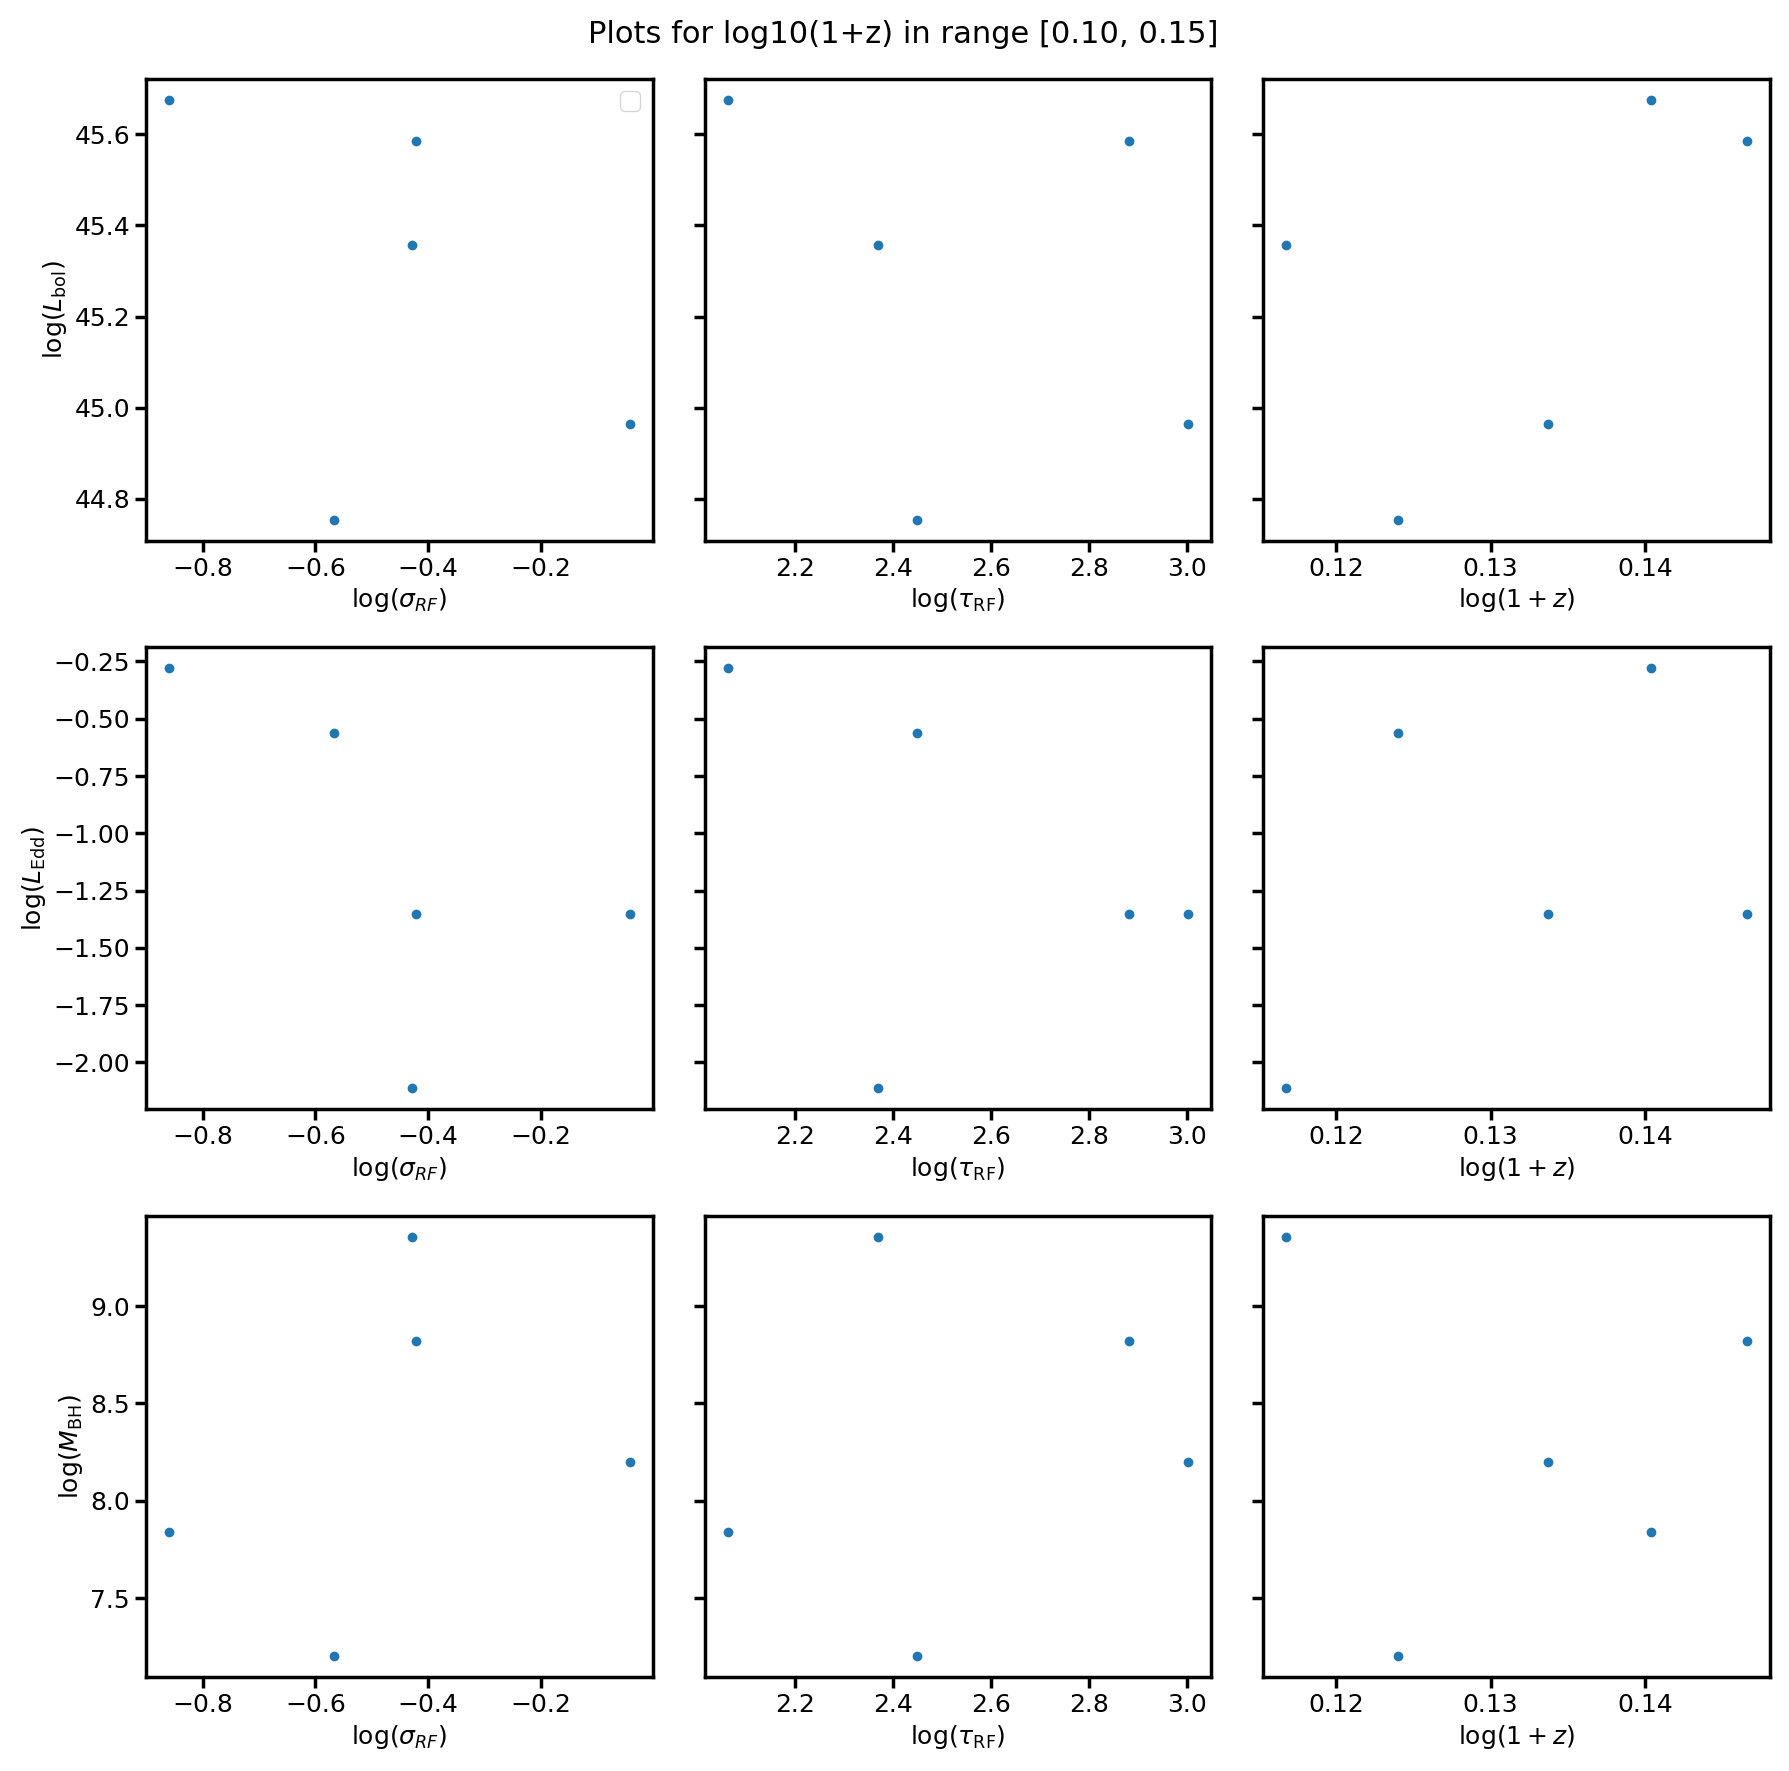

Plotting for range: 0.15 to 0.20


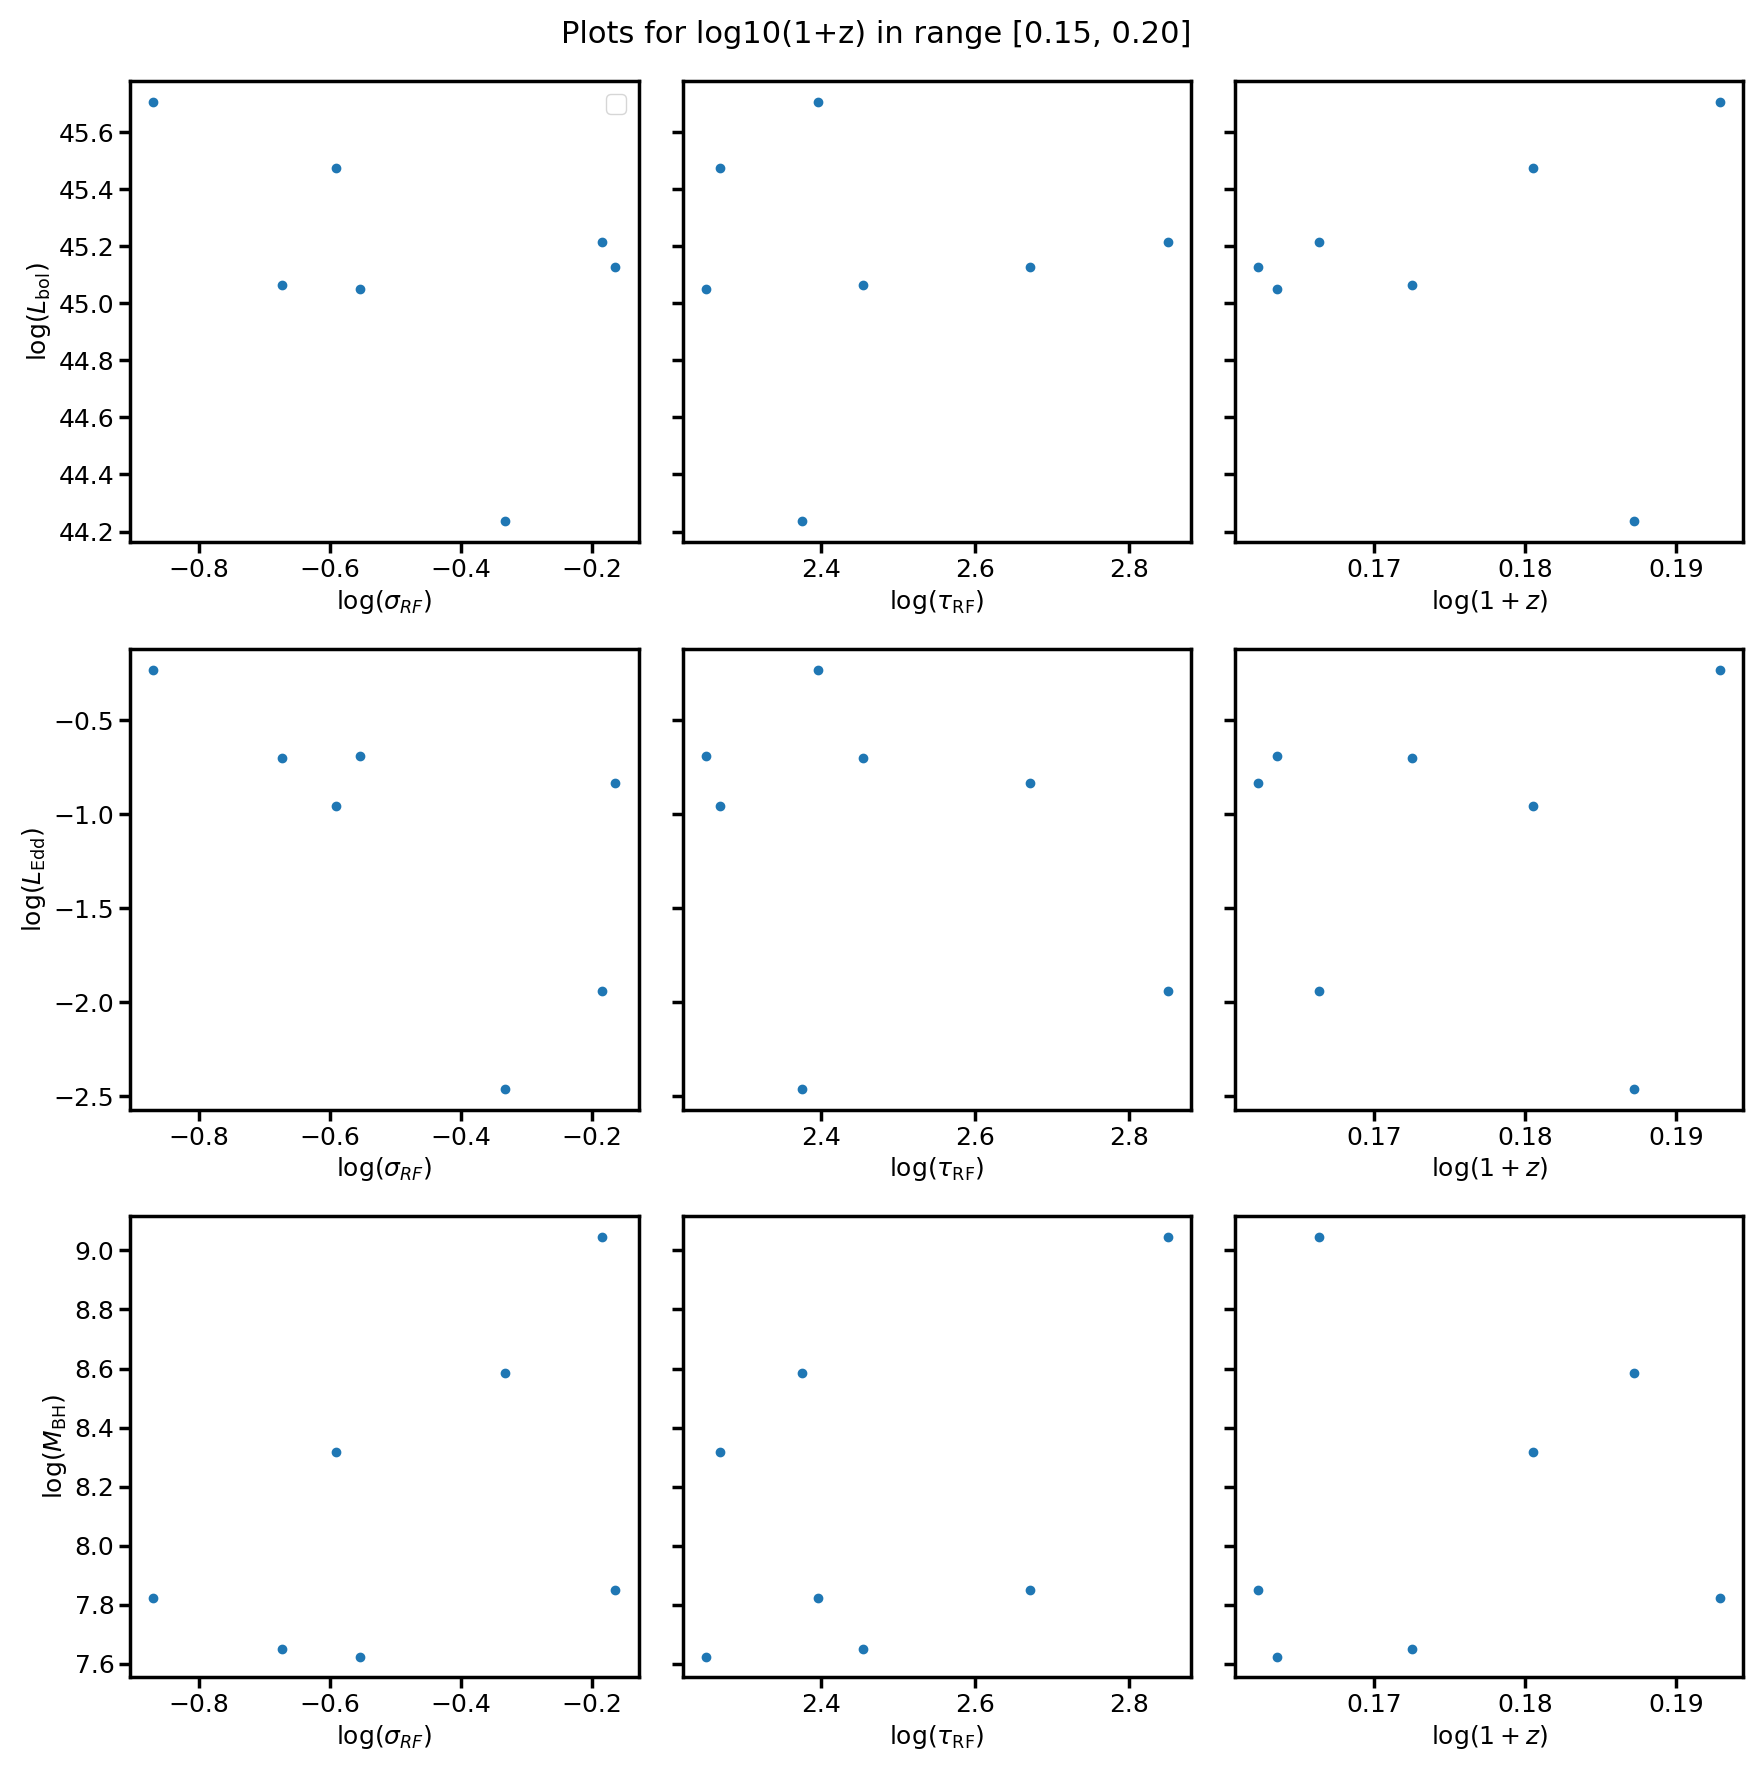

Plotting for range: 0.20 to 0.25


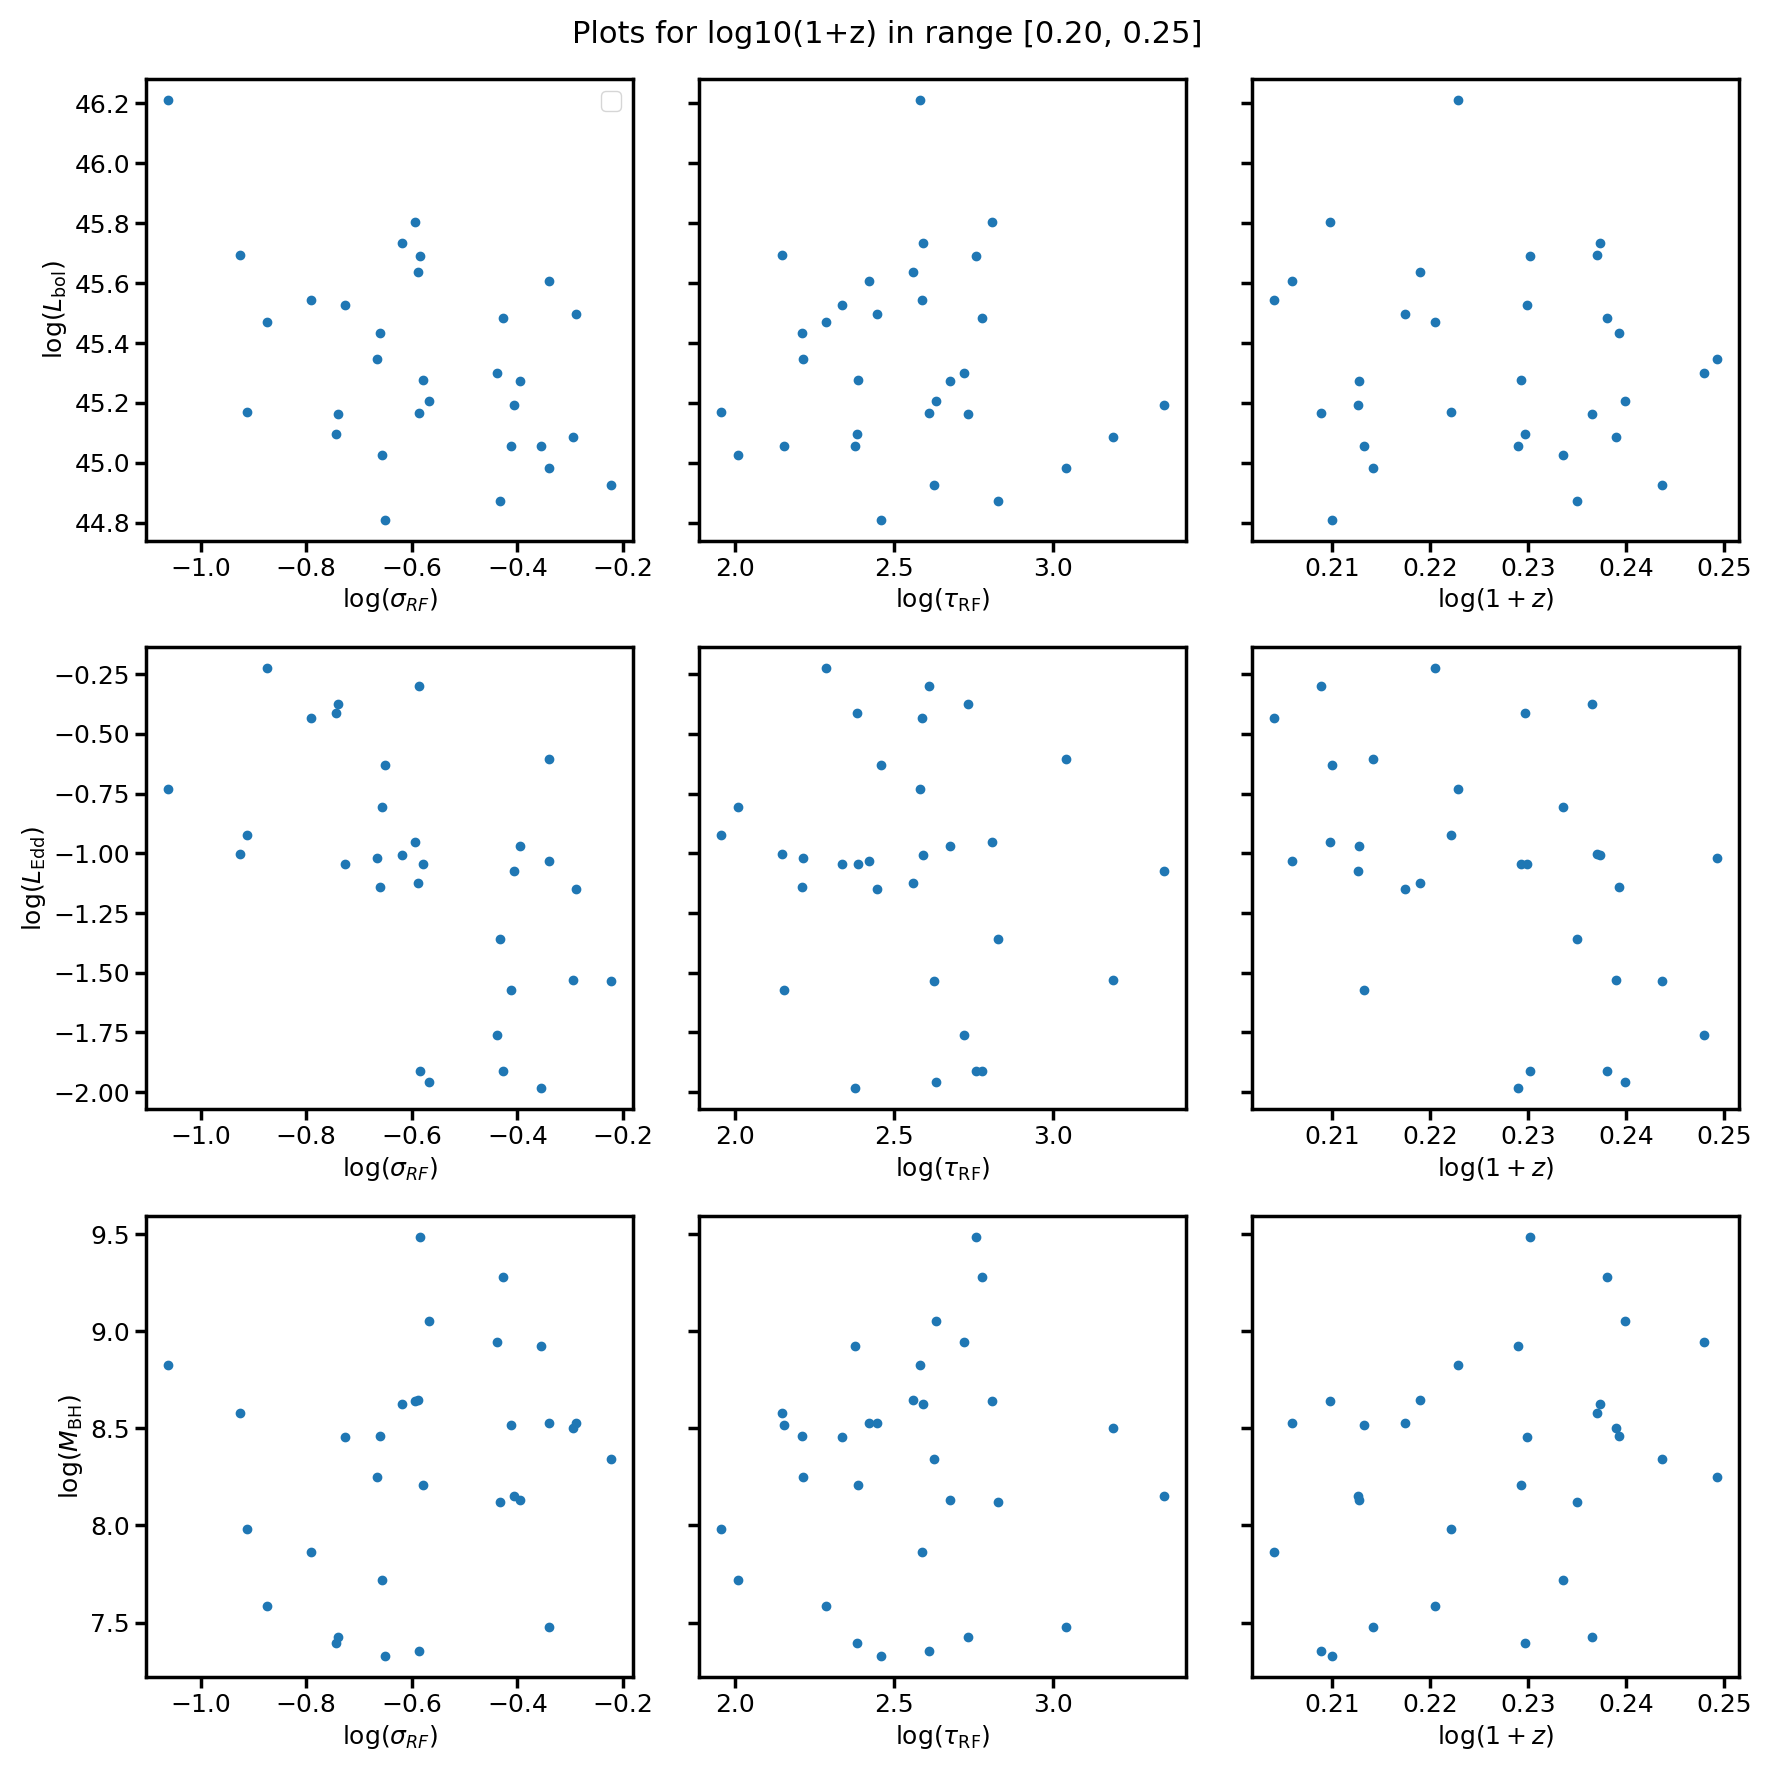

Plotting for range: 0.25 to 0.30


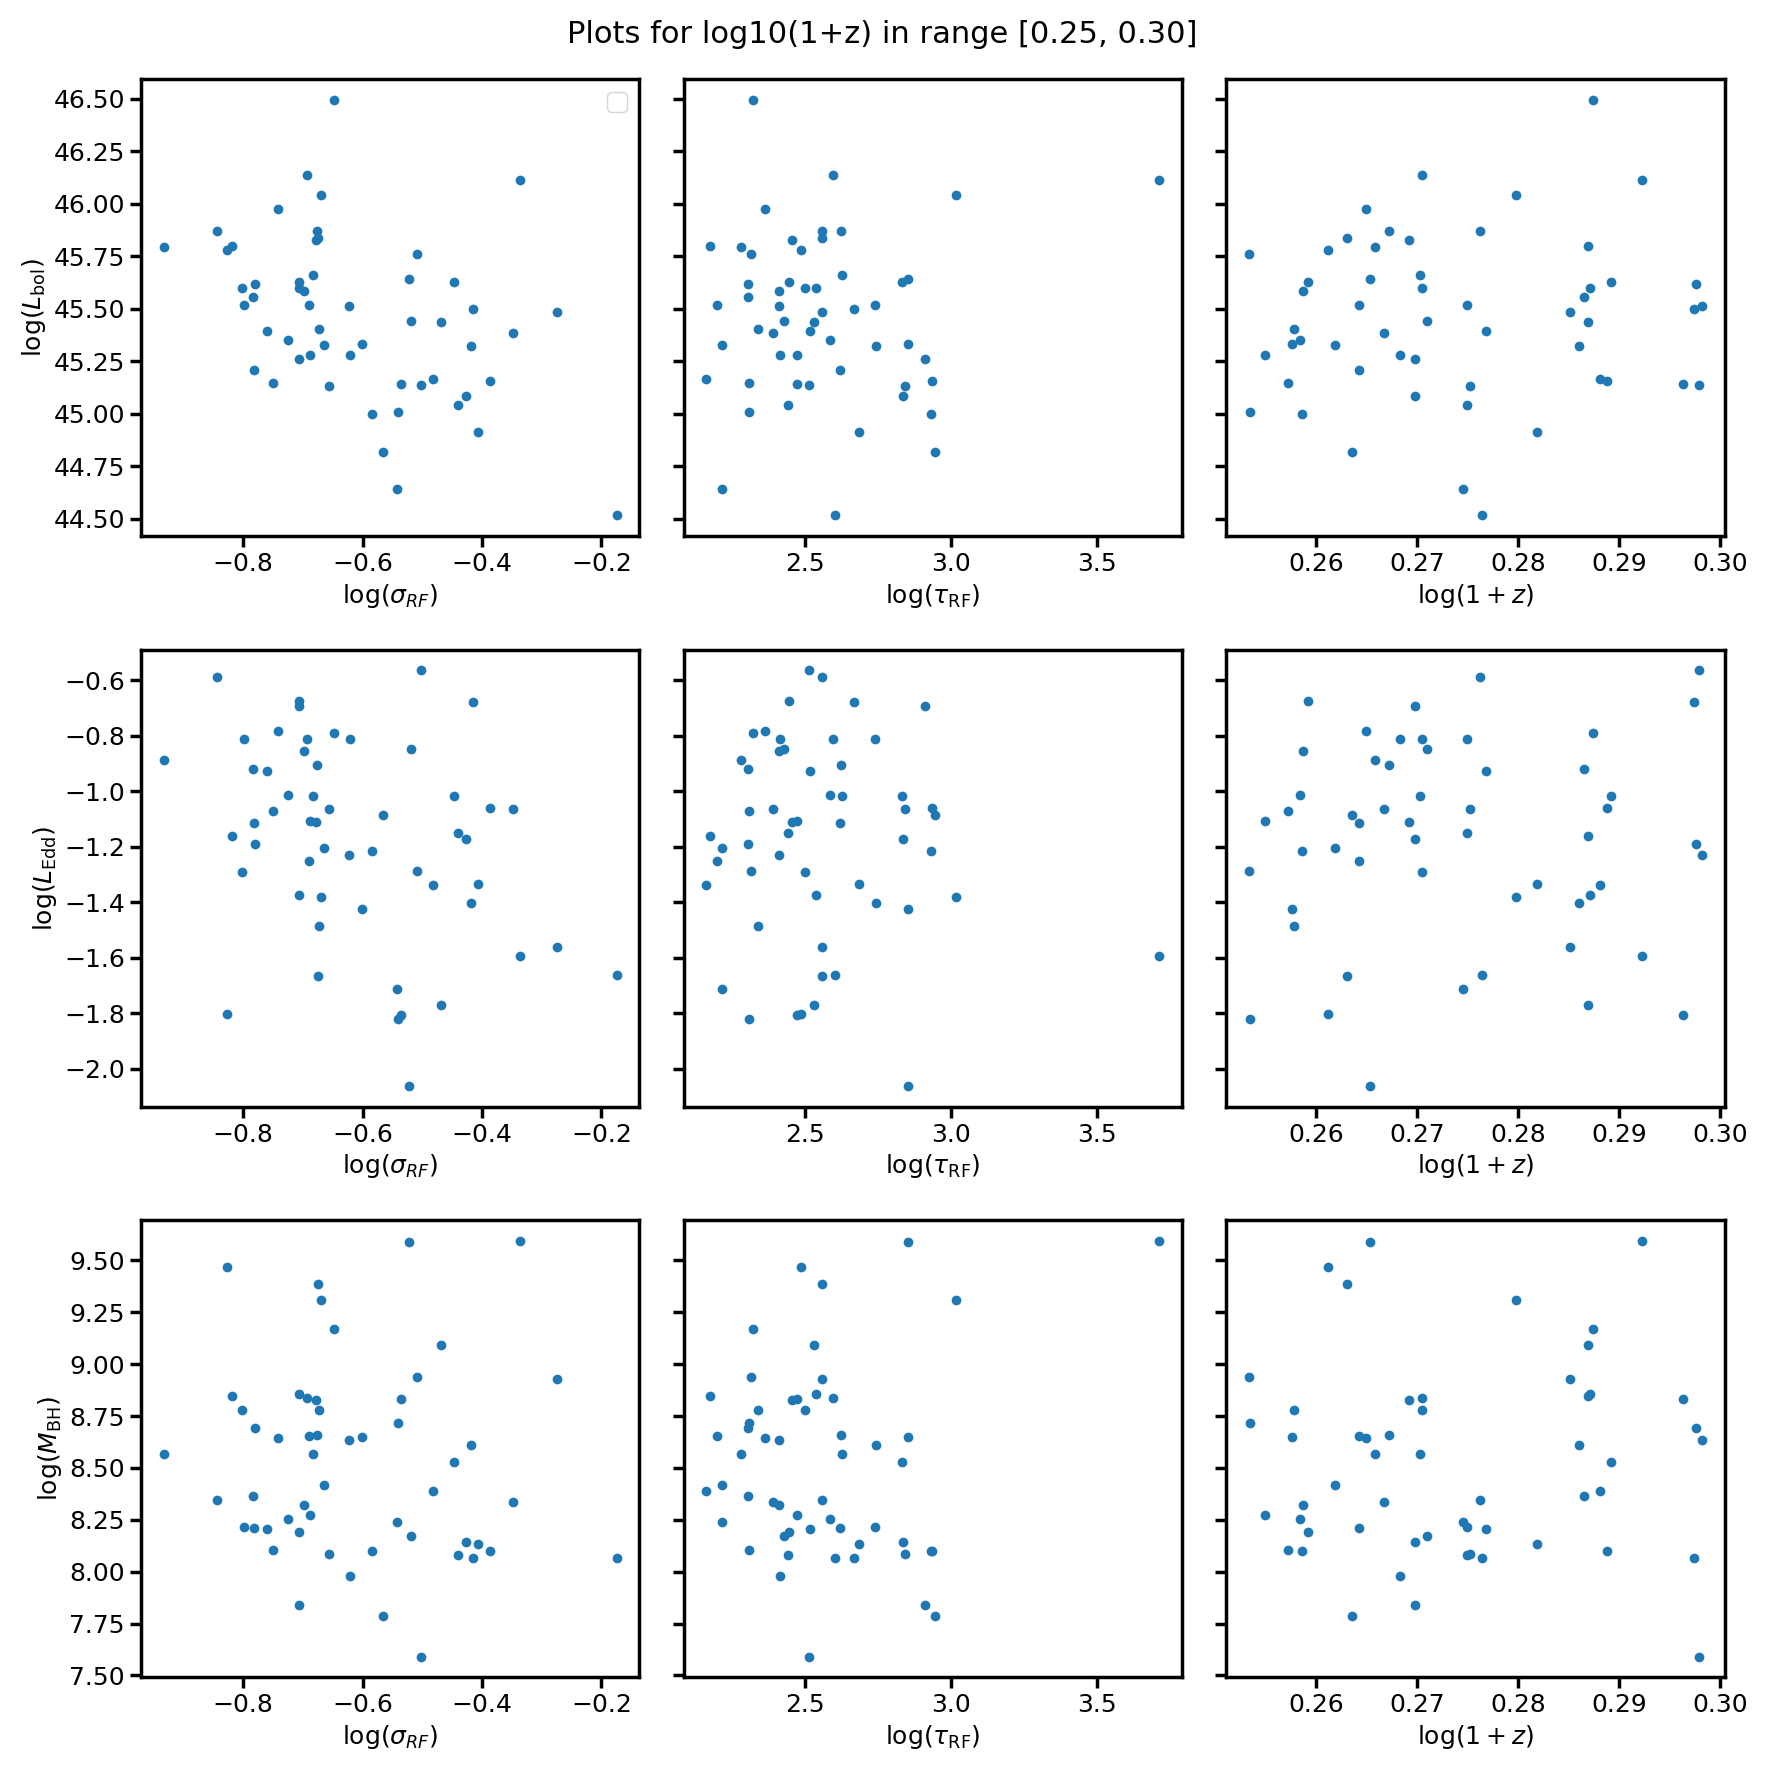

Plotting for range: 0.30 to 0.35


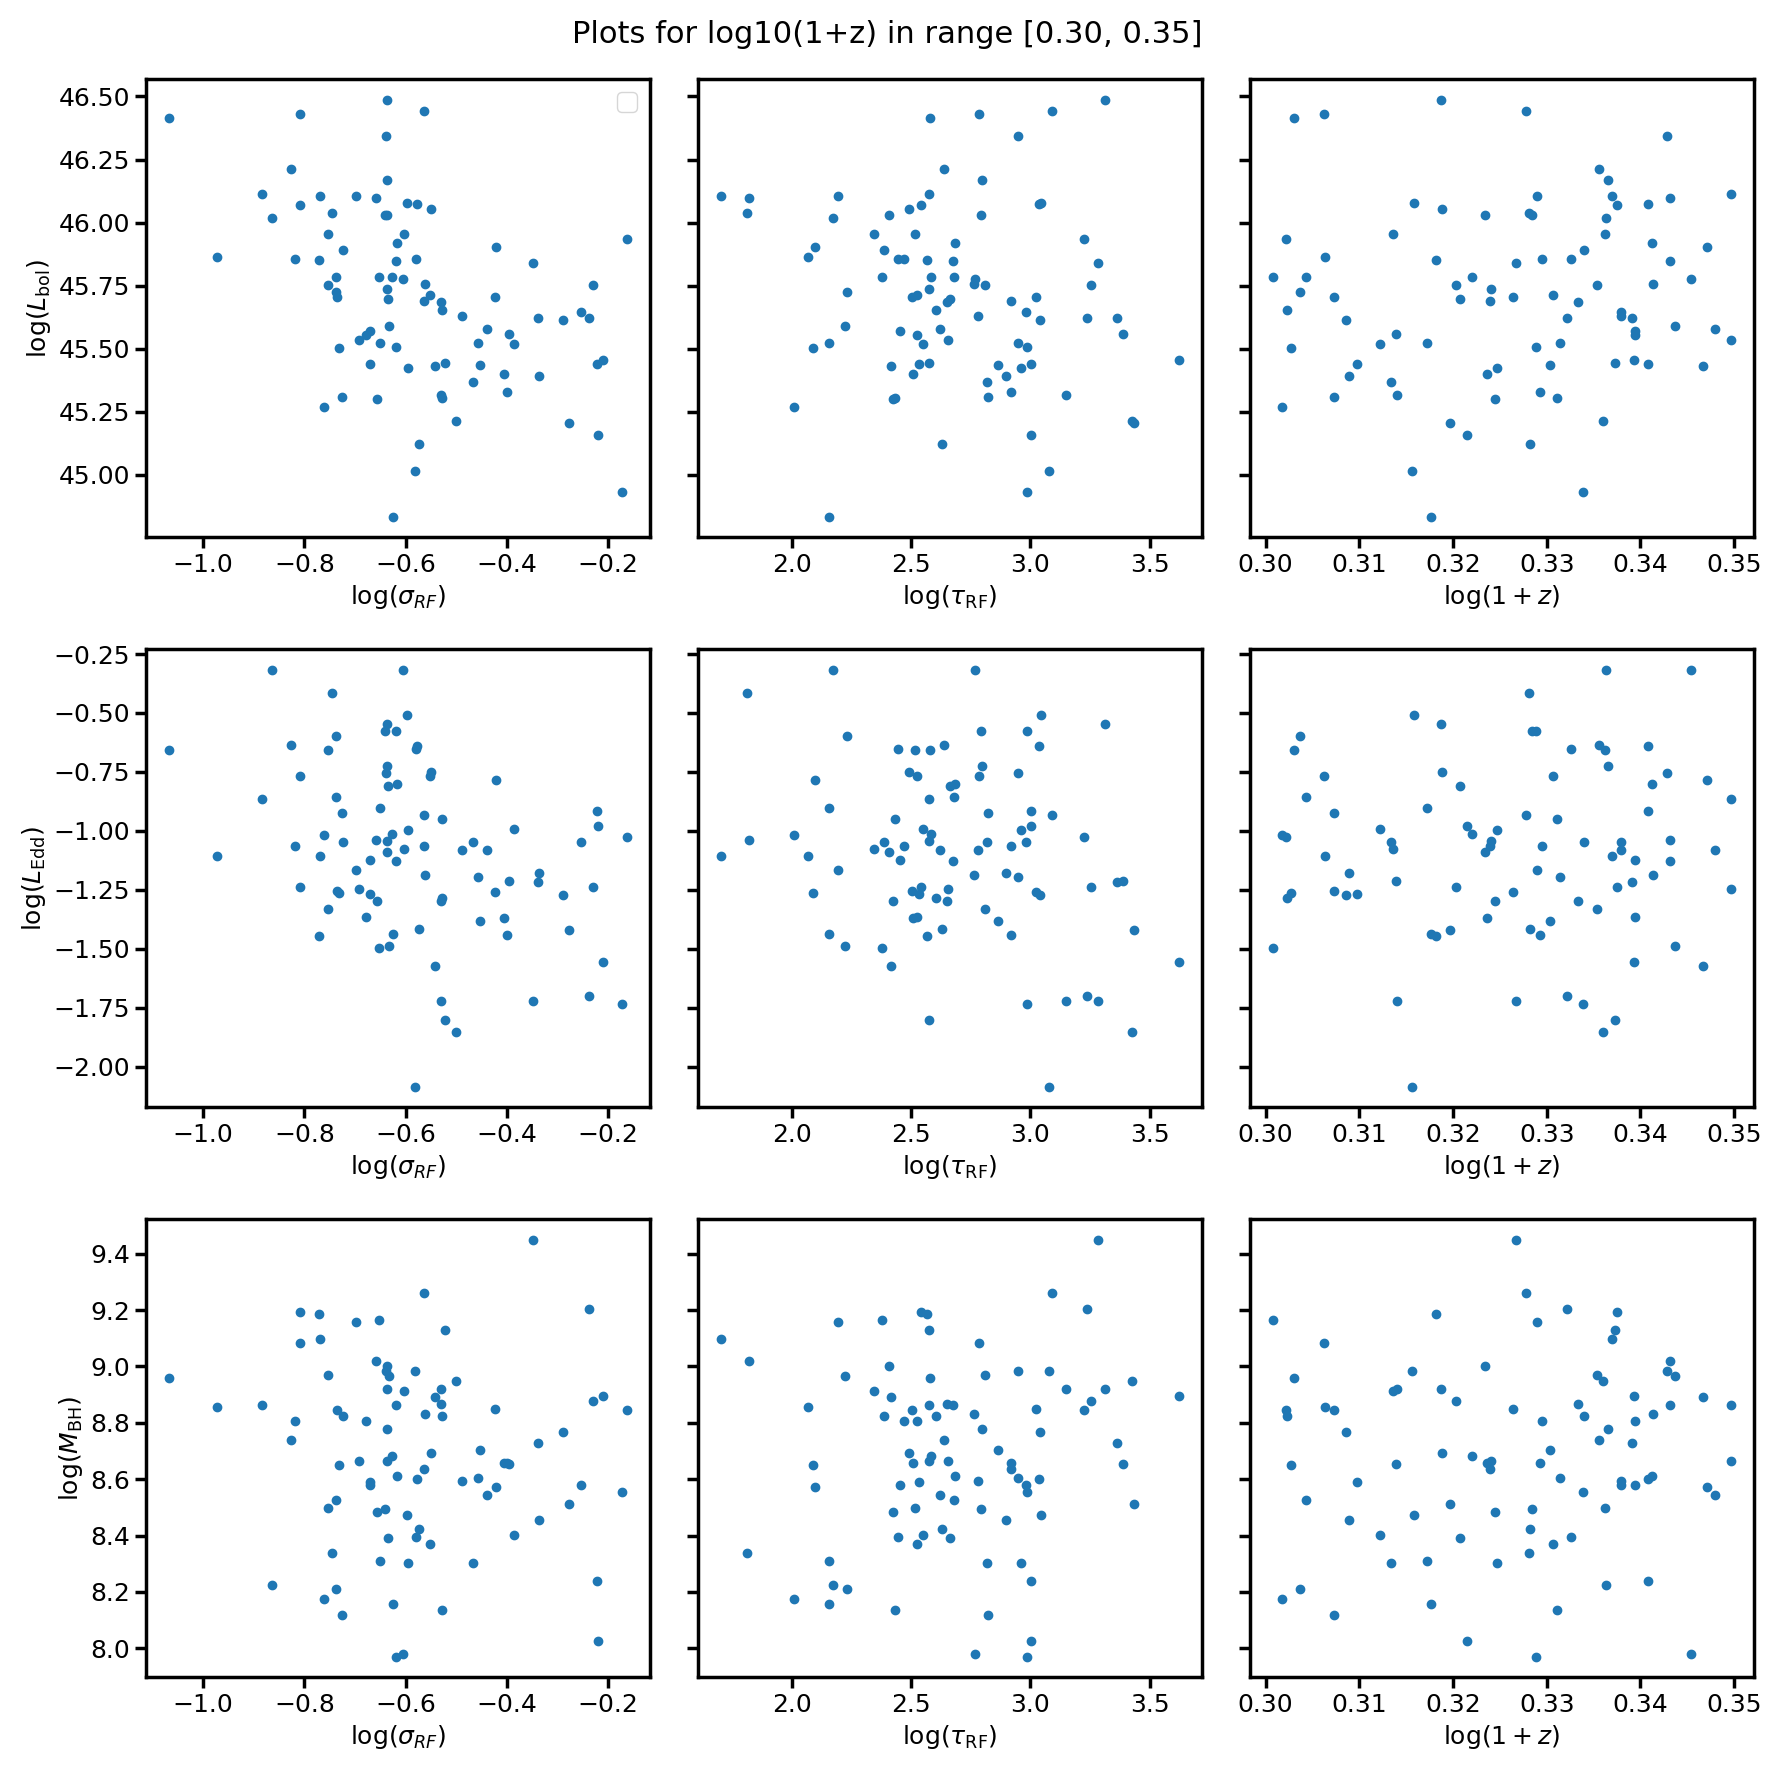

Plotting for range: 0.35 to 0.40


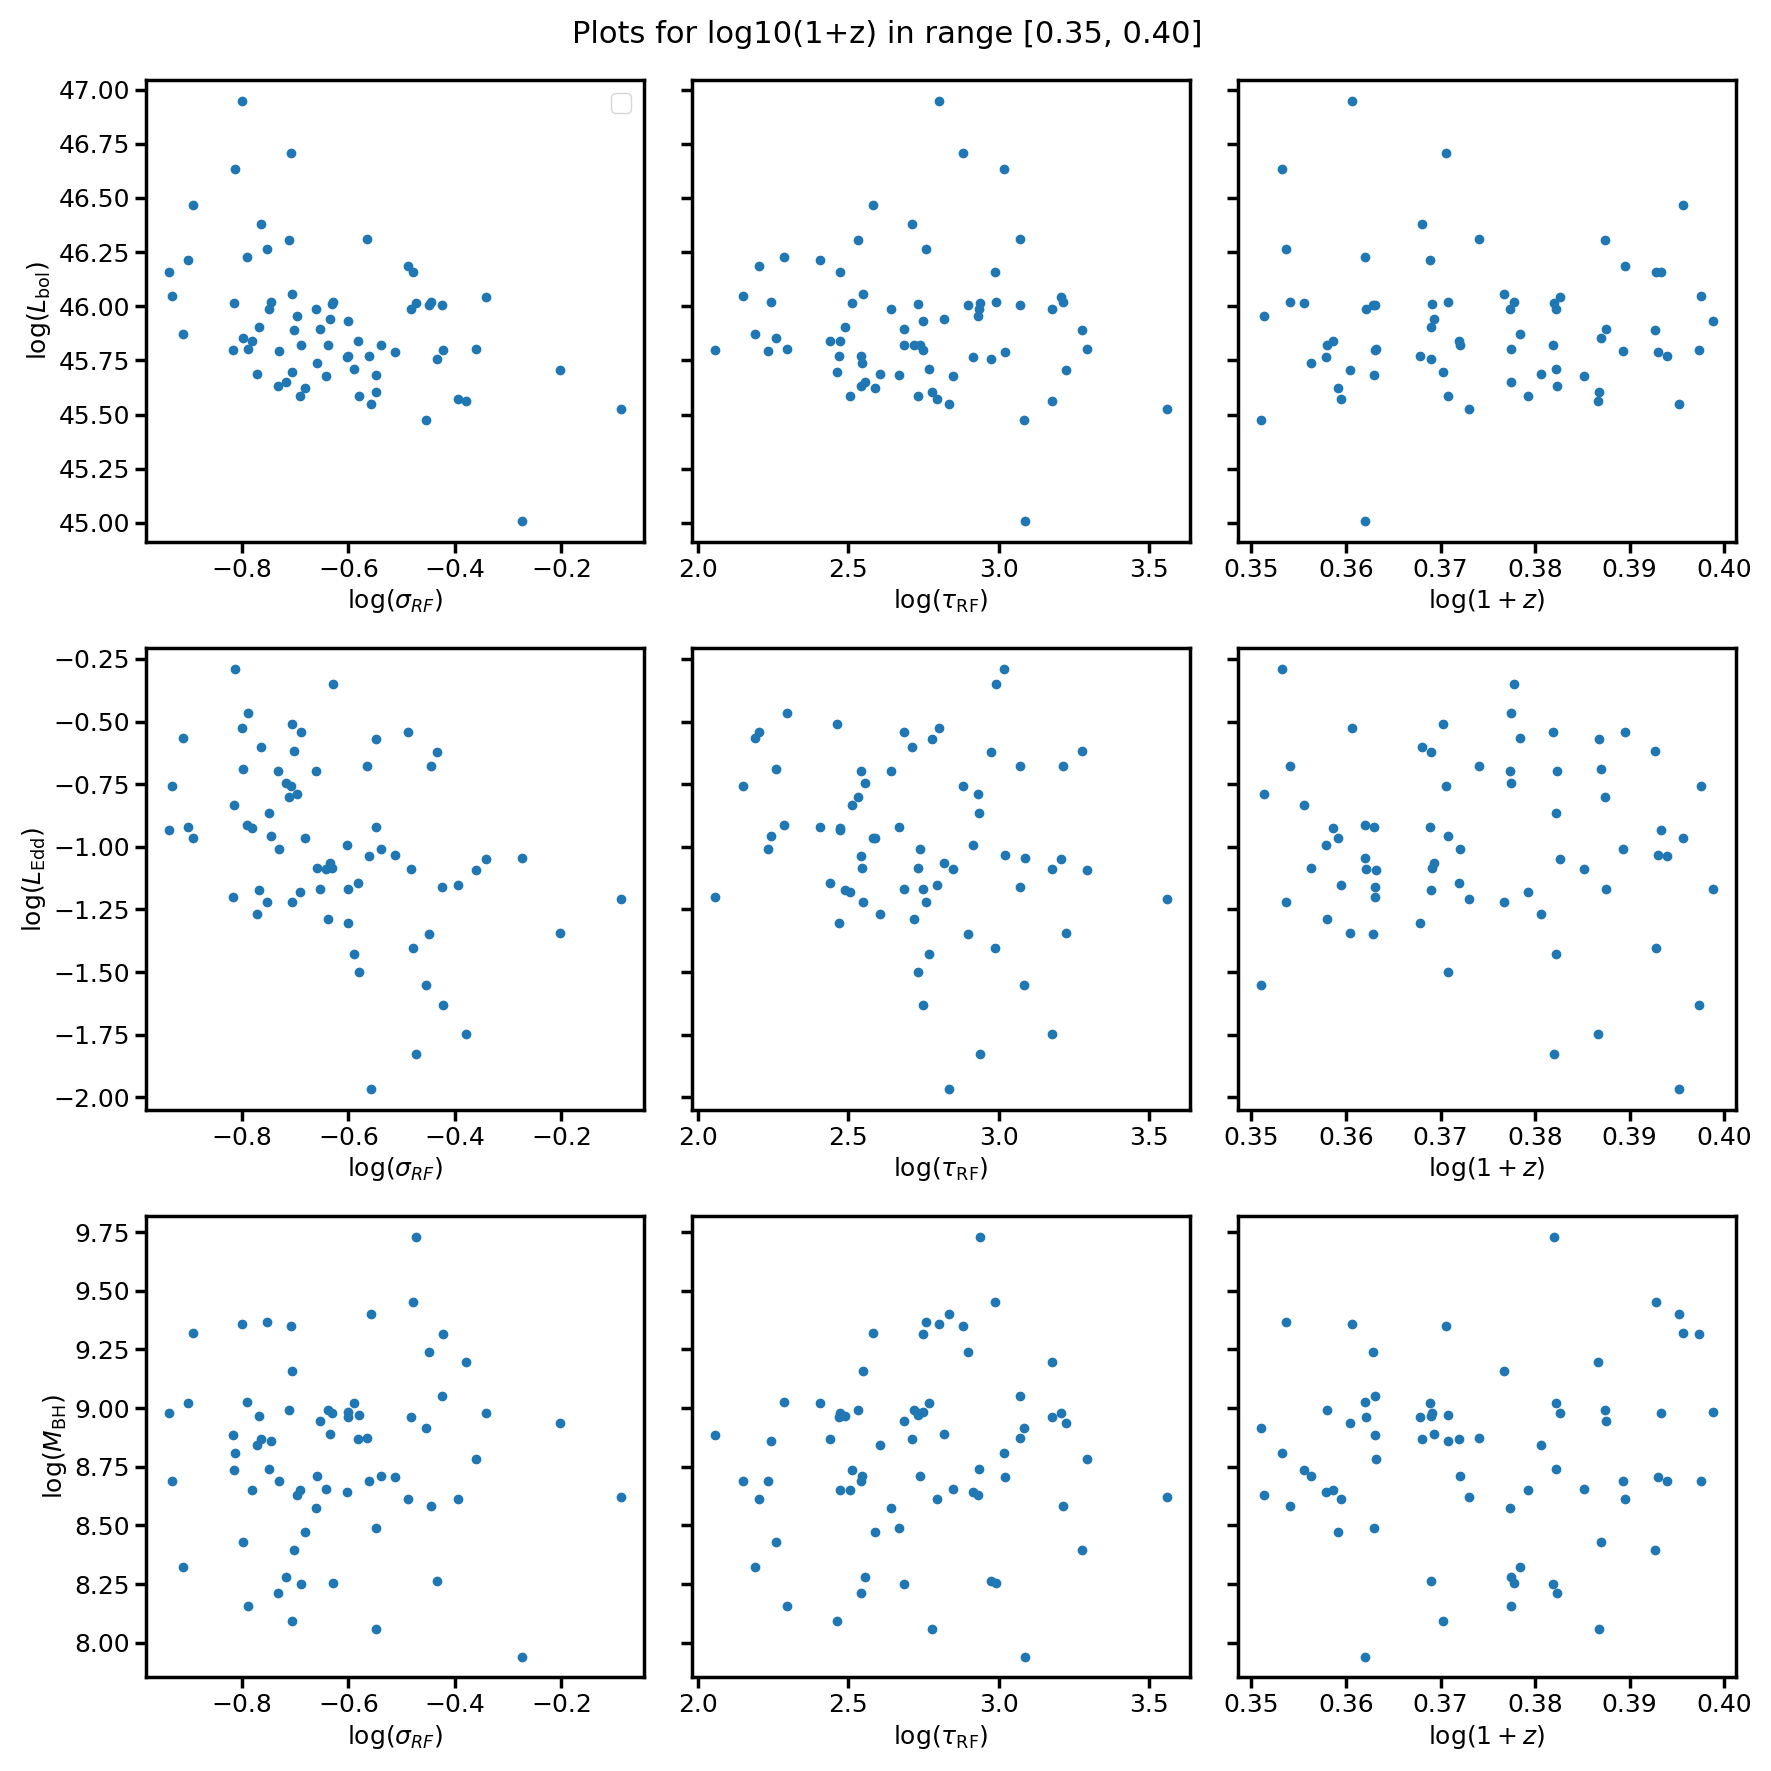

Plotting for range: 0.40 to 0.45


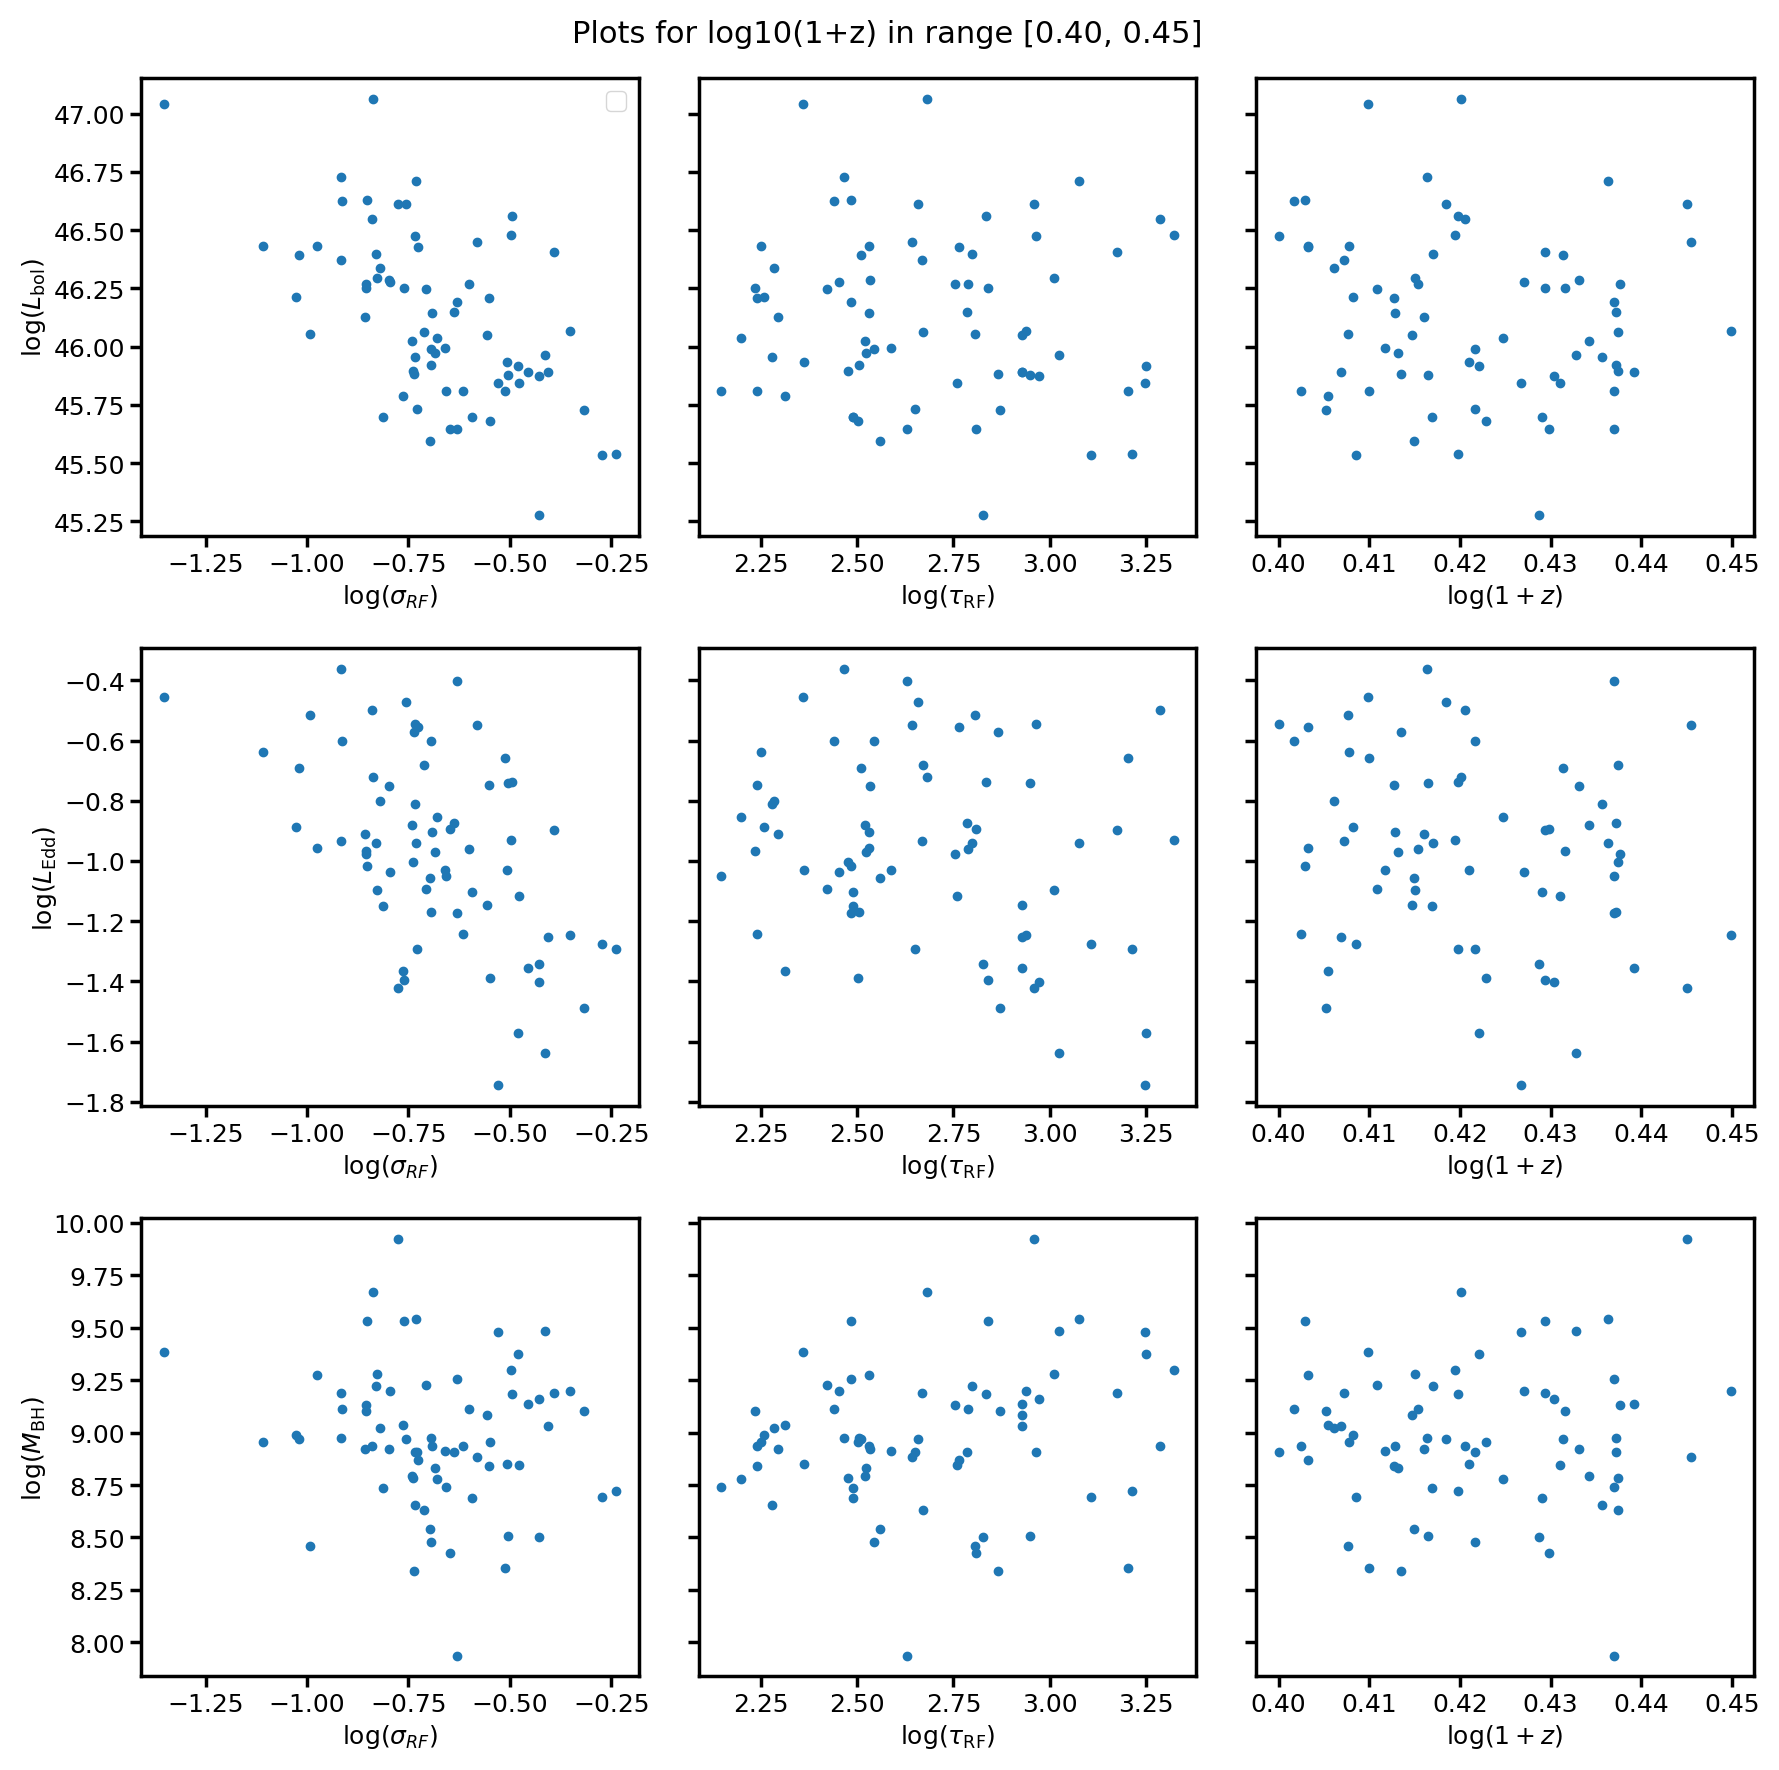

Plotting for range: 0.45 to 0.50


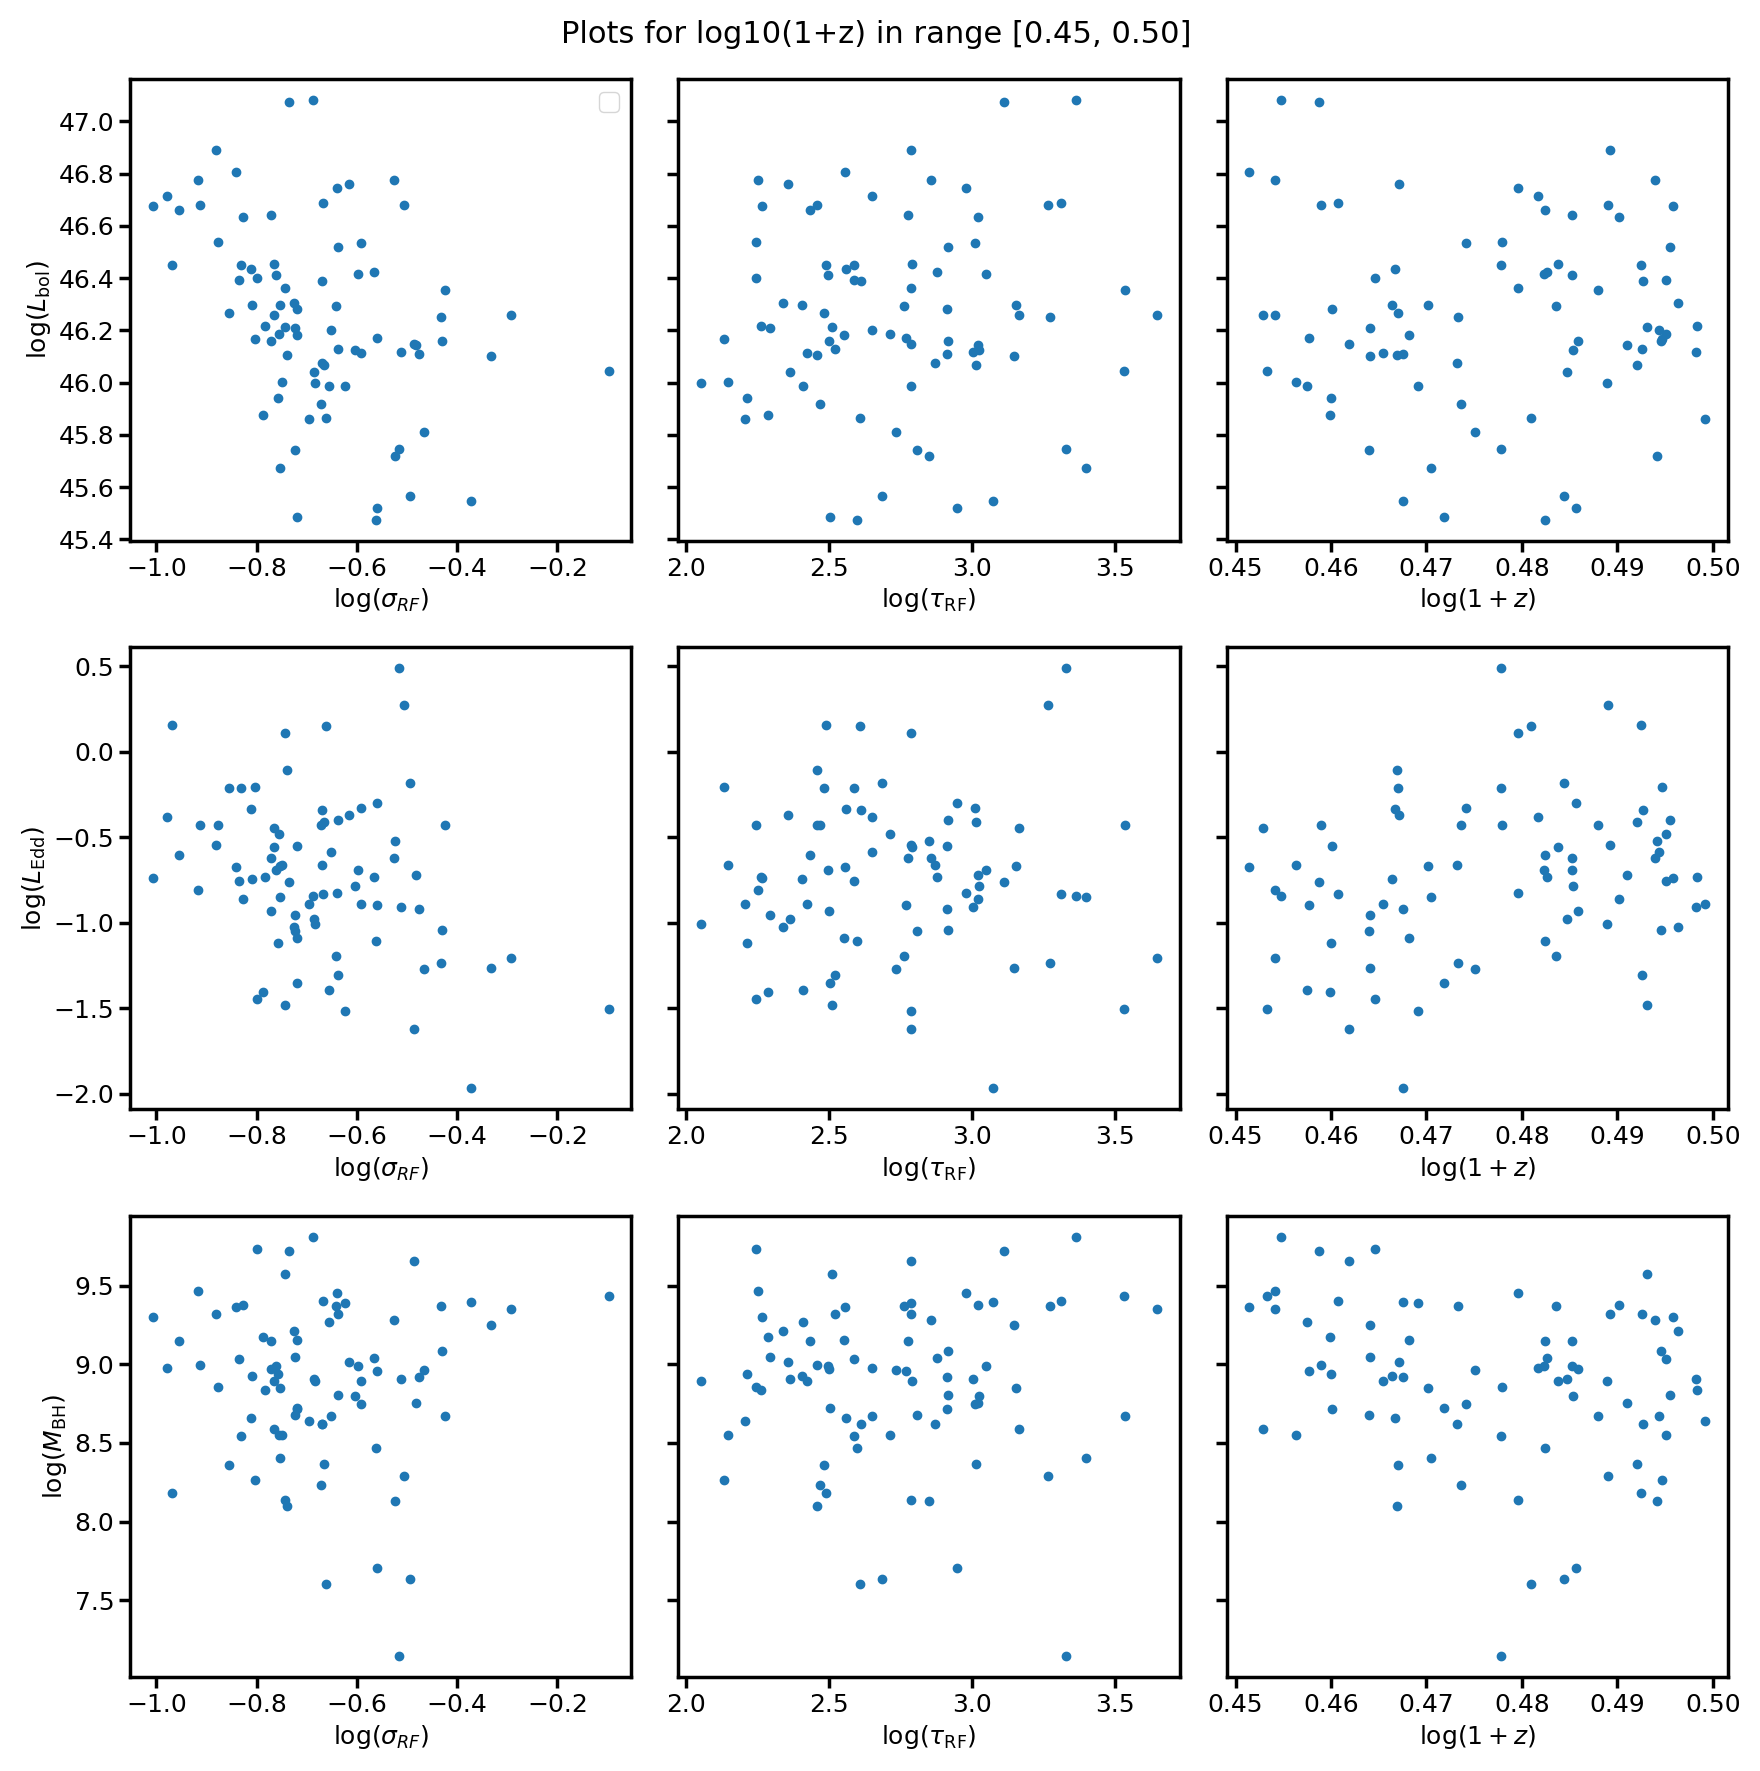

Plotting for range: 0.50 to 0.55


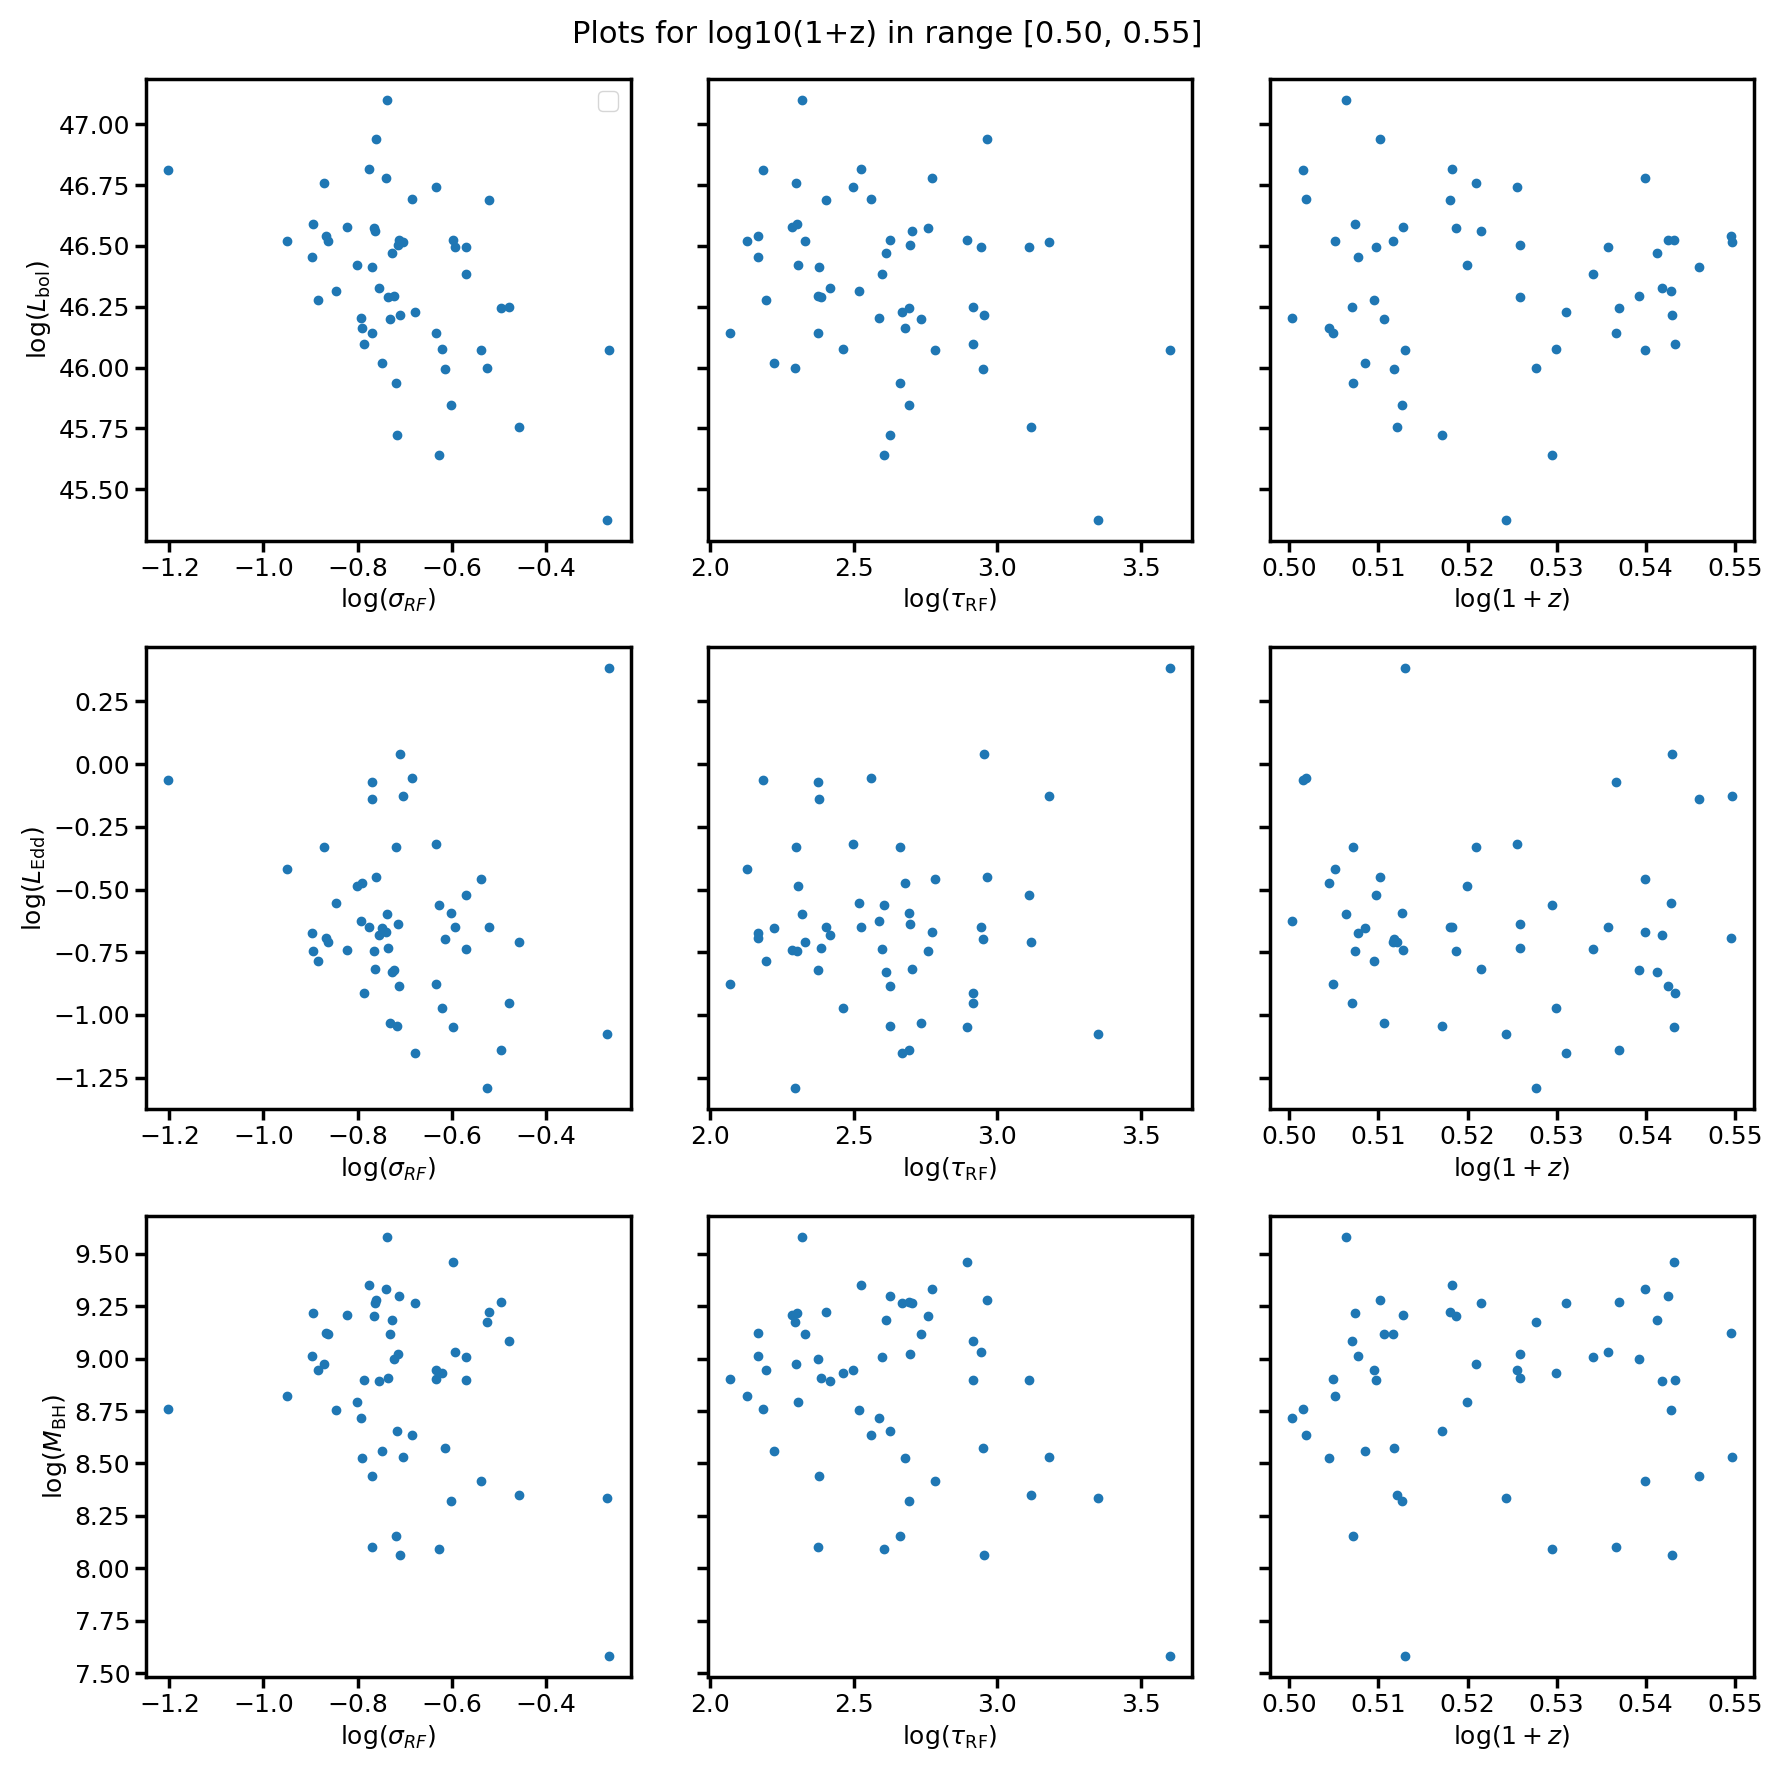

In [ ]:
def plot_selected_range(log10_z_range):
    # Filter the dataframe based on the provided range of np.log10(1+z)
    filtered_df = df[(np.log10(1 + df['z']) >= log10_z_range[0]) & (np.log10(1 + df['z']) <= log10_z_range[1])]
    
    fig, axs = plt.subplots(3, 3, figsize=(3*6, 3*6), sharey='row')
    # Add the bin range to the title
    fig.suptitle(f"Plots for log10(1+z) in range [{log10_z_range[0]:.2f}, {log10_z_range[1]:.2f}]")
    # First row
    ax = axs[0, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
    ax.legend()

    ax = axs[0, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[0, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(1+z)$")

    # Second row
    ax = axs[1, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(L_\mathrm{Edd})$")

    ax = axs[1, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[1, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(1+z)$")

    # Third row
    ax = axs[2, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(M_\mathrm{BH})$")

    ax = axs[2, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[2, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(1+z)$")

    plt.tight_layout()
    plt.show()
    plt.close()

# Define bins for np.log10(1+z)
bins = np.arange(0, np.log10(1 + df['z'].max()), 0.05)


# Call plot_selected_range for each bin
for i in range(len(bins) - 1):
    print(f"Plotting for range: {bins[i]:.2f} to {bins[i+1]:.2f}")
    plot_selected_range((bins[i], bins[i+1]))